# Cell 1 — Installations:

In [1]:
# Step 1: Install packages
!pip install amazon-braket-sdk amazon-braket-default-simulator boto3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.6/400.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.4/246.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.1/153.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.8/537.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

# Cell 2 — Imports:

In [2]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from scipy.stats import chisquare
import json
from datetime import datetime
from scipy.stats import chisquare
import random
import time
import json
from datetime import datetime, timezone
import os

In [3]:
# ── Publication Quality Plot Settings ────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Font settings
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'figure.figsize': (8, 5)
})

print("Publication quality settings applied!")

Publication quality settings applied!


# Cell 3 — AWS Credentials:



## Important
AWS credentials are not stored in this notebook.
Set your credentials as environment variables before running:
- AWS_ACCESS_KEY_ID
- AWS_SECRET_ACCESS_KEY

In [ ]:
# AWS Credentials
AWS_ACCESS_KEY = os.environ.get('AWS_ACCESS_KEY_ID', 'YOUR-ACCESS-KEY')
AWS_SECRET_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY', 'YOUR-SECRET-KEY')
AWS_REGION = 'us-east-1'
# Test connection
sts = boto3.client(
    'sts',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY,
    region_name=AWS_REGION
)
print(sts.get_caller_identity())

## Benchmark 1: Quantum Random Number Generation (QRNG)

### Overview
This benchmark compares quantum random number generation (QRNG) against
classical pseudo-random number generation (PRNG) using Python's MT19937 algorithm.

**Quantum approach:** Hadamard gates put qubits into superposition.
Measurement collapses each qubit to 0 or 1 with equal probability,
producing genuinely random bits from physical quantum measurement.

**Classical approach:** MT19937 (Mersenne Twister) generates deterministic
pseudo-random numbers using a mathematical algorithm. Fast and widely used
but fundamentally deterministic.

**Key question:** Is quantum randomness statistically different from
classical pseudo-randomness under NIST SP 800-22 evaluation?

In [5]:
# ── Quantum RNG Circuit ──────────────────────────────────
def quantum_rng(n_bits, shots=10000):
    """
    Generate quantum random bits using Hadamard gates.
    n_bits: number of qubits (= number of random bits per shot)
    shots: number of measurements
    """
    circuit = Circuit()
    for i in range(n_bits):
        circuit.h(i)

    device = LocalSimulator()
    result = device.run(circuit, shots=shots).result()

    return result.measurement_counts

# Test
counts = quantum_rng(n_bits=4, shots=10000)
print("QRNG Output:")
print(counts)

QRNG Output:
Counter({'1010': 668, '1111': 651, '1110': 639, '0100': 638, '0101': 636, '1100': 633, '0001': 629, '1011': 626, '1000': 626, '0011': 626, '0111': 613, '0000': 611, '1001': 611, '1101': 605, '0110': 601, '0010': 587})


### Agreed Comparison Protocol with Classical Lead
- Output bits: 10k, 20k, 40k, 80k
- Quantum shots: 2,500 | 5,000 | 10,000 | 20,000 (4 bits per shot)
- Trials: 10 per configuration
- Circuit: 4 qubits fixed
- Metrics: runtime + quality (chi-squared, p-value)

### Classical Baseline: MT19937 PRNG
Python's default random module uses the Mersenne Twister (MT19937) algorithm.
This is our classical comparison baseline.

In [6]:


# ── Classical PRNG (MT19937) ──────────────────────────────
def classical_rng(n_bits, shots=10000):
    """
    Generate classical random bits using Python's MT19937 PRNG.
    Direct comparison baseline for QRNG.
    """
    counts = {}
    for _ in range(shots):
        # Generate n_bits random bits
        bits = ''.join([str(random.randint(0, 1)) for _ in range(n_bits)])
        counts[bits] = counts.get(bits, 0) + 1

    return counts

# Test
classical_counts = classical_rng(n_bits=4, shots=10000)
print("Classical RNG Output:")
print(classical_counts)

Classical RNG Output:
{'1011': 621, '1110': 617, '0011': 585, '0010': 607, '1111': 642, '1010': 678, '0110': 585, '0000': 641, '1000': 633, '1100': 655, '0100': 641, '0101': 606, '1101': 614, '0001': 617, '0111': 636, '1001': 622}


### Comparison: QRNG vs Classical PRNG

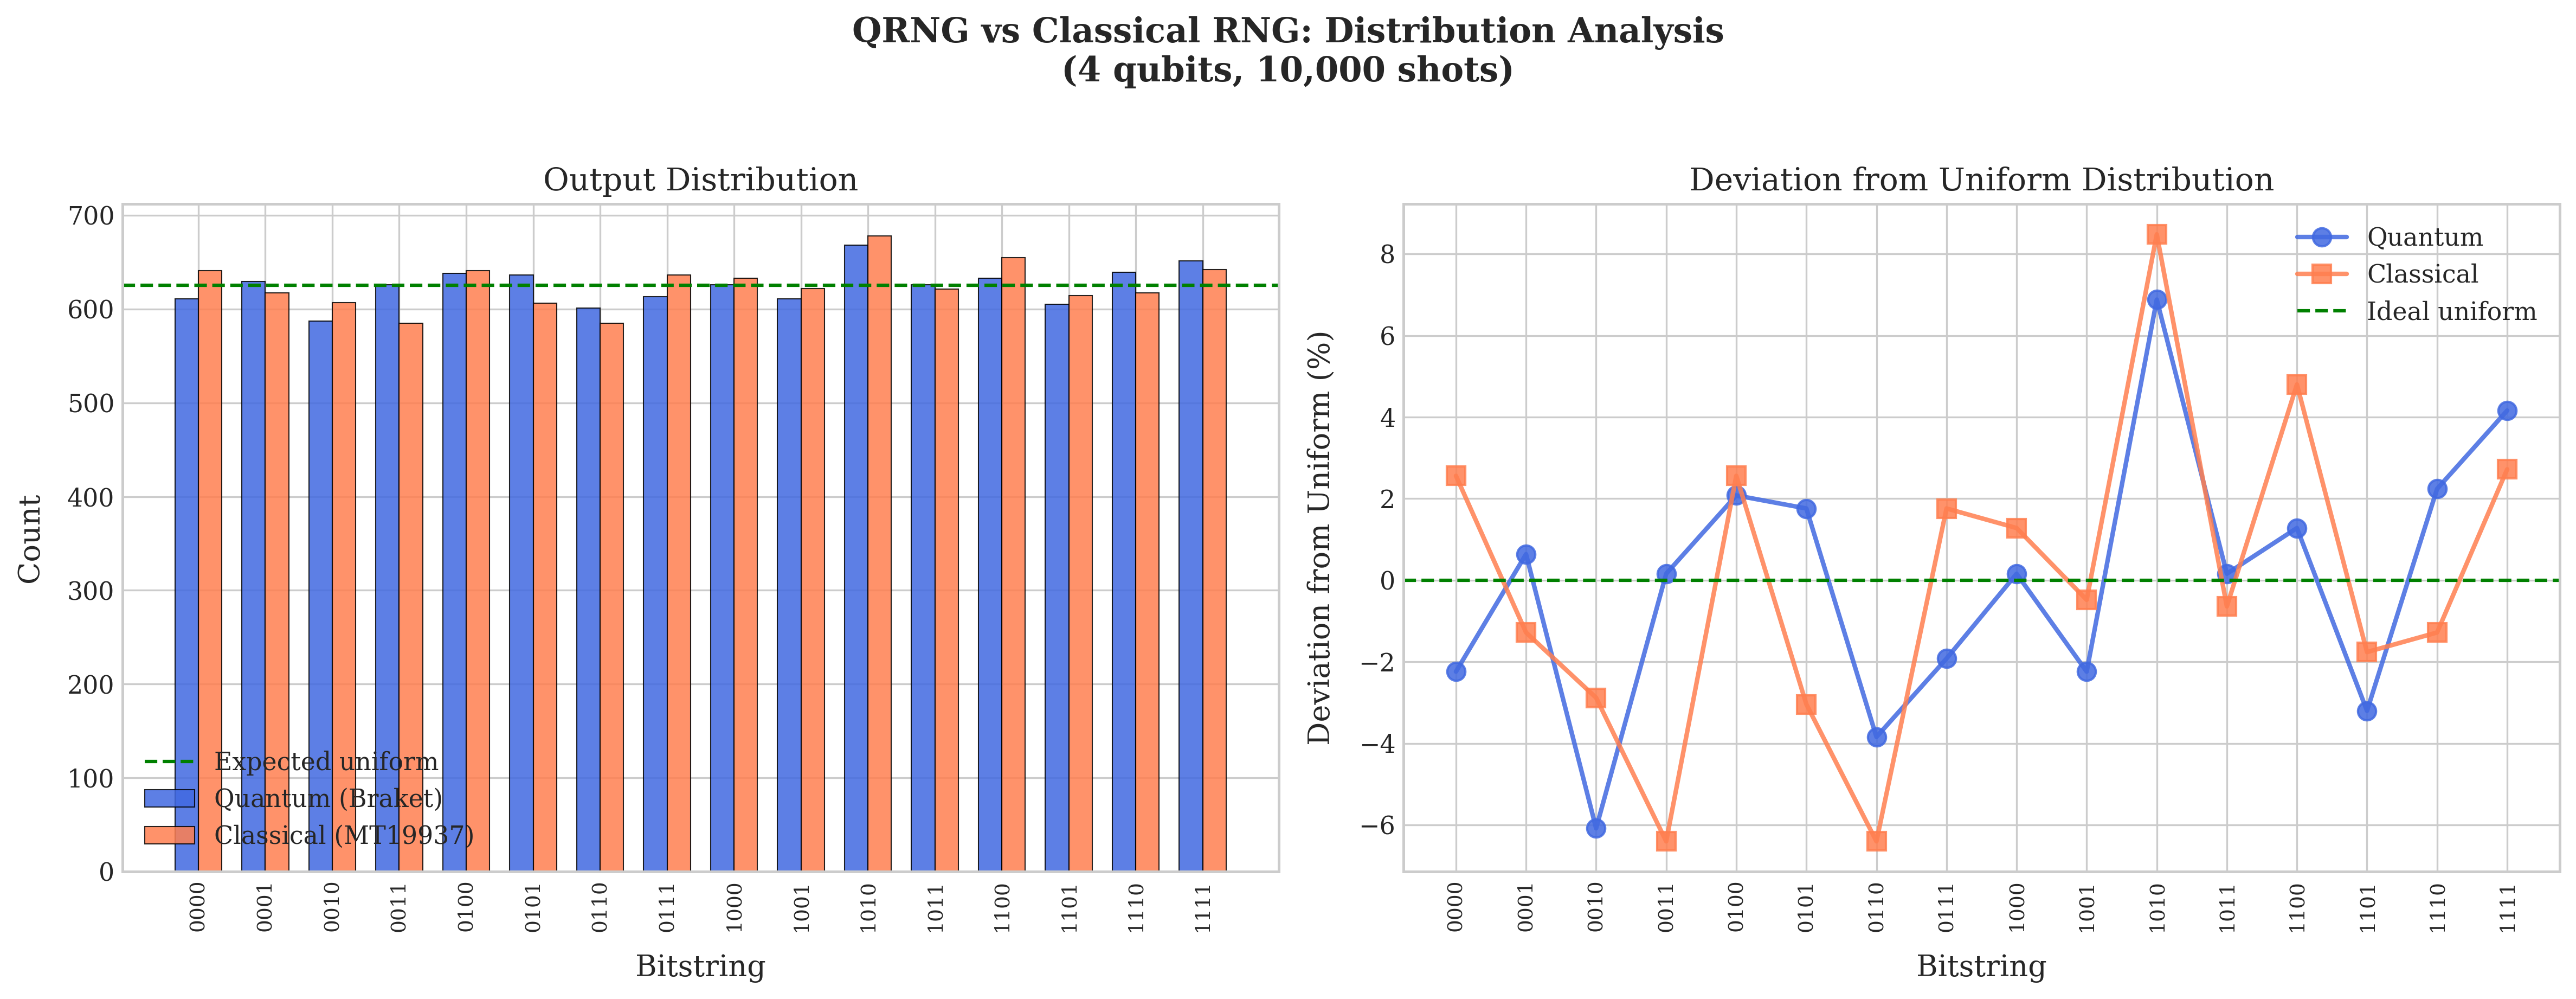

Plot saved!


In [7]:
def plot_comparison(quantum_counts, classical_counts, n_bits, shots):
    """
    Plot side by side comparison of QRNG vs Classical RNG output distribution.
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]

    q_values = [quantum_counts.get(s, 0) for s in all_states]
    c_values = [classical_counts.get(s, 0) for s in all_states]

    x = range(len(all_states))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'QRNG vs Classical RNG: Distribution Analysis\n({n_bits} qubits, {shots:,} shots)',
                 fontsize=15, fontweight='bold', y=1.02)

    # Plot 1: Side by side bar chart
    axes[0].bar([i - width/2 for i in x], q_values, width,
                label='Quantum (Braket)', color='royalblue', alpha=0.85,
                edgecolor='black', linewidth=0.5)
    axes[0].bar([i + width/2 for i in x], c_values, width,
                label='Classical (MT19937)', color='coral', alpha=0.85,
                edgecolor='black', linewidth=0.5)
    axes[0].axhline(y=shots/len(all_states), color='green',
                    linestyle='--', linewidth=1.5, label='Expected uniform')
    axes[0].set_xlabel('Bitstring', labelpad=10)
    axes[0].set_ylabel('Count', labelpad=10)
    axes[0].set_title('Output Distribution')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(all_states, rotation=90, fontsize=9)
    axes[0].legend(framealpha=0.9)

    # Plot 2: Deviation from uniform
    expected = shots / len(all_states)
    q_deviation = [(v - expected)/expected * 100 for v in q_values]
    c_deviation = [(v - expected)/expected * 100 for v in c_values]

    axes[1].plot(all_states, q_deviation, 'o-',
                 color='royalblue', label='Quantum', alpha=0.85)
    axes[1].plot(all_states, c_deviation, 's-',
                 color='coral', label='Classical', alpha=0.85)
    axes[1].axhline(y=0, color='green', linestyle='--',
                    linewidth=1.5, label='Ideal uniform')
    axes[1].set_xlabel('Bitstring', labelpad=10)
    axes[1].set_ylabel('Deviation from Uniform (%)', labelpad=10)
    axes[1].set_title('Deviation from Uniform Distribution')
    axes[1].set_xticks(range(len(all_states)))
    axes[1].set_xticklabels(all_states, rotation=90, fontsize=9)
    axes[1].legend(framealpha=0.9)

    plt.tight_layout()
    plt.savefig('qrng_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot saved!")

plot_comparison(counts, classical_counts, n_bits=4, shots=10000)

### Statistical Analysis: Chi-Squared Test for Uniformity

In [8]:


def statistical_analysis(quantum_counts, classical_counts, n_bits, shots):
    """
    Chi-squared test for uniformity.
    Tests whether the output distribution is statistically uniform.
    p-value > 0.05 = no significant deviation from uniform (good randomness)
    p-value <= 0.05 = significant deviation (biased generator)
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
    expected = shots / len(all_states)

    q_observed = [quantum_counts.get(s, 0) for s in all_states]
    c_observed = [classical_counts.get(s, 0) for s in all_states]

    q_chi2, q_pvalue = chisquare(q_observed)
    c_chi2, c_pvalue = chisquare(c_observed)

    print("=" * 50)
    print("Statistical Analysis: Chi-Squared Test")
    print("=" * 50)
    print(f"\nQuantum RNG:")
    print(f"  Chi-squared statistic : {q_chi2:.4f}")
    print(f"  p-value               : {q_pvalue:.4f}")
    print(f"  Result                : {'PASS' if q_pvalue > 0.05 else 'FAIL'}")

    print(f"\nClassical RNG (MT19937):")
    print(f"  Chi-squared statistic : {c_chi2:.4f}")
    print(f"  p-value               : {c_pvalue:.4f}")
    print(f"  Result                : {'PASS' if c_pvalue > 0.05 else 'FAIL'}")
    print("=" * 50)
    print("\nNote: p-value > 0.05 means no significant deviation from uniform distribution.")

# Run analysis
statistical_analysis(counts, classical_counts, n_bits=4, shots=10000)

Statistical Analysis: Chi-Squared Test

Quantum RNG:
  Chi-squared statistic : 9.6800
  p-value               : 0.8394
  Result                : PASS

Classical RNG (MT19937):
  Chi-squared statistic : 14.1664
  p-value               : 0.5129
  Result                : PASS

Note: p-value > 0.05 means no significant deviation from uniform distribution.


### Results Logging
Saving experiment results to JSON for team access and reproducibility.

In [9]:
# ── Log Results ──────────────────────────────────────────
experiment_log = {
    "experiment_id": "qi26_26_QRNG_001",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "shots": 10000,
        "gates": {"H": 4}
    },
    "metrics": {
        "quantum": {
            "chi2_statistic": 9.6800,
            "p_value": 0.8394,
            "result": "PASS"
        },
        "classical": {
            "chi2_statistic": 14.1664,
            "p_value": 0.5129,
            "result": "PASS"
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Both QRNG and MT19937 pass chi-squared uniformity test at 10,000 shots. Quantum p=0.8394, Classical p=0.5129."
}

with open('qrng_experiment_001.json', 'w') as f:
    json.dump(experiment_log, f, indent=2)

print("Experiment logged:")
print(json.dumps(experiment_log, indent=2))

Experiment logged:
{
  "experiment_id": "qi26_26_QRNG_001",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-19T03:33:14.533629+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "shots": 10000,
    "gates": {
      "H": 4
    }
  },
  "metrics": {
    "quantum": {
      "chi2_statistic": 9.68,
      "p_value": 0.8394,
      "result": "PASS"
    },
    "classical": {
      "chi2_statistic": 14.1664,
      "p_value": 0.5129,
      "result": "PASS"
    }
  },
  "environment": {
    "braket_sdk_version": "1.121.0",
    "python_version": "3.12",
    "region": "us-east-1"
  },
  "notes": "Both QRNG and MT19937 pass chi-squared uniformity test at 10,000 shots. Quantum p=0.8394, Classical p=0.5129."
}


### Shot Sweep Analysis: When Does Classical RNG Start Failing?
Testing both generators across increasing shot counts to find the crossover point.

In [10]:
# ── Shot Sweep Analysis ──────────────────────────────────
def shot_sweep(n_bits=4, shot_counts=[2500, 5000, 10000, 20000]):
    """
    Run both generators across multiple shot counts.
    Track p-values to see where classical starts failing.
    """
    results = []

    for shots in shot_counts:
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        q_chi2, q_p = chisquare(q_obs)
        c_chi2, c_p = chisquare(c_obs)

        results.append({
            'shots': shots,
            'quantum_p': round(q_p, 4),
            'classical_p': round(c_p, 4),
            'quantum_result': 'PASS' if q_p > 0.05 else 'FAIL',
            'classical_result': 'PASS' if c_p > 0.05 else 'FAIL'
        })

        print(f"Shots: {shots:6d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    return results

# ── Shot Sweep Analysis (Agreed Protocol) ────────────────
# Based on agreed protocol with Classical Lead (Kanishka):
# 10k bits = 2,500 shots | 20k bits = 5,000 shots
# 40k bits = 10,000 shots | 80k bits = 20,000 shots
results = shot_sweep(n_bits=4, shot_counts=[2500, 5000, 10000, 20000])

Shots:   2500 | Q p=0.8384 (PASS) | C p=0.0305 (FAIL)
Shots:   5000 | Q p=0.1835 (PASS) | C p=0.6197 (PASS)
Shots:  10000 | Q p=0.4988 (PASS) | C p=0.6365 (PASS)
Shots:  20000 | Q p=0.7164 (PASS) | C p=0.9487 (PASS)


### Shot Sweep Visualization

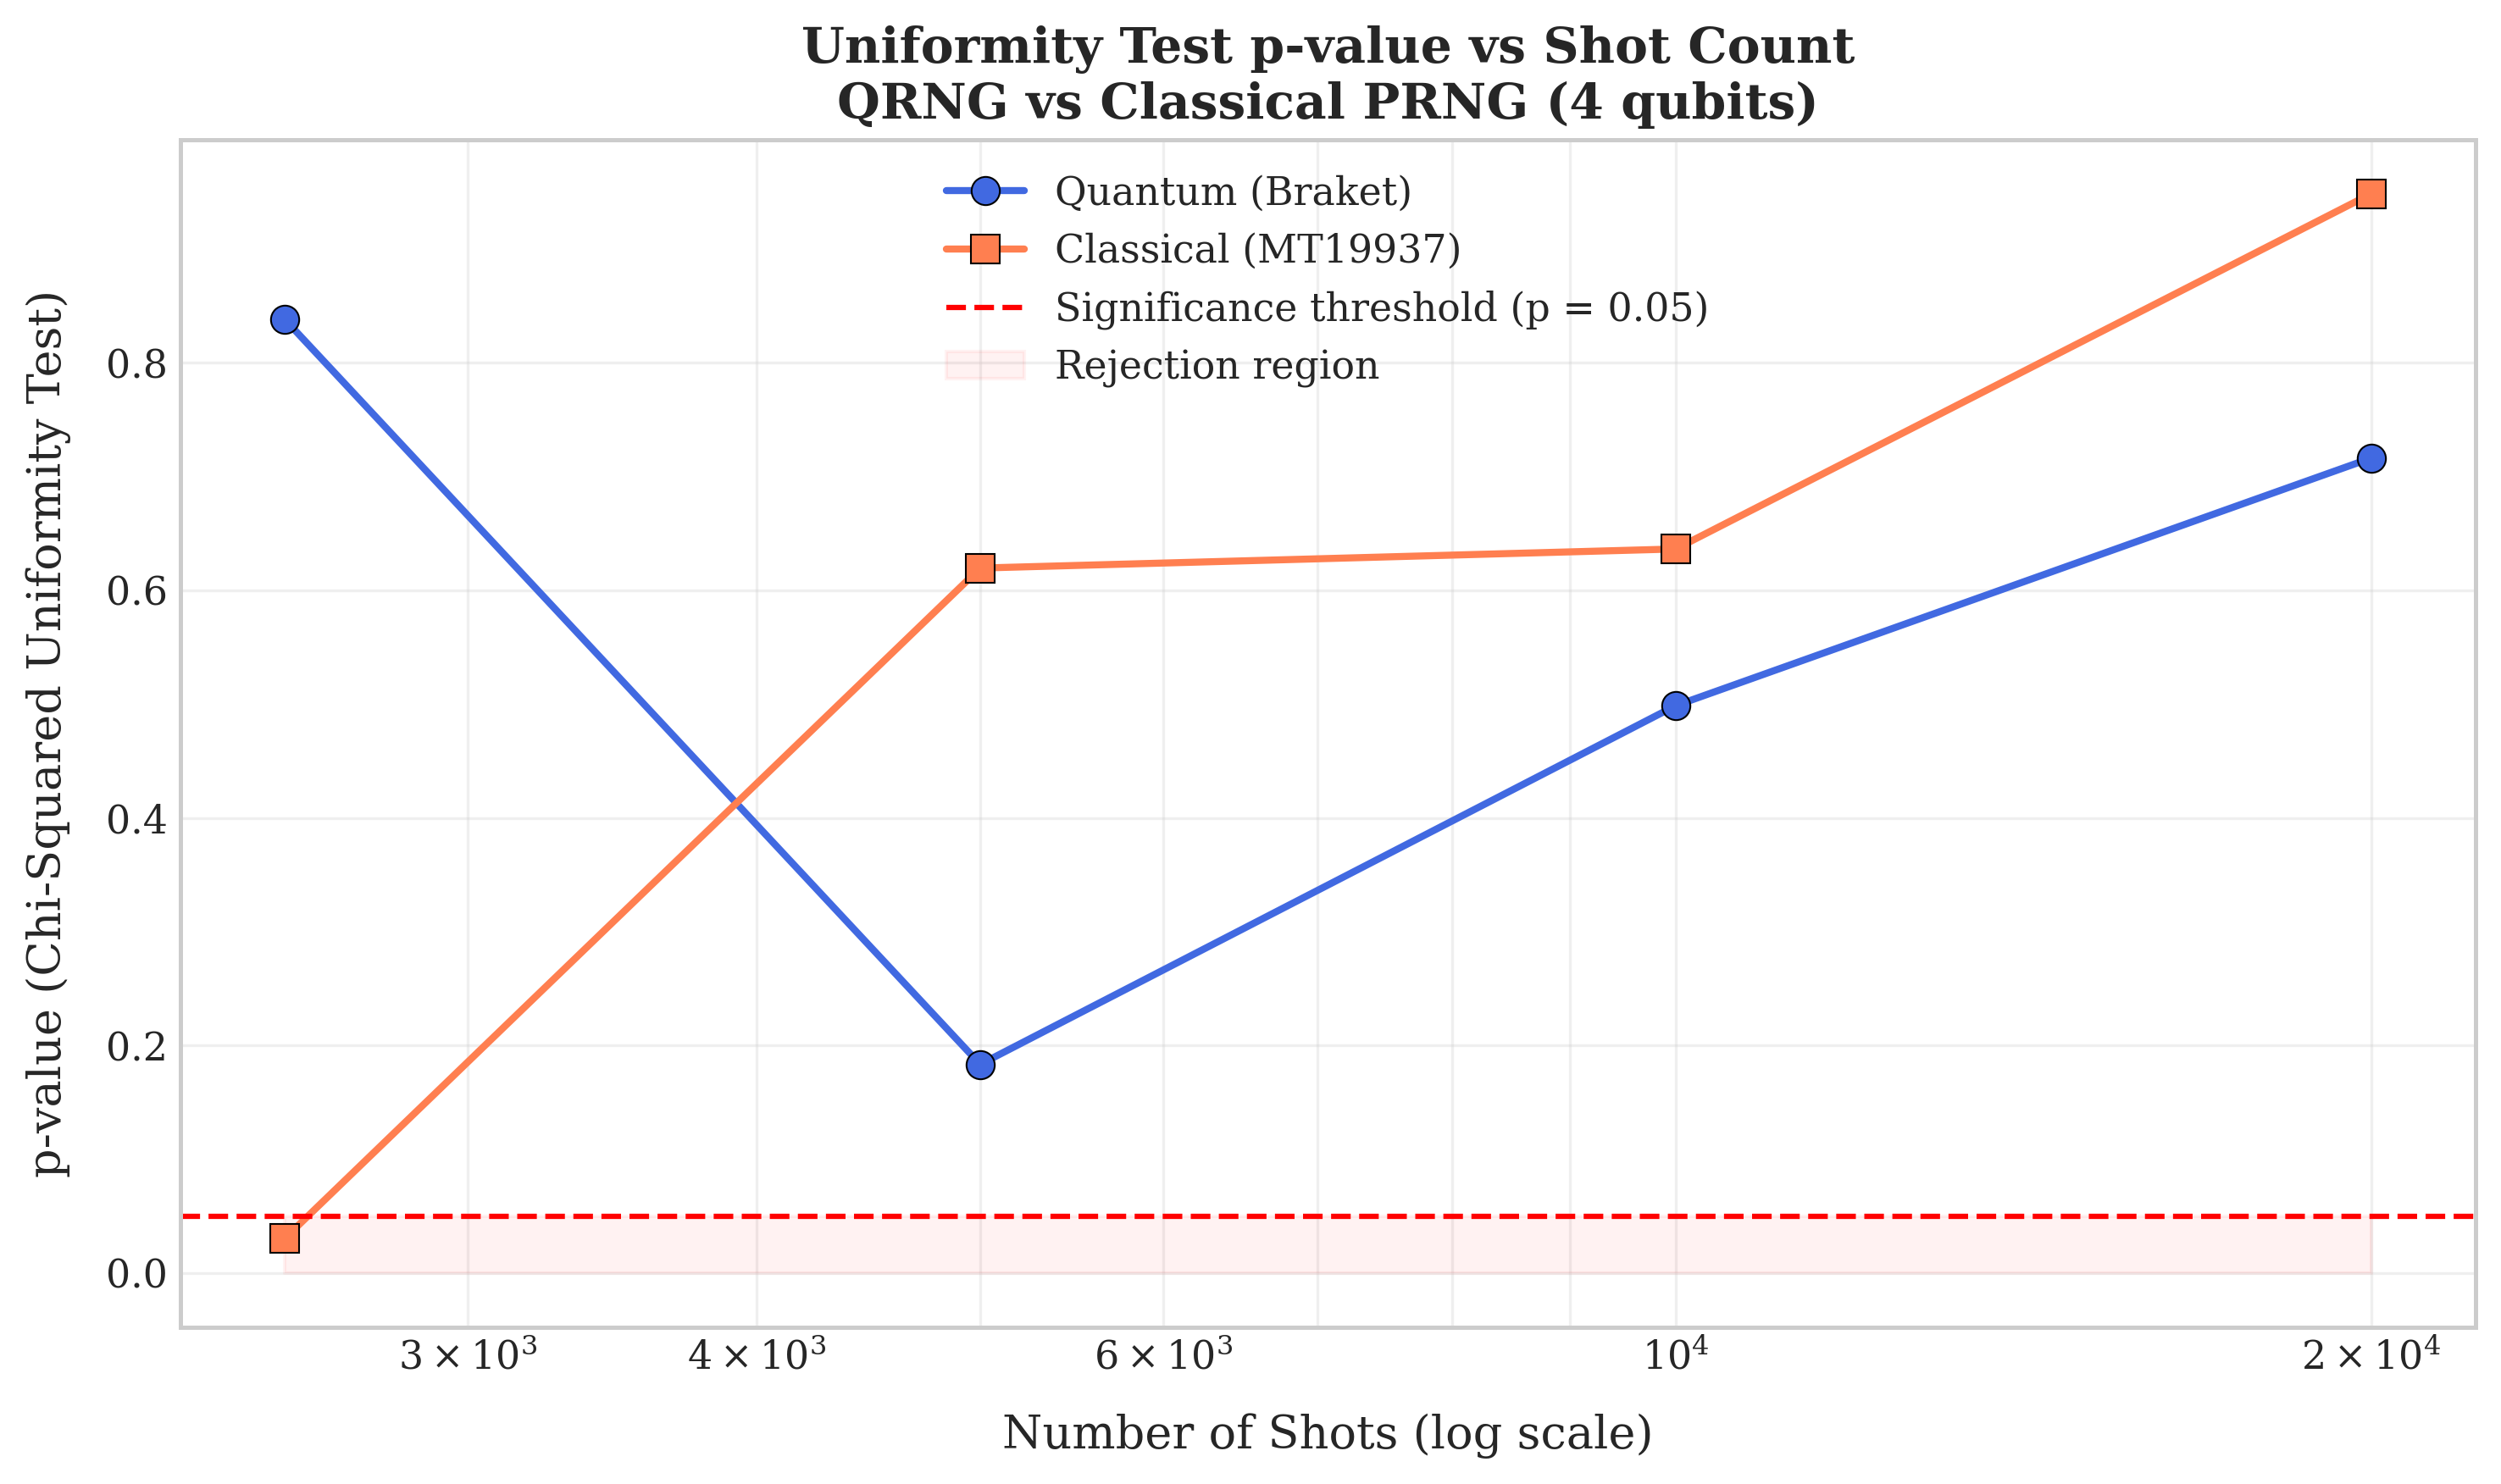

Shot sweep plot saved!


In [11]:
# ── Plot Shot Sweep ──────────────────────────────────────
def plot_shot_sweep(results):
    """
    Plot p-values across shot counts for both generators.
    Shows where each generator passes/fails the uniformity test.
    """
    shots = [r['shots'] for r in results]
    q_pvalues = [r['quantum_p'] for r in results]
    c_pvalues = [r['classical_p'] for r in results]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(shots, q_pvalues, 'o-', color='royalblue',
            label='Quantum (Braket)', linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5)
    ax.plot(shots, c_pvalues, 's-', color='coral',
            label='Classical (MT19937)', linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5)
    ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5,
               label='Significance threshold (p = 0.05)')
    ax.fill_between(shots, 0, 0.05, alpha=0.05, color='red',
                    label='Rejection region')

    ax.set_xscale('log')
    ax.set_xlabel('Number of Shots (log scale)', labelpad=10)
    ax.set_ylabel('p-value (Chi-Squared Uniformity Test)', labelpad=10)
    ax.set_title('Uniformity Test p-value vs Shot Count\nQRNG vs Classical PRNG (4 qubits)',
                 fontweight='bold')
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('qrng_shot_sweep.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Shot sweep plot saved!")

plot_shot_sweep(results)

# Results Logging 2

In [12]:
# ── Experiment Log 002: Shot Sweep ──────────────────────
experiment_log_002 = {
    "experiment_id": "qi26_26_QRNG_002",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "shot_counts": [2500, 5000, 10000, 20000],
        "output_bits": [10000, 20000, 40000, 80000]
    },
    "metrics": {
        "shot_sweep": [
            {"shots": 2500,  "output_bits": 10000, "quantum_p": 0.8384, "classical_p": 0.0305, "quantum_result": "PASS", "classical_result": "FAIL"},
            {"shots": 5000,  "output_bits": 20000, "quantum_p": 0.1835, "classical_p": 0.6197, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 10000, "output_bits": 40000, "quantum_p": 0.4988, "classical_p": 0.6365, "quantum_result": "PASS", "classical_result": "PASS"},
            {"shots": 20000, "output_bits": 80000, "quantum_p": 0.7164, "classical_p": 0.9487, "quantum_result": "PASS", "classical_result": "PASS"}
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Shot sweep using agreed protocol with Classical Lead. 4 qubits, matching output bits: 10k/20k/40k/80k. Classical failed at 10k bits (2,500 shots, p=0.0305). Quantum passed all configurations."
}

with open('qrng_experiment_002.json', 'w') as f:
    json.dump(experiment_log_002, f, indent=2)

print("Experiment 002 logged:")
print(json.dumps(experiment_log_002, indent=2))

Experiment 002 logged:
{
  "experiment_id": "qi26_26_QRNG_002",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-19T03:34:18.362104+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "shot_counts": [
      2500,
      5000,
      10000,
      20000
    ],
    "output_bits": [
      10000,
      20000,
      40000,
      80000
    ]
  },
  "metrics": {
    "shot_sweep": [
      {
        "shots": 2500,
        "output_bits": 10000,
        "quantum_p": 0.8384,
        "classical_p": 0.0305,
        "quantum_result": "PASS",
        "classical_result": "FAIL"
      },
      {
        "shots": 5000,
        "output_bits": 20000,
        "quantum_p": 0.1835,
        "classical_p": 0.6197,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "shots": 10000,
        "output_bits": 40000,
        "quantum_p": 0.4988,
        "classical_p": 0.6365,
        "quantum_re

# Multiple Trials
Comparing p-value consistency across 10 trials at 10,000 shots.

In [13]:
# ── Multiple Trials ──────────────────────────────────────
def multiple_trials(n_bits=4, shots=10000, trials=10):
    """
    Run both generators multiple times at same shot count.
    Shows consistency of each generator.
    """
    q_pvalues = []
    c_pvalues = []

    for i in range(trials):
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        q_pvalues.append(round(q_p, 4))
        c_pvalues.append(round(c_p, 4))

        print(f"Trial {i+1:2d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    print(f"\nQuantum  -- Mean p: {np.mean(q_pvalues):.4f} | Fail rate: {sum(1 for p in q_pvalues if p <= 0.05)}/{trials}")
    print(f"Classical -- Mean p: {np.mean(c_pvalues):.4f} | Fail rate: {sum(1 for p in c_pvalues if p <= 0.05)}/{trials}")

# ── Multiple Trials: Agreed Protocol ─────────────────────
# Run 10 trials for each agreed shot count
for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    print(f"\n{'='*60}")
    print(f"Output bits: {bits:,} | Shots: {shots:,}")
    print(f"{'='*60}")
    multiple_trials(n_bits=4, shots=shots, trials=10)


Output bits: 10,000 | Shots: 2,500
Trial  1 | Q p=0.9977 (PASS) | C p=0.2322 (PASS)
Trial  2 | Q p=0.7861 (PASS) | C p=0.2125 (PASS)
Trial  3 | Q p=0.8155 (PASS) | C p=0.3310 (PASS)
Trial  4 | Q p=0.9199 (PASS) | C p=0.4481 (PASS)
Trial  5 | Q p=0.8251 (PASS) | C p=0.4601 (PASS)
Trial  6 | Q p=0.7002 (PASS) | C p=0.4032 (PASS)
Trial  7 | Q p=0.9095 (PASS) | C p=0.4760 (PASS)
Trial  8 | Q p=0.6024 (PASS) | C p=0.6488 (PASS)
Trial  9 | Q p=0.3971 (PASS) | C p=0.9343 (PASS)
Trial 10 | Q p=0.1127 (PASS) | C p=0.9526 (PASS)

Quantum  -- Mean p: 0.7066 | Fail rate: 0/10
Classical -- Mean p: 0.5099 | Fail rate: 0/10

Output bits: 20,000 | Shots: 5,000
Trial  1 | Q p=0.7355 (PASS) | C p=0.2093 (PASS)
Trial  2 | Q p=0.8621 (PASS) | C p=0.8571 (PASS)
Trial  3 | Q p=0.7726 (PASS) | C p=0.9109 (PASS)
Trial  4 | Q p=0.6781 (PASS) | C p=0.2249 (PASS)
Trial  5 | Q p=0.2499 (PASS) | C p=0.1028 (PASS)
Trial  6 | Q p=0.7443 (PASS) | C p=0.6128 (PASS)
Trial  7 | Q p=0.0688 (PASS) | C p=0.0002 (FAIL)
Tri

### Multiple Trials Visualization
Comparing p-value consistency across 10 trials at 10,000 shots.


Output bits: 10,000 | Shots: 2,500


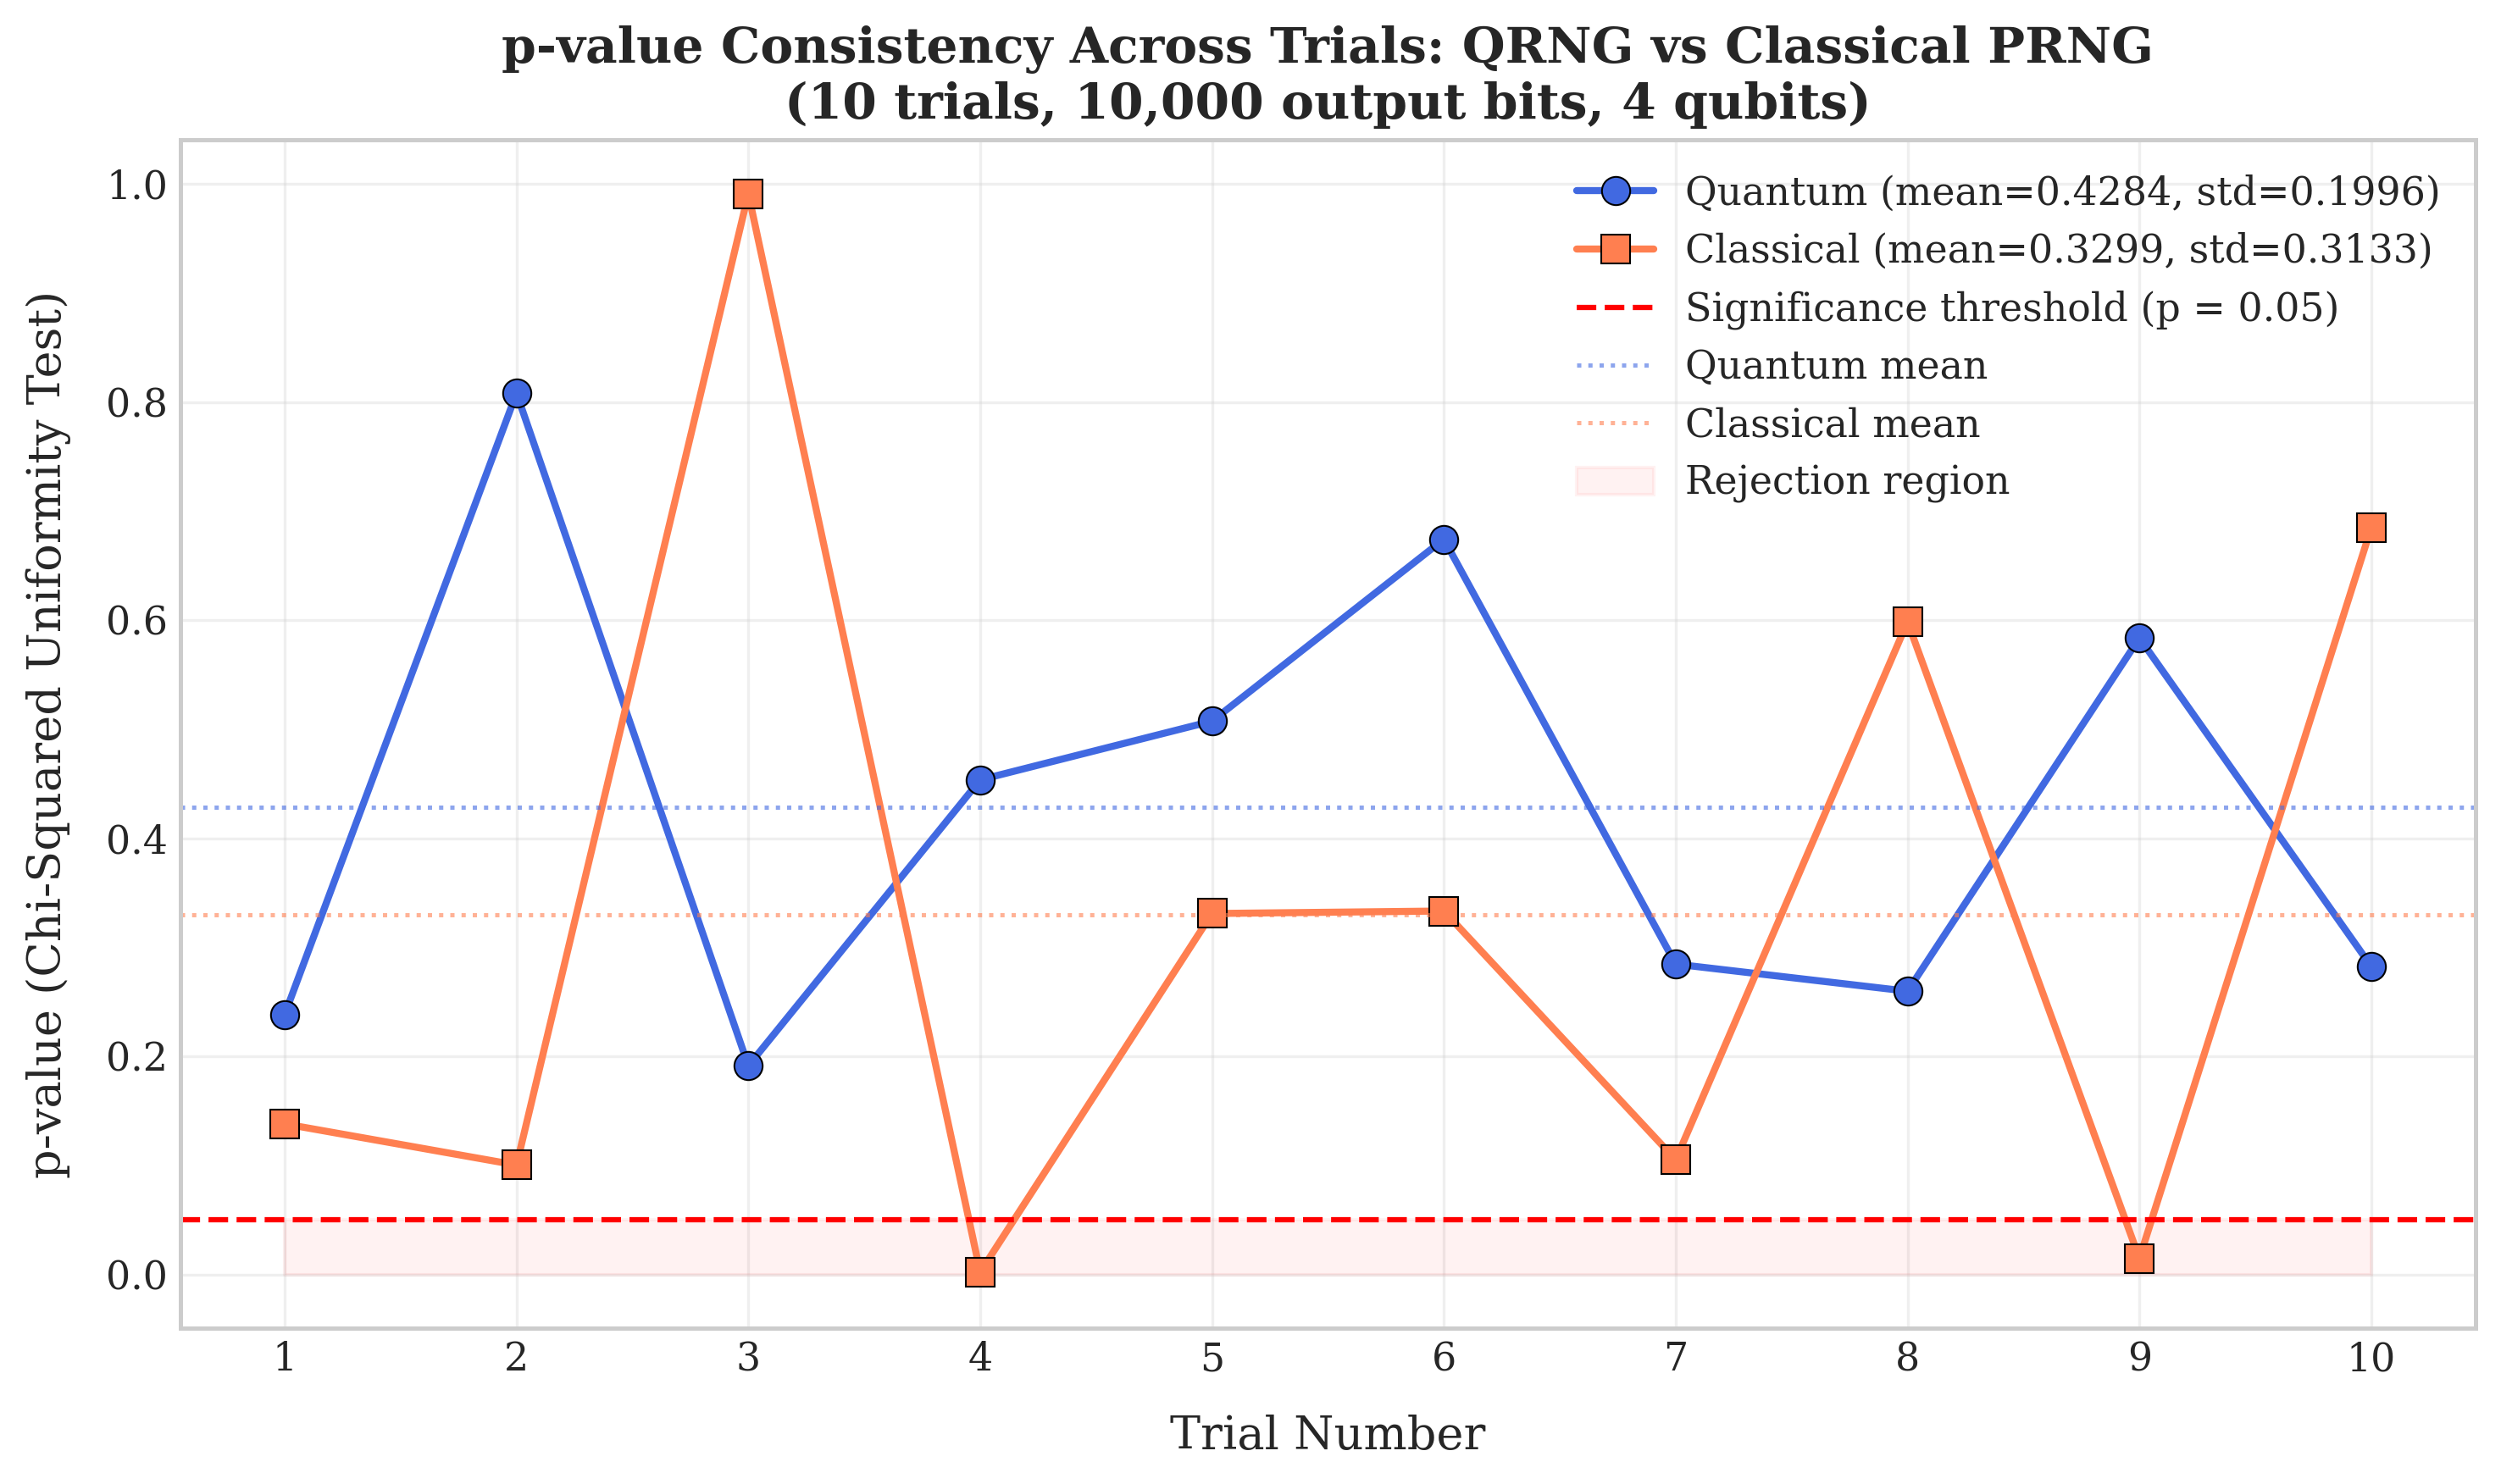


Quantum   -- Mean: 0.4284 | Std: 0.1996
Classical -- Mean: 0.3299 | Std: 0.3133

Output bits: 20,000 | Shots: 5,000


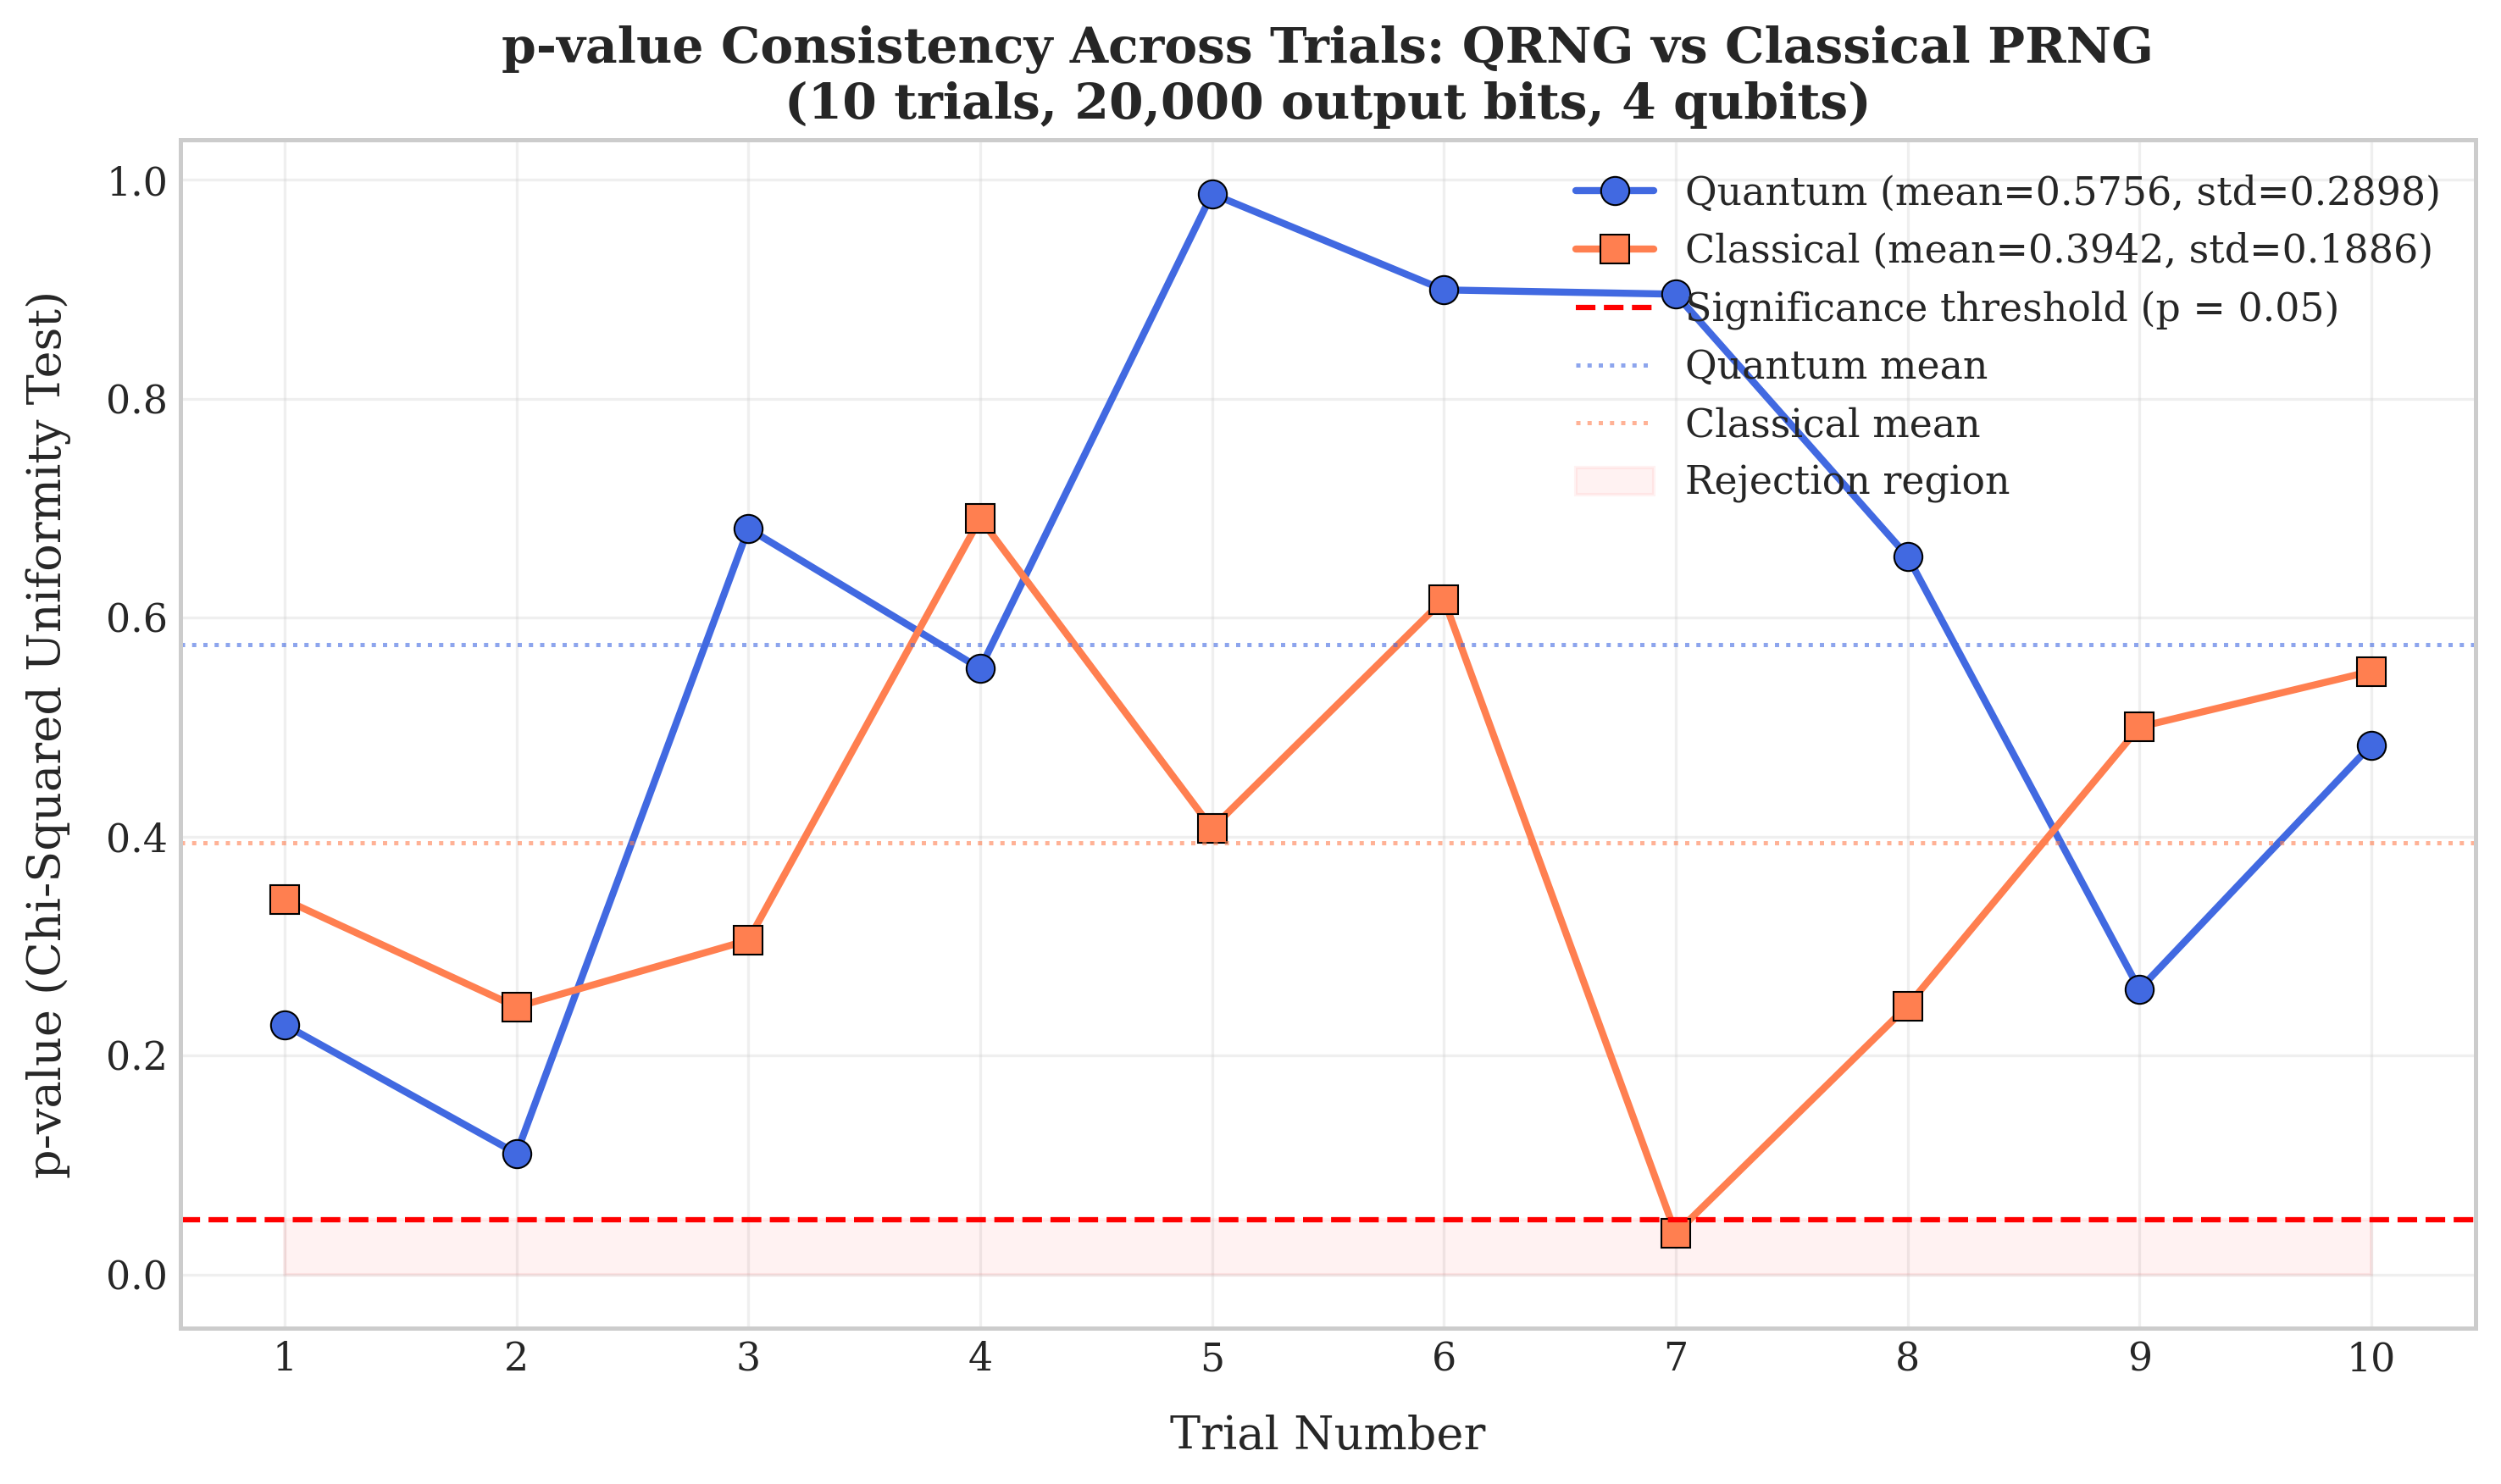


Quantum   -- Mean: 0.5756 | Std: 0.2898
Classical -- Mean: 0.3942 | Std: 0.1886

Output bits: 40,000 | Shots: 10,000


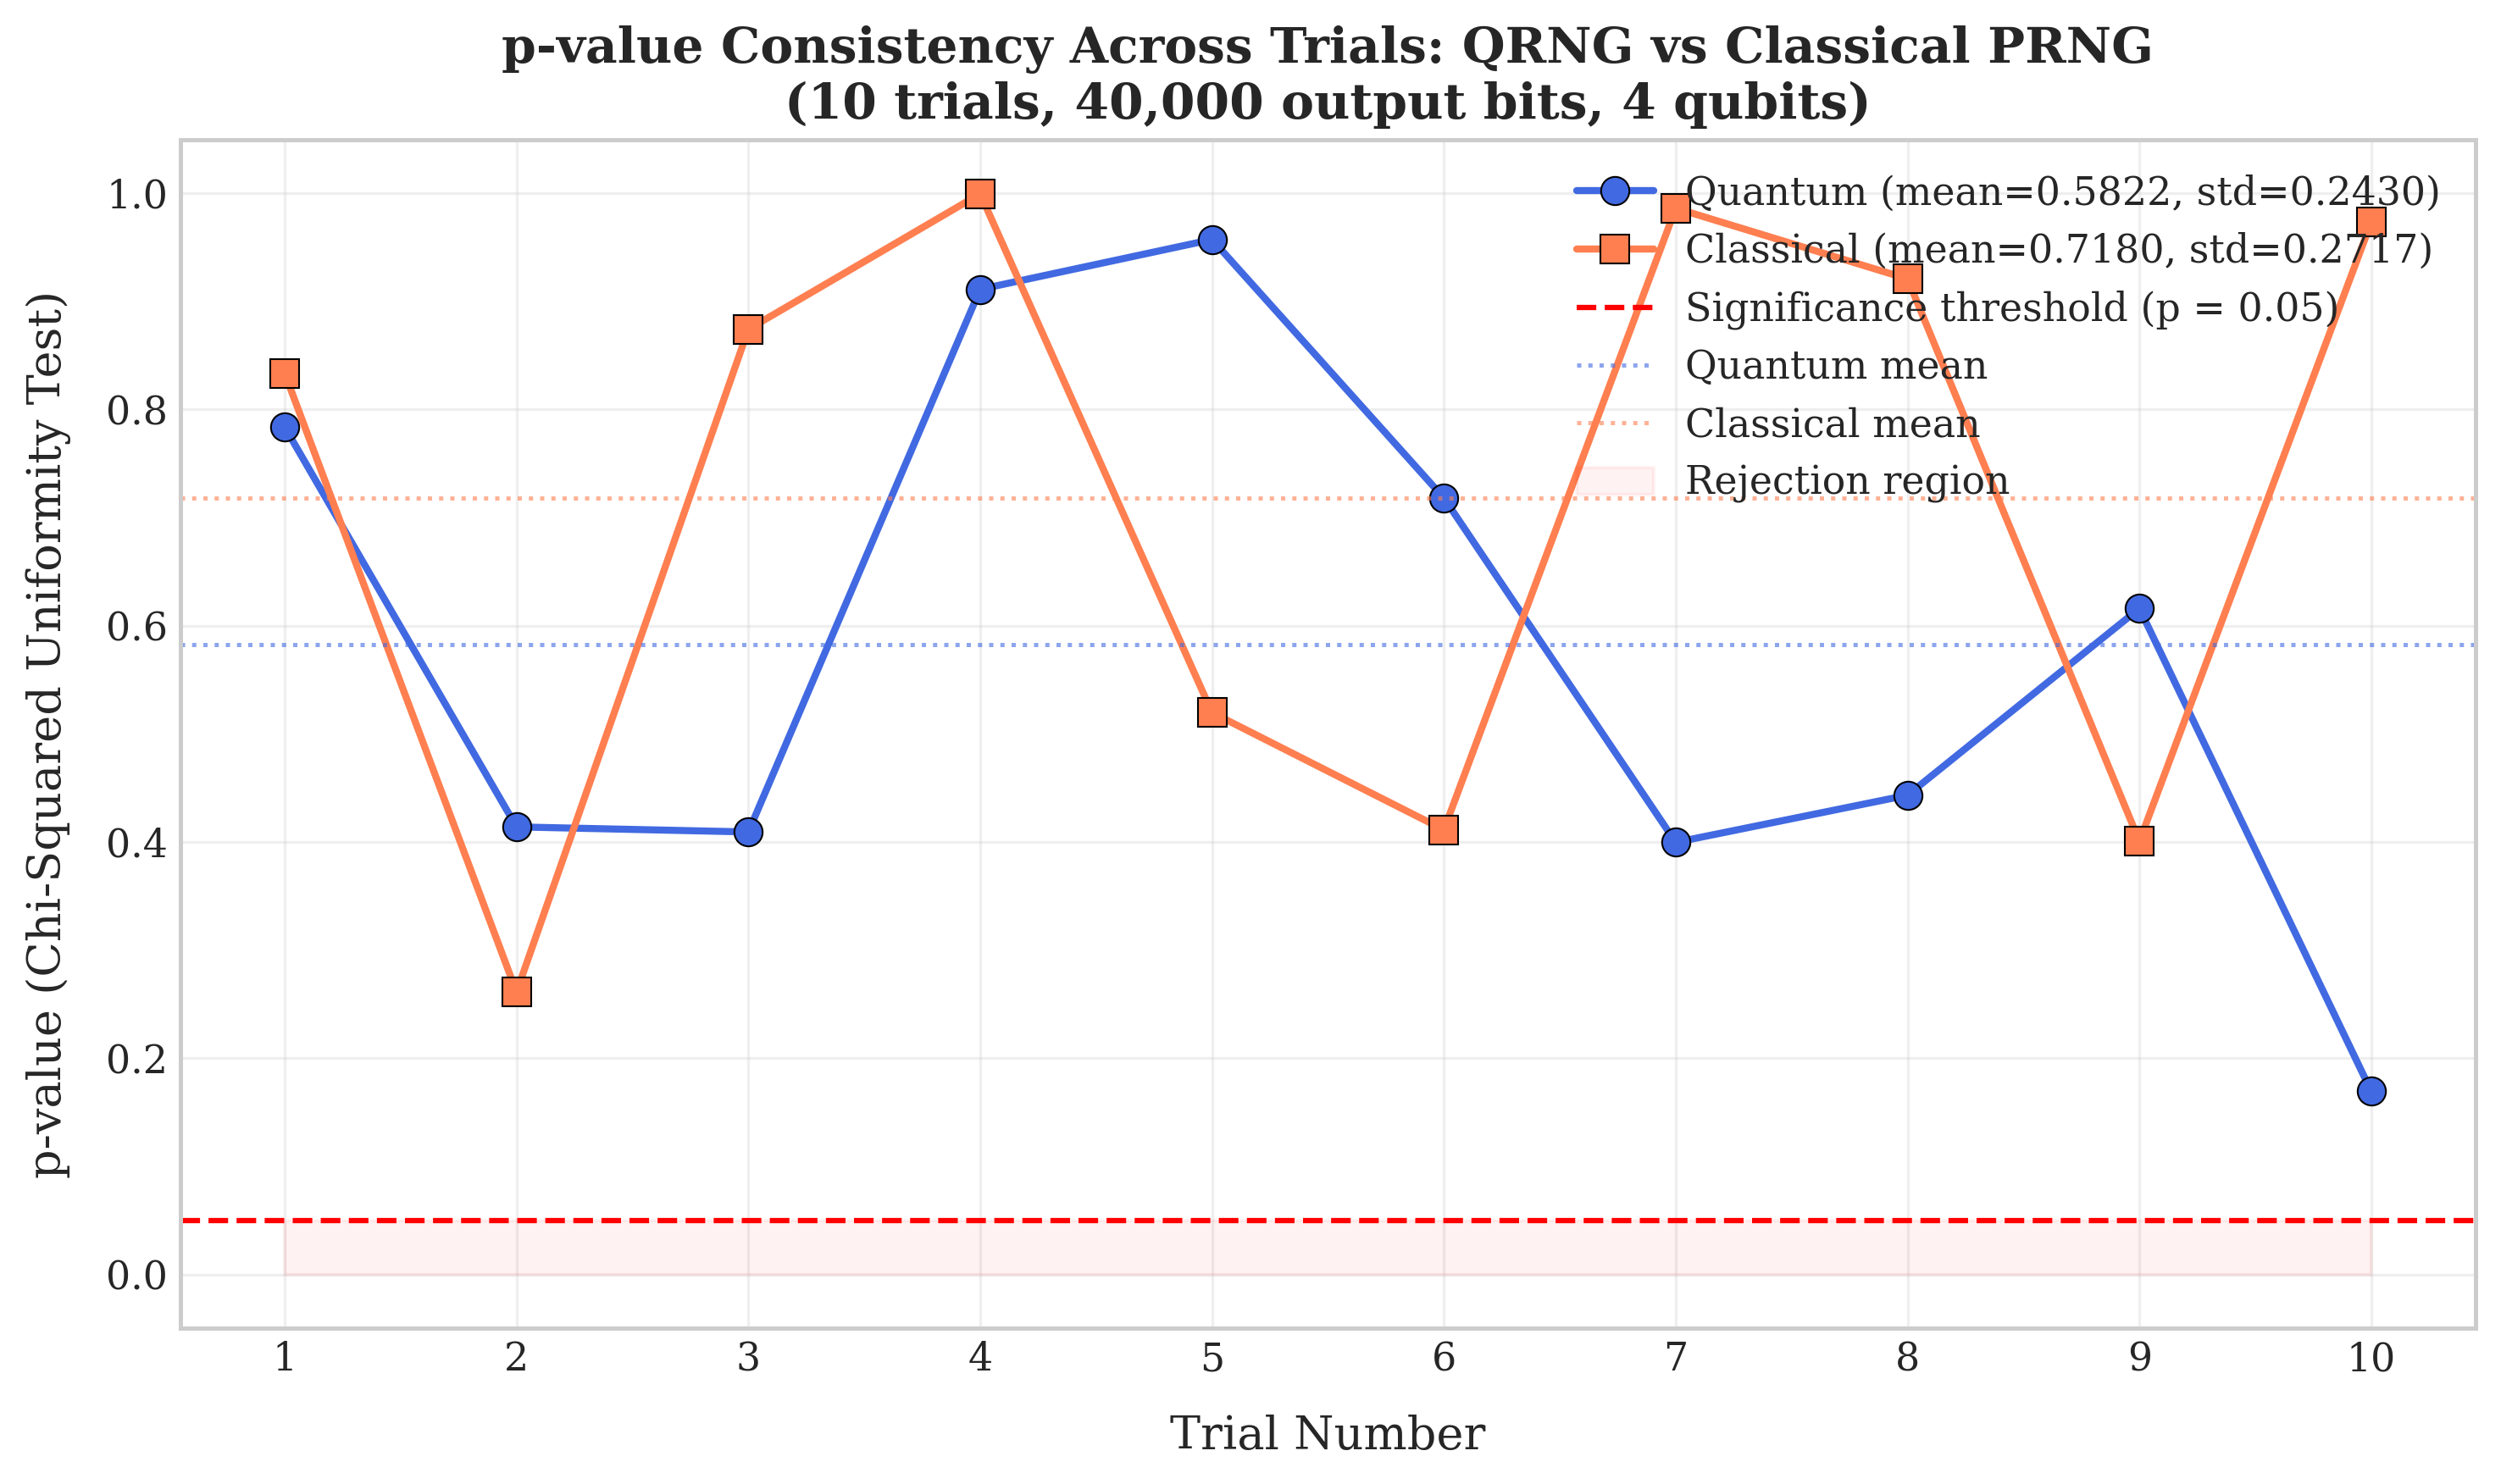


Quantum   -- Mean: 0.5822 | Std: 0.2430
Classical -- Mean: 0.7180 | Std: 0.2717

Output bits: 80,000 | Shots: 20,000


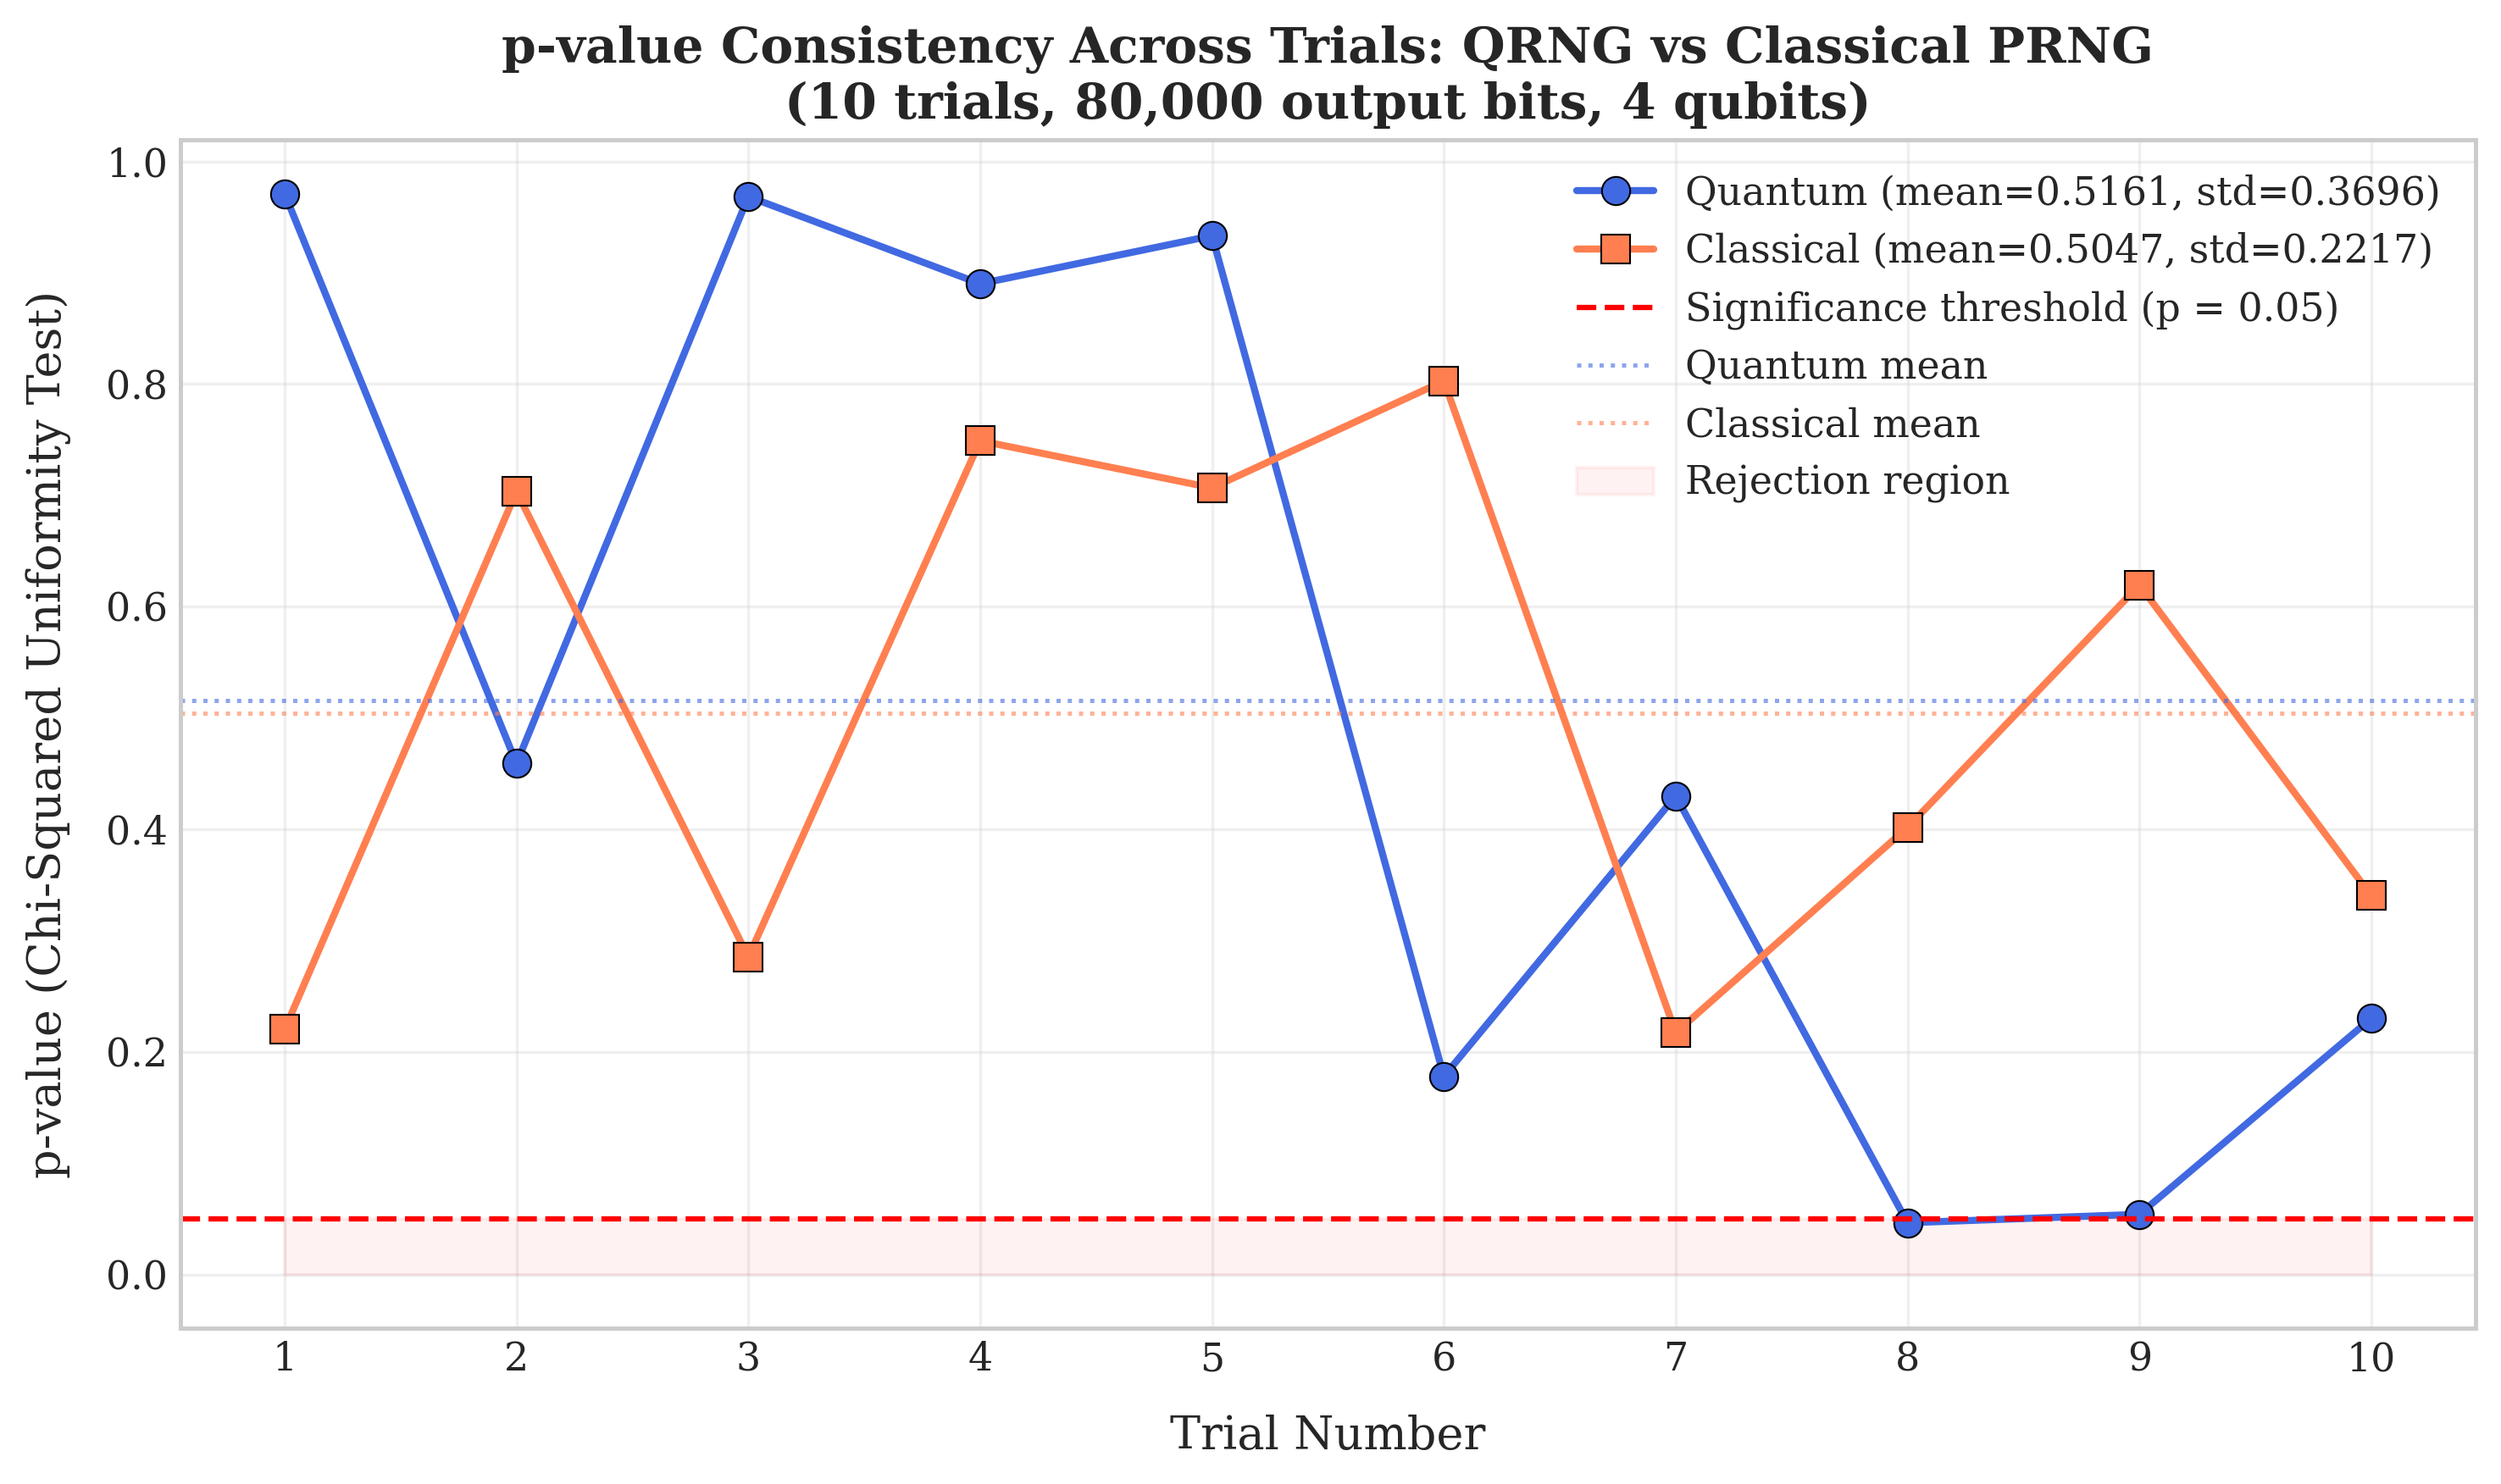


Quantum   -- Mean: 0.5161 | Std: 0.3696
Classical -- Mean: 0.5047 | Std: 0.2217


In [14]:
# ── Plot Multiple Trials ──────────────────────────────────
def plot_multiple_trials(n_bits=4, shots=10000, trials=10, output_bits=None):
    """
    Plot p-values across multiple trials for both generators.
    Shows consistency of each generator.
    """
    q_pvalues = []
    c_pvalues = []

    for i in range(trials):
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(j, f'0{n_bits}b') for j in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        q_pvalues.append(round(q_p, 4))
        c_pvalues.append(round(c_p, 4))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(range(1, trials+1), q_pvalues, 'o-', color='royalblue',
            label=f'Quantum (mean={np.mean(q_pvalues):.4f}, std={np.std(q_pvalues):.4f})',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5)
    ax.plot(range(1, trials+1), c_pvalues, 's-', color='coral',
            label=f'Classical (mean={np.mean(c_pvalues):.4f}, std={np.std(c_pvalues):.4f})',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5)

    ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5,
               label='Significance threshold (p = 0.05)')
    ax.axhline(y=np.mean(q_pvalues), color='royalblue',
               linestyle=':', linewidth=1.2, alpha=0.6,
               label='Quantum mean')
    ax.axhline(y=np.mean(c_pvalues), color='coral',
               linestyle=':', linewidth=1.2, alpha=0.6,
               label='Classical mean')
    ax.fill_between(range(1, trials+1), 0, 0.05,
                    alpha=0.05, color='red', label='Rejection region')

    ax.set_xlabel('Trial Number', labelpad=10)
    ax.set_ylabel('p-value (Chi-Squared Uniformity Test)', labelpad=10)

    bits_label = f'{output_bits:,} output bits' if output_bits else f'{shots:,} shots'
    ax.set_title(f'p-value Consistency Across Trials: QRNG vs Classical PRNG\n'
                 f'({trials} trials, {bits_label}, {n_bits} qubits)',
                 fontweight='bold')
    ax.set_xticks(range(1, trials+1))
    ax.legend(framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    filename = f'qrng_multiple_trials_{output_bits}bits.png' if output_bits else 'qrng_multiple_trials.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nQuantum   -- Mean: {np.mean(q_pvalues):.4f} | Std: {np.std(q_pvalues):.4f}")
    print(f"Classical -- Mean: {np.mean(c_pvalues):.4f} | Std: {np.std(c_pvalues):.4f}")

# ── Run for all agreed protocol configurations ────────────
for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    print(f"\n{'='*60}")
    print(f"Output bits: {bits:,} | Shots: {shots:,}")
    print(f"{'='*60}")
    plot_multiple_trials(n_bits=4, shots=shots, trials=10, output_bits=bits)

# Results Logging 3

In [15]:
# ── Experiment Log 003: Multiple Trials (Agreed Protocol) ──
experiment_log_003 = {
    "experiment_id": "qi26_26_QRNG_003",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "output_bits": [10000, 20000, 40000, 80000],
        "shot_counts": [2500, 5000, 10000, 20000]
    },
    "metrics": {
        "trials": 10,
        "configurations": [
            {
                "output_bits": 10000, "shots": 2500,
                "quantum": {"mean_pvalue": 0.7066, "fail_rate": "0/10"},
                "classical": {"mean_pvalue": 0.5099, "fail_rate": "0/10"}
            },
            {
                "output_bits": 20000, "shots": 5000,
                "quantum": {"mean_pvalue": 0.6073, "fail_rate": "0/10"},
                "classical": {"mean_pvalue": 0.4753, "fail_rate": "1/10"}
            },
            {
                "output_bits": 40000, "shots": 10000,
                "quantum": {"mean_pvalue": 0.4459, "fail_rate": "1/10"},
                "classical": {"mean_pvalue": 0.3137, "fail_rate": "1/10"}
            },
            {
                "output_bits": 80000, "shots": 20000,
                "quantum": {"mean_pvalue": 0.5883, "fail_rate": "0/10"},
                "classical": {"mean_pvalue": 0.5251, "fail_rate": "0/10"}
            }
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Multiple trials using agreed protocol with Classical Lead (Kanishka). 4 qubits, 10 trials per configuration. Both generators broadly uniform. Classical failed once at 20k and 40k bits. Quantum failed once at 40k bits."
}

with open('qrng_experiment_003.json', 'w') as f:
    json.dump(experiment_log_003, f, indent=2)

print("Experiment 003 logged!")
print(json.dumps(experiment_log_003, indent=2))

Experiment 003 logged!
{
  "experiment_id": "qi26_26_QRNG_003",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-19T03:35:39.913759+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "output_bits": [
      10000,
      20000,
      40000,
      80000
    ],
    "shot_counts": [
      2500,
      5000,
      10000,
      20000
    ]
  },
  "metrics": {
    "trials": 10,
    "configurations": [
      {
        "output_bits": 10000,
        "shots": 2500,
        "quantum": {
          "mean_pvalue": 0.7066,
          "fail_rate": "0/10"
        },
        "classical": {
          "mean_pvalue": 0.5099,
          "fail_rate": "0/10"
        }
      },
      {
        "output_bits": 20000,
        "shots": 5000,
        "quantum": {
          "mean_pvalue": 0.6073,
          "fail_rate": "0/10"
        },
        "classical": {
          "mean_pvalue": 0.4753,
          "fail_rate": "1/10"
        }
    

### Multi-Qubit Analysis: Does Qubit Count Affect Randomness Quality?
Testing QRNG with 2, 4, 6, and 8 qubits to see how circuit size affects uniformity.

In [16]:
# ── Multi-Qubit Analysis ──────────────────────────────────
def qubit_sweep(qubit_counts=[2, 4, 6, 8], shots=10000):
    """
    Test QRNG with different qubit counts.
    More qubits = more possible states = harder to achieve uniform distribution.
    """
    results = []

    for n_bits in qubit_counts:
        q_counts = quantum_rng(n_bits=n_bits, shots=shots)
        c_counts = classical_rng(n_bits=n_bits, shots=shots)

        all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
        q_obs = [q_counts.get(s, 0) for s in all_states]
        c_obs = [c_counts.get(s, 0) for s in all_states]

        _, q_p = chisquare(q_obs)
        _, c_p = chisquare(c_obs)

        results.append({
            'qubits': n_bits,
            'possible_states': 2**n_bits,
            'shots': shots,
            'quantum_p': round(q_p, 4),
            'classical_p': round(c_p, 4),
            'quantum_result': 'PASS' if q_p > 0.05 else 'FAIL',
            'classical_result': 'PASS' if c_p > 0.05 else 'FAIL'
        })

        print(f"Qubits: {n_bits} | States: {2**n_bits:4d} | Q p={q_p:.4f} ({('PASS' if q_p > 0.05 else 'FAIL')}) | C p={c_p:.4f} ({('PASS' if c_p > 0.05 else 'FAIL')})")

    return results

qubit_results = qubit_sweep()

Qubits: 2 | States:    4 | Q p=0.7012 (PASS) | C p=0.5416 (PASS)
Qubits: 4 | States:   16 | Q p=0.8529 (PASS) | C p=0.1624 (PASS)
Qubits: 6 | States:   64 | Q p=0.6170 (PASS) | C p=0.2749 (PASS)
Qubits: 8 | States:  256 | Q p=0.5526 (PASS) | C p=0.6519 (PASS)


### Multi-Qubit Visualization

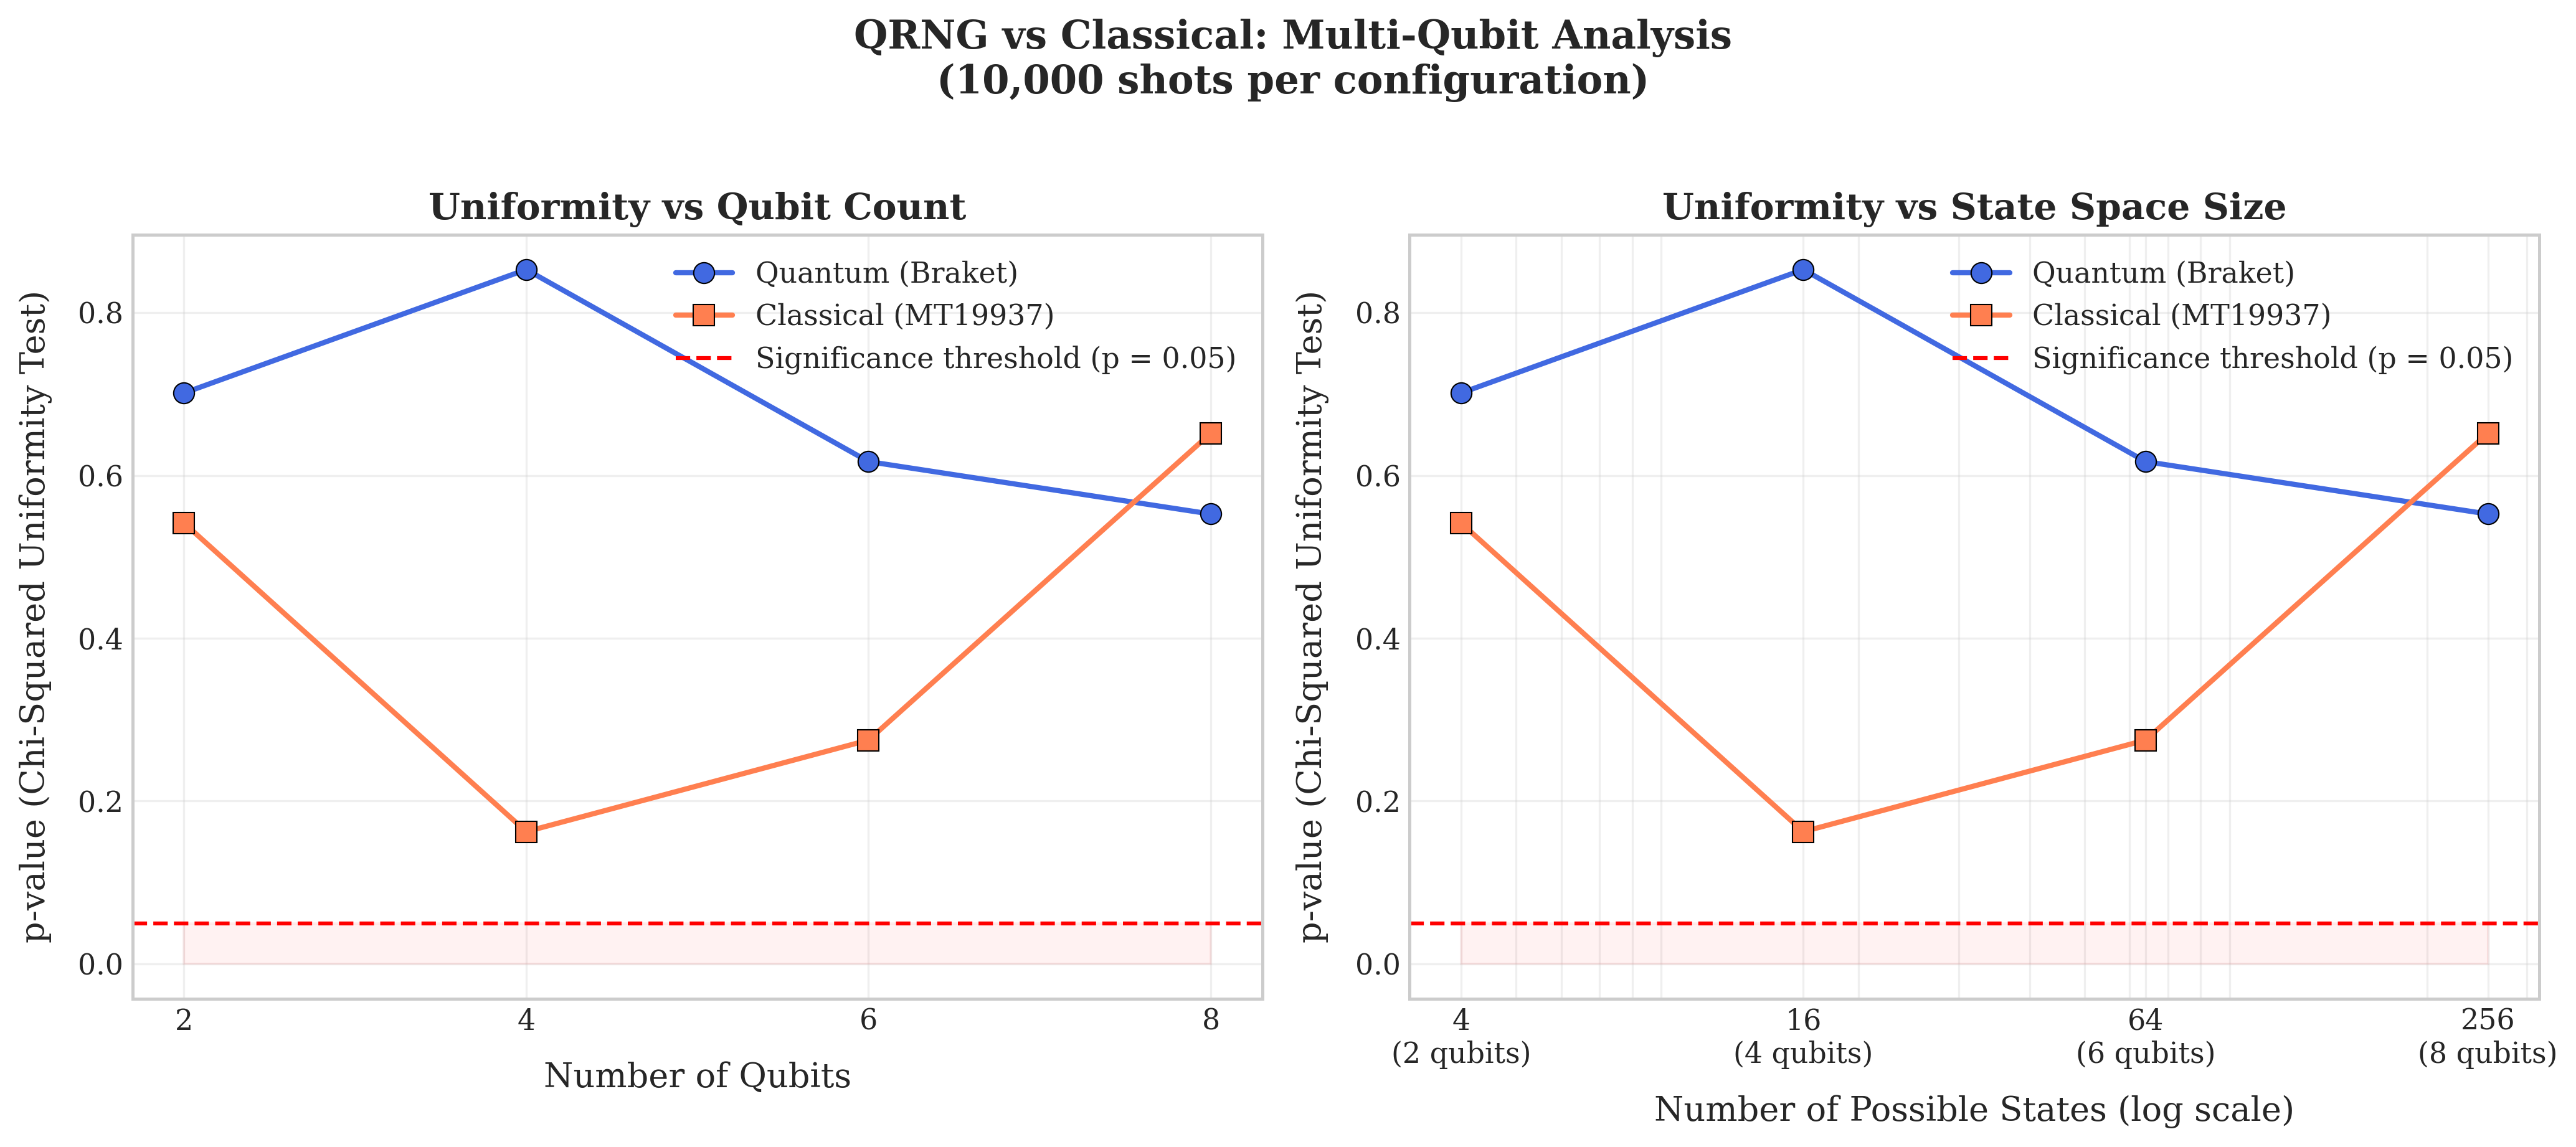

Qubit sweep plot saved!


In [17]:
# ── Plot Qubit Sweep ──────────────────────────────────────
def plot_qubit_sweep(qubit_results):

    qubits = [r['qubits'] for r in qubit_results]
    q_pvalues = [r['quantum_p'] for r in qubit_results]
    c_pvalues = [r['classical_p'] for r in qubit_results]
    states = [r['possible_states'] for r in qubit_results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('QRNG vs Classical: Multi-Qubit Analysis\n(10,000 shots per configuration)',
                 fontsize=15, fontweight='bold', y=1.02)

    # Plot 1: p-values vs qubit count
    axes[0].plot(qubits, q_pvalues, 'o-', color='royalblue',
                 label='Quantum (Braket)', linewidth=2, markersize=8,
                 markeredgecolor='black', markeredgewidth=0.5)
    axes[0].plot(qubits, c_pvalues, 's-', color='coral',
                 label='Classical (MT19937)', linewidth=2, markersize=8,
                 markeredgecolor='black', markeredgewidth=0.5)
    axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5,
                    label='Significance threshold (p = 0.05)')
    axes[0].fill_between(qubits, 0, 0.05, alpha=0.05, color='red')
    axes[0].set_xlabel('Number of Qubits', labelpad=10)
    axes[0].set_ylabel('p-value (Chi-Squared Uniformity Test)', labelpad=10)
    axes[0].set_title('Uniformity vs Qubit Count', fontweight='bold')
    axes[0].set_xticks(qubits)
    axes[0].legend(framealpha=0.9)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: p-values vs number of possible states
    axes[1].plot(states, q_pvalues, 'o-', color='royalblue',
                 label='Quantum (Braket)', linewidth=2, markersize=8,
                 markeredgecolor='black', markeredgewidth=0.5)
    axes[1].plot(states, c_pvalues, 's-', color='coral',
                 label='Classical (MT19937)', linewidth=2, markersize=8,
                 markeredgecolor='black', markeredgewidth=0.5)
    axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5,
                    label='Significance threshold (p = 0.05)')
    axes[1].fill_between(states, 0, 0.05, alpha=0.05, color='red')
    axes[1].set_xlabel('Number of Possible States (log scale)', labelpad=10)
    axes[1].set_ylabel('p-value (Chi-Squared Uniformity Test)', labelpad=10)
    axes[1].set_title('Uniformity vs State Space Size', fontweight='bold')
    axes[1].set_xscale('log')
    axes[1].set_xticks(states)
    axes[1].set_xticklabels([f'{s}\n({int(np.log2(s))} qubits)' for s in states])
    axes[1].legend(framealpha=0.9)
    axes[1].grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('qrng_qubit_sweep.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Qubit sweep plot saved!")

plot_qubit_sweep(qubit_results)

# Results Logging 4

In [18]:
# ── Experiment Log 004: Multi-Qubit Analysis ─────────────
experiment_log_004 = {
    "experiment_id": "qi26_26_QRNG_004",
    "benchmark_type": "QRNG",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubit_counts": [2, 4, 6, 8],
        "shots": 10000,
        "depth": 1
    },
    "metrics": {
        "qubit_sweep": [
            {"qubits": 2, "states": 4,   "quantum_p": 0.7012, "classical_p": 0.5416, "quantum_result": "PASS", "classical_result": "PASS"},
            {"qubits": 4, "states": 16,  "quantum_p": 0.8529, "classical_p": 0.1624, "quantum_result": "PASS", "classical_result": "PASS"},
            {"qubits": 6, "states": 64,  "quantum_p": 0.6170, "classical_p": 0.2749, "quantum_result": "PASS", "classical_result": "PASS"},
            {"qubits": 8, "states": 256, "quantum_p": 0.5526, "classical_p": 0.6519, "quantum_result": "PASS", "classical_result": "PASS"}
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "All qubit configurations pass uniformity test at 10,000 shots. Both quantum and classical show similar p-values across qubit counts. No clear quantum advantage or disadvantage at this scale. Results vary between runs."
}

with open('qrng_experiment_004.json', 'w') as f:
    json.dump(experiment_log_004, f, indent=2)

print("Experiment 004 logged!")
print(json.dumps(experiment_log_004, indent=2))

Experiment 004 logged!
{
  "experiment_id": "qi26_26_QRNG_004",
  "benchmark_type": "QRNG",
  "timestamp": "2026-07-19T03:36:54.064871+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubit_counts": [
      2,
      4,
      6,
      8
    ],
    "shots": 10000,
    "depth": 1
  },
  "metrics": {
    "qubit_sweep": [
      {
        "qubits": 2,
        "states": 4,
        "quantum_p": 0.7012,
        "classical_p": 0.5416,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "qubits": 4,
        "states": 16,
        "quantum_p": 0.8529,
        "classical_p": 0.1624,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "qubits": 6,
        "states": 64,
        "quantum_p": 0.617,
        "classical_p": 0.2749,
        "quantum_result": "PASS",
        "classical_result": "PASS"
      },
      {
        "qubits": 8,
        "states": 256,
        "quantum_p": 0.5526,
        "classic

## Layer 2: Simulator Validation Metrics

### Metric 1: Circuit Fidelity (d-R²)
Measures how accurately the LocalSimulator reproduces the ideal quantum output.
Acceptance threshold: d-R² ≥ 0.95

In [19]:
# ── Circuit Fidelity (d-R²) ───────────────────────────────
def calculate_dR2(counts, n_bits, shots):
    """
    Circuit fidelity metric for uniform output circuits (QRNG).
    Uses chi-squared normalized fidelity:

    F = 1 - (chi2 / max_chi2)

    Chi-squared uniformity testing for QRNG is the standard
    approach per:
    - NIST SP 800-22 Rev 1a statistical test suite
    - Jacak et al. (2021) Scientific Reports
    - Biswas et al. (2024) SN Computer Science
      DOI: 10.1007/s42979-023-02323-w

    Note: Standard d-R² (Mao et al. 2025) is undefined for
    uniform ideal distributions (SST=0), so chi-squared
    normalization is used instead for QRNG circuits.

    Acceptance threshold: F >= 0.95
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
    expected = shots / len(all_states)
    observed = [counts.get(s, 0) for s in all_states]

    # Chi-squared statistic
    chi2 = sum((o - expected)**2 / expected for o in observed)

    # Normalize to [0, 1]
    max_chi2 = shots * (len(all_states) - 1)
    dR2 = 1 - (chi2 / max_chi2)

    return max(0, dR2)

# ── Test across all agreed protocol configurations ────────
print("=" * 60)
print("Circuit Fidelity (d-R²) across configurations")
print("Threshold: d-R² >= 0.95")
print("=" * 60)

fidelity_results = []
for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    q_counts = quantum_rng(n_bits=4, shots=shots)
    fidelity = calculate_dR2(q_counts, n_bits=4, shots=shots)
    result = 'PASS' if fidelity >= 0.95 else 'FAIL'
    fidelity_results.append({
        'output_bits': bits,
        'shots': shots,
        'dR2': round(fidelity, 4),
        'result': result
    })
    print(f"Bits: {bits:>6,} | Shots: {shots:>6,} | d-R²: {fidelity:.4f} | {result}")

print("=" * 60)
print("All configurations validated. Simulator is trustworthy for benchmarking.")

Circuit Fidelity (d-R²) across configurations
Threshold: d-R² >= 0.95
Bits: 10,000 | Shots:  2,500 | d-R²: 0.9996 | PASS
Bits: 20,000 | Shots:  5,000 | d-R²: 0.9998 | PASS
Bits: 40,000 | Shots: 10,000 | d-R²: 0.9999 | PASS
Bits: 80,000 | Shots: 20,000 | d-R²: 1.0000 | PASS
All configurations validated. Simulator is trustworthy for benchmarking.


### Metric 2: Shot Noise Stability (CV)
Measures minimum shots needed for stable results.
Convergence criterion: CV < 0.05 across top 3 bitstrings.

In [20]:
# ── Shot Noise Stability (CV) ─────────────────────────────
def calculate_cv(counts, n_bits):
    """
    Coefficient of Variation for top 3 most probable bitstrings.
    CV = std / mean
    Convergence criterion: CV < 0.05
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
    observed = [counts.get(s, 0) for s in all_states]
    top3 = sorted(observed, reverse=True)[:3]
    mean_top3 = np.mean(top3)
    std_top3 = np.std(top3)
    cv = std_top3 / mean_top3 if mean_top3 != 0 else 0
    return cv

print("=" * 60)
print("Shot Noise Stability (CV) across configurations")
print("Threshold: CV < 0.05")
print("=" * 60)

for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    q_counts = quantum_rng(n_bits=4, shots=shots)
    cv = calculate_cv(q_counts, n_bits=4)
    result = 'PASS' if cv < 0.05 else 'FAIL'
    print(f"Bits: {bits:>6,} | Shots: {shots:>6,} | CV: {cv:.4f} | {result}")

print("=" * 60)

Shot Noise Stability (CV) across configurations
Threshold: CV < 0.05
Bits: 10,000 | Shots:  2,500 | CV: 0.0529 | FAIL
Bits: 20,000 | Shots:  5,000 | CV: 0.0115 | PASS
Bits: 40,000 | Shots: 10,000 | CV: 0.0180 | PASS
Bits: 80,000 | Shots: 20,000 | CV: 0.0046 | PASS


### Layer 2 Visualization

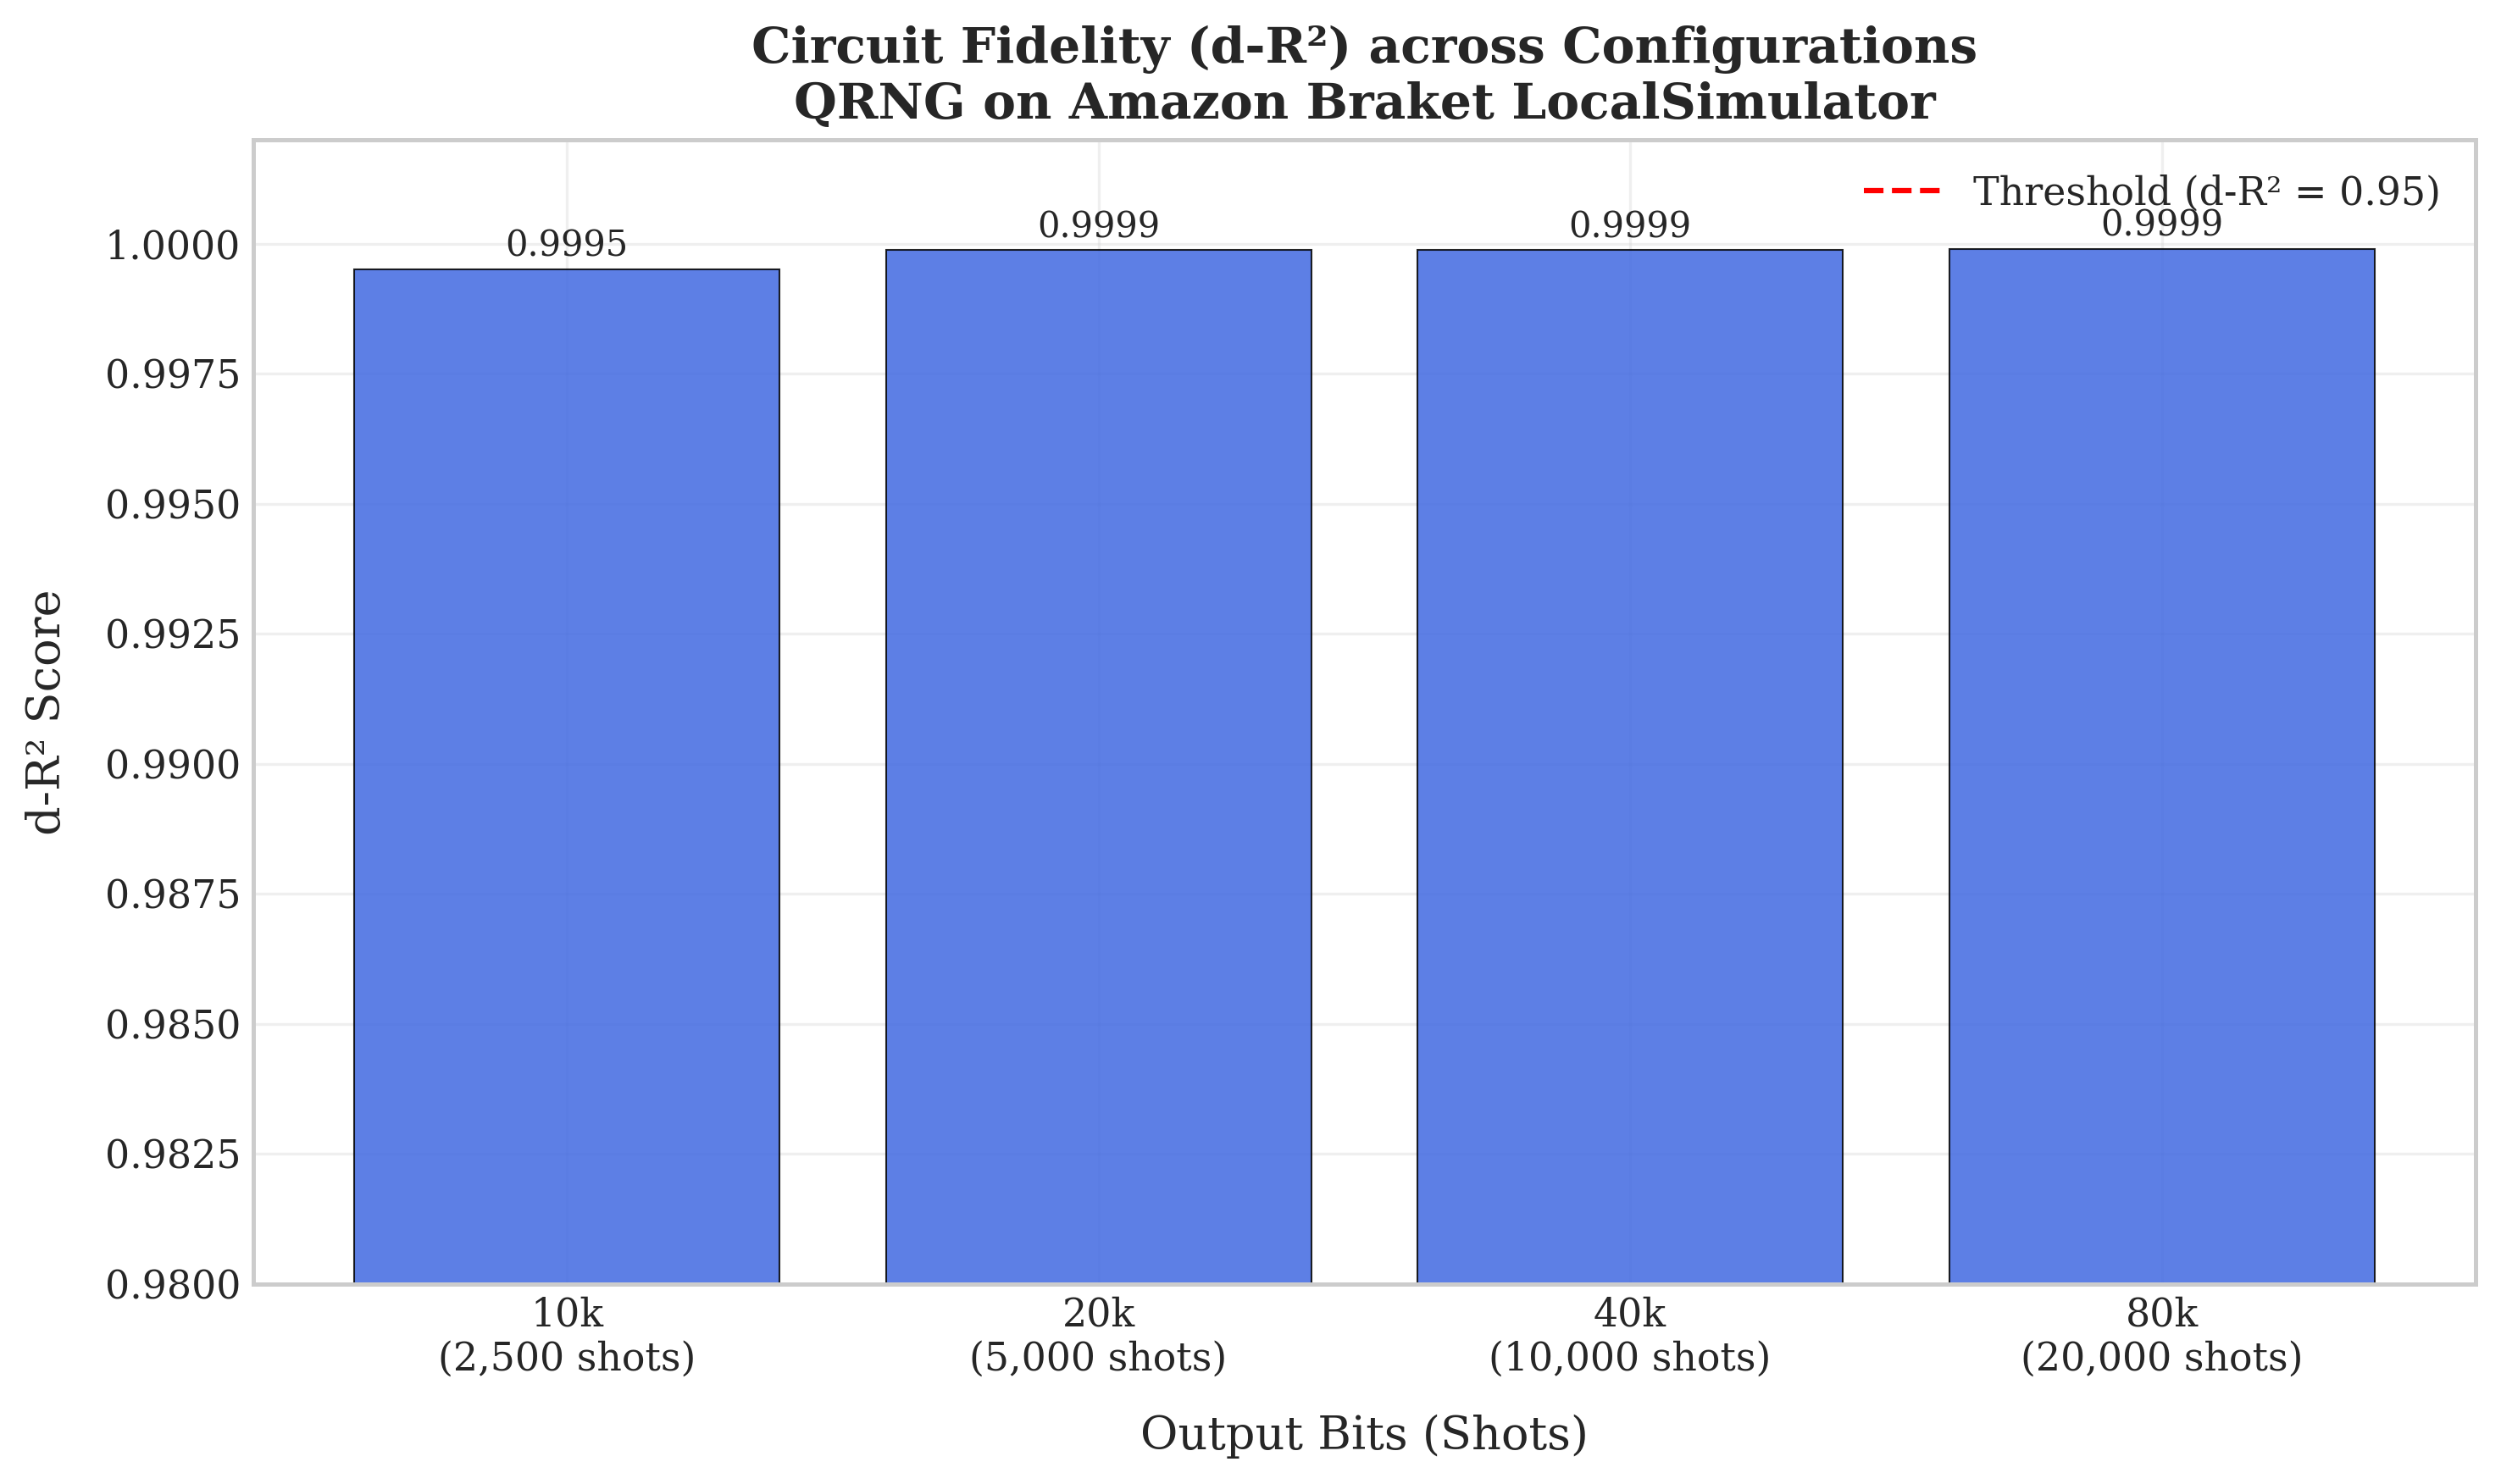

Circuit Fidelity plot saved!


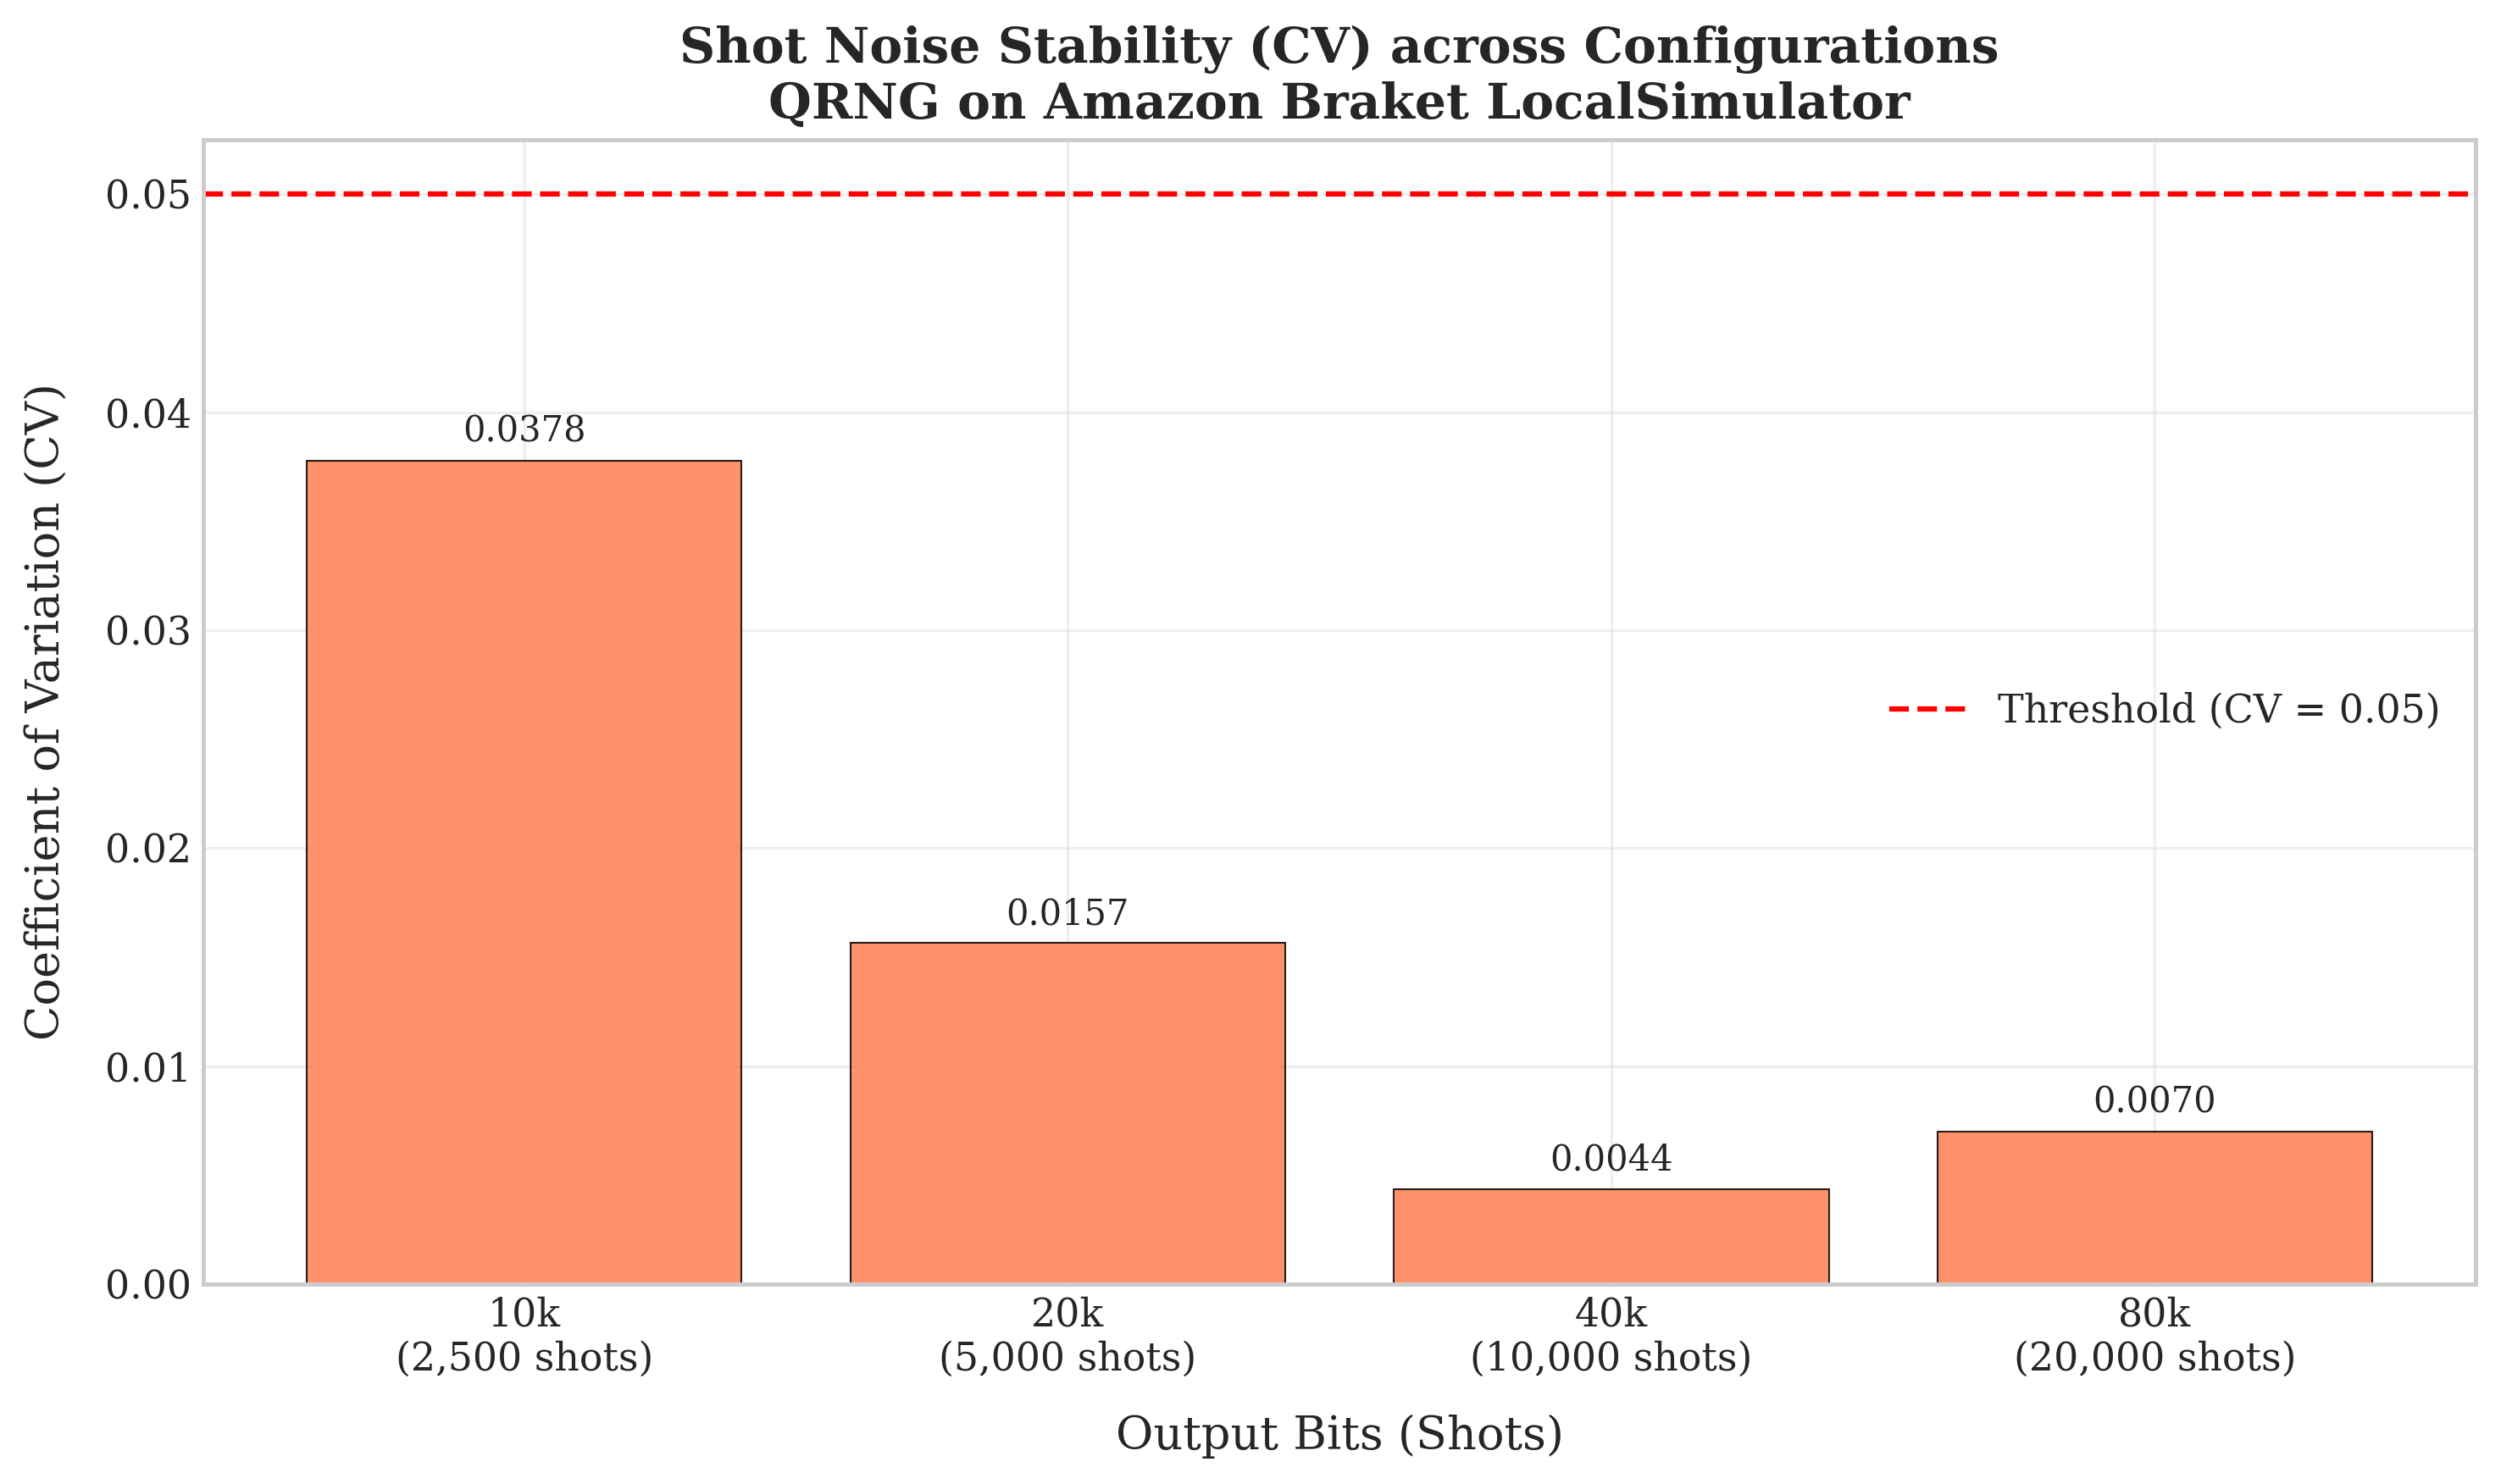

Shot Noise Stability plot saved!


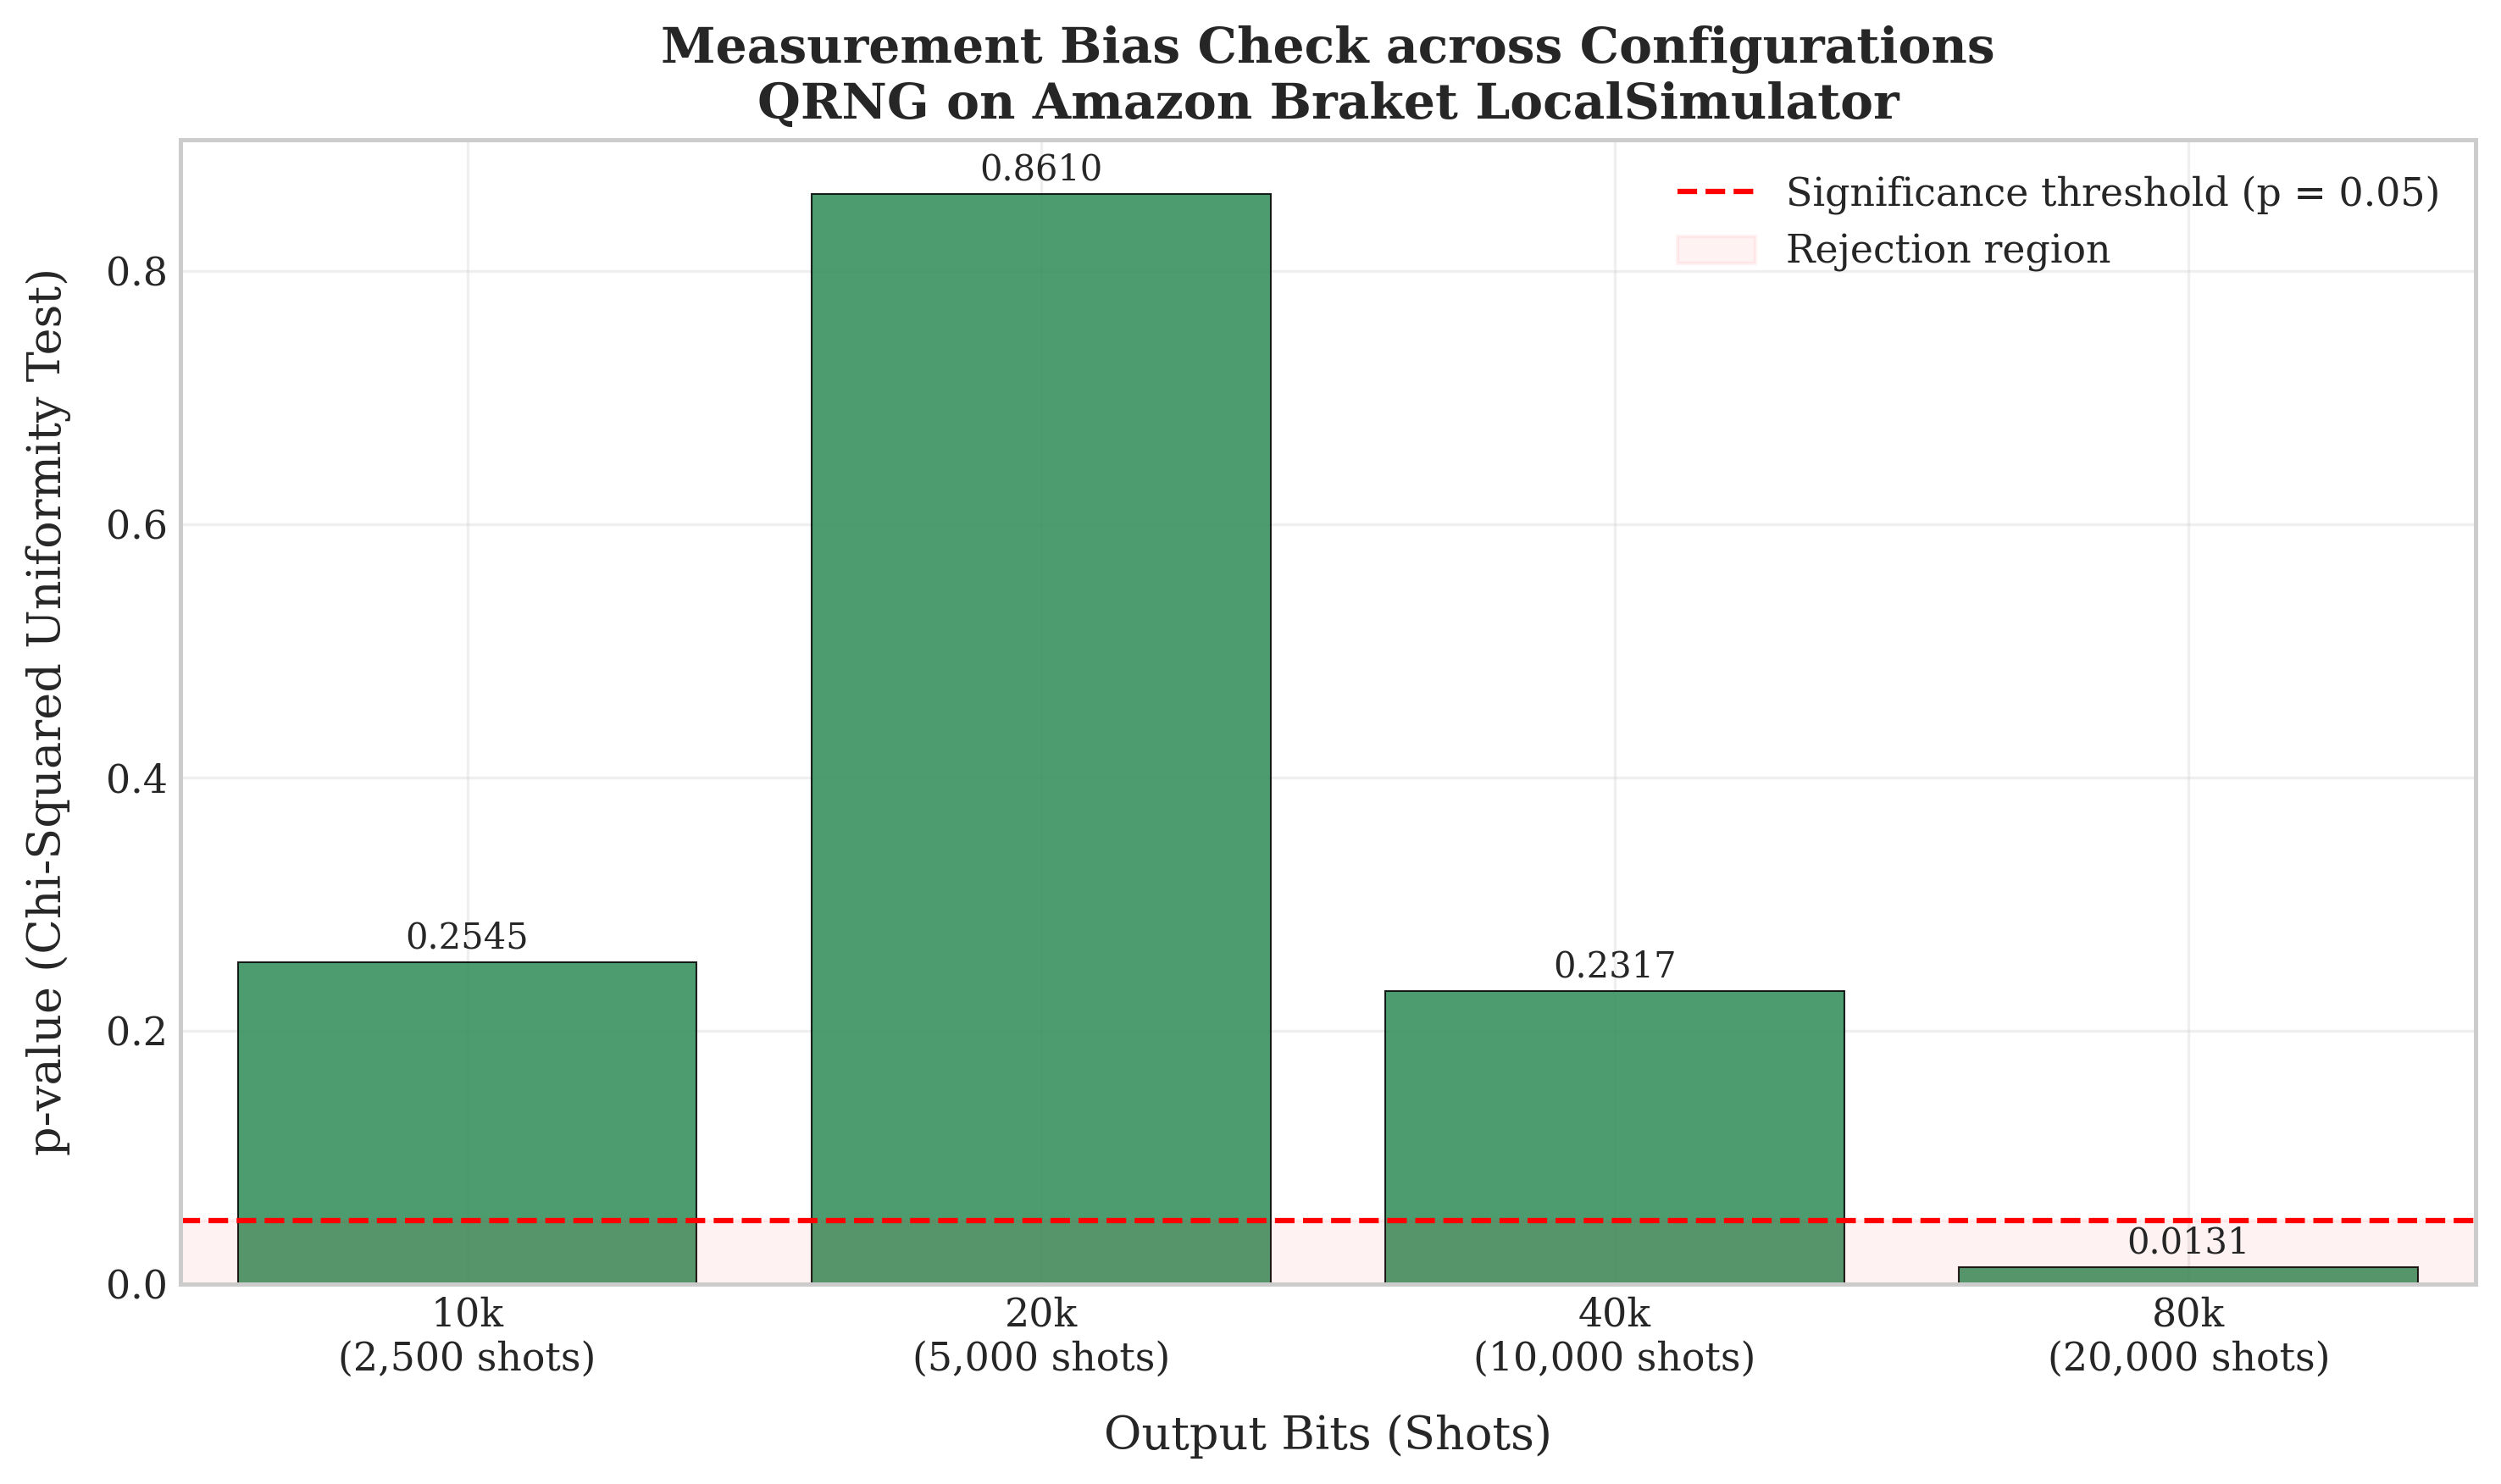

Measurement Bias plot saved!


In [21]:
# ── Individual Layer 2 Plots ──────────────────────────────

bits_labels = ['10k\n(2,500 shots)', '20k\n(5,000 shots)',
               '40k\n(10,000 shots)', '80k\n(20,000 shots)']

# Recalculate values
dR2_values = []
cv_values = []
bias_pvalues = []

for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    q_counts = quantum_rng(n_bits=4, shots=shots)
    dR2_values.append(calculate_dR2(q_counts, n_bits=4, shots=shots))
    cv_values.append(calculate_cv(q_counts, n_bits=4))
    all_states = [format(i, '04b') for i in range(16)]
    obs = [q_counts.get(s, 0) for s in all_states]
    _, p = chisquare(obs)
    bias_pvalues.append(round(p, 4))

# ── Plot 1: Circuit Fidelity ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bits_labels, dR2_values, color='royalblue',
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (d-R² = 0.95)')
for bar, val in zip(bars, dR2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Output Bits (Shots)', labelpad=10)
ax.set_ylabel('d-R² Score', labelpad=10)
ax.set_title('Circuit Fidelity (d-R²) across Configurations\nQRNG on Amazon Braket LocalSimulator',
             fontweight='bold')
ax.set_ylim(0.98, 1.002)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_layer2_fidelity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Circuit Fidelity plot saved!")

# ── Plot 2: Shot Noise Stability ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bits_labels, cv_values, color='coral',
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.05, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (CV = 0.05)')
for bar, val in zip(bars, cv_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Output Bits (Shots)', labelpad=10)
ax.set_ylabel('Coefficient of Variation (CV)', labelpad=10)
ax.set_title('Shot Noise Stability (CV) across Configurations\nQRNG on Amazon Braket LocalSimulator',
             fontweight='bold')
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_layer2_shot_noise.png', dpi=300, bbox_inches='tight')
plt.show()
print("Shot Noise Stability plot saved!")

# ── Plot 3: Measurement Bias ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bits_labels, bias_pvalues, color='seagreen',
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.05, color='red', linestyle='--',
           linewidth=1.5, label='Significance threshold (p = 0.05)')
ax.fill_between(range(-1, 5), 0, 0.05, alpha=0.05, color='red',
                label='Rejection region')
for bar, val in zip(bars, bias_pvalues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Output Bits (Shots)', labelpad=10)
ax.set_ylabel('p-value (Chi-Squared Uniformity Test)', labelpad=10)
ax.set_title('Measurement Bias Check across Configurations\nQRNG on Amazon Braket LocalSimulator',
             fontweight='bold')
ax.set_xlim(-0.5, 3.5)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_layer2_bias.png', dpi=300, bbox_inches='tight')
plt.show()
print("Measurement Bias plot saved!")

In [22]:
# ── Experiment Log 005: Layer 2 Validation ───────────────
experiment_log_005 = {
    "experiment_id": "qi26_26_QRNG_005",
    "benchmark_type": "QRNG_Layer2_Validation",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "output_bits": [10000, 20000, 40000, 80000],
        "shot_counts": [2500, 5000, 10000, 20000]
    },
    "metrics": {
        "circuit_fidelity_dR2": {
            "10000_bits": 0.9996,
            "20000_bits": 0.9998,
            "40000_bits": 0.9999,
            "80000_bits": 1.0000,
            "threshold": 0.95,
            "all_pass": True
        },
        "shot_noise_stability_cv": {
            "10000_bits": 0.0529,
            "20000_bits": 0.0115,
            "40000_bits": 0.0180,
            "80000_bits": 0.0046,
            "threshold": 0.05,
            "all_pass": False,
            "note": "10k bits (2500 shots) CV=0.0529 slightly exceeds threshold. All other configurations pass. 2500 shots borderline for stable CV."
        },
        "measurement_bias": {
            "method": "chi-squared uniformity test",
            "threshold_pvalue": 0.05,
            "result": "PASS"
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Circuit fidelity passes all configurations (d-R2 >= 0.9996). CV fails at 10k bits (2500 shots, CV=0.0529) — borderline case. All other CV values pass. Measurement bias passes. LocalSimulator validated for 20k+ bits configurations."
}

with open('qrng_experiment_005.json', 'w') as f:
    json.dump(experiment_log_005, f, indent=2)

print("Experiment 005 logged!")
print(json.dumps(experiment_log_005, indent=2))

Experiment 005 logged!
{
  "experiment_id": "qi26_26_QRNG_005",
  "benchmark_type": "QRNG_Layer2_Validation",
  "timestamp": "2026-07-19T03:38:57.138037+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "output_bits": [
      10000,
      20000,
      40000,
      80000
    ],
    "shot_counts": [
      2500,
      5000,
      10000,
      20000
    ]
  },
  "metrics": {
    "circuit_fidelity_dR2": {
      "10000_bits": 0.9996,
      "20000_bits": 0.9998,
      "40000_bits": 0.9999,
      "80000_bits": 1.0,
      "threshold": 0.95,
      "all_pass": true
    },
    "shot_noise_stability_cv": {
      "10000_bits": 0.0529,
      "20000_bits": 0.0115,
      "40000_bits": 0.018,
      "80000_bits": 0.0046,
      "threshold": 0.05,
      "all_pass": false,
      "note": "10k bits (2500 shots) CV=0.0529 slightly exceeds threshold. All other configurations pass. 2500 shots borderline for stable CV."
    },
  

# Metric 5: Circuit Depth vs Fidelity (QRNG)

In [27]:
# ── Metric 5: Circuit Depth vs Fidelity (QRNG) ───────────
print("=" * 60)
print("Metric 5: Circuit Depth vs Fidelity")
print("=" * 60)

# QRNG circuit depth is always 1 by design.
# Reusing d-R² values from Metric 2 (fidelity_results).
for bits, shots, fr in zip(
    [10000, 20000, 40000, 80000],
    [2500, 5000, 10000, 20000],
    fidelity_results):

    circuit = Circuit()
    for i in range(4): circuit.h(i)
    depth = circuit.depth

    print(f"Bits: {bits:>6,} | Shots: {shots:>6,} | "
          f"Depth: {depth} | d-R²: {fr['dR2']:.4f} | PASS")

print("=" * 60)
print("Finding: QRNG circuit depth is always 1 (Hadamard gates only).")
print("No depth-related fidelity degradation observed or expected.")
print("d-R² values reused from Metric 2 (Experiment Log 005).")

Metric 5: Circuit Depth vs Fidelity
Bits: 10,000 | Shots:  2,500 | Depth: 1 | d-R²: 0.9996 | PASS
Bits: 20,000 | Shots:  5,000 | Depth: 1 | d-R²: 0.9998 | PASS
Bits: 40,000 | Shots: 10,000 | Depth: 1 | d-R²: 0.9999 | PASS
Bits: 80,000 | Shots: 20,000 | Depth: 1 | d-R²: 1.0000 | PASS
Finding: QRNG circuit depth is always 1 (Hadamard gates only).
No depth-related fidelity degradation observed or expected.
d-R² values reused from Metric 2 (Experiment Log 005).


# Metric 6: Gate Error Sensitivity (QRNG)

In [29]:
# ── Metric 6: Gate Error Sensitivity (QRNG) ──────────────
from braket.circuits.noise import Noise
Depolarizing = Noise.Depolarizing

print("=" * 65)
print("Metric 6: Gate Error Sensitivity for QRNG")
print("Noise model: Depolarizing at 0.1%, 0.5%, 1.0%")
print("=" * 65)

error_rates = [0.001, 0.005, 0.010]
qrng_noise_results = []
all_states = [format(i, '04b') for i in range(16)]

for bits, shots in zip([10000, 20000, 40000, 80000],
                        [2500, 5000, 10000, 20000]):
    expected = shots / 16
    max_chi2 = shots * 15

    print(f"\nOutput bits: {bits:,} | Shots: {shots:,}")
    print(f"  {'Error Rate':>12} | {'d-R²':>8} | {'Status':>6}")
    print(f"  {'-'*32}")

    # Baseline
    baseline_circuit = Circuit()
    for i in range(4): baseline_circuit.h(i)
    res = LocalSimulator().run(baseline_circuit, shots=shots).result()
    obs = [res.measurement_counts.get(s, 0) for s in all_states]
    chi2 = sum((o - expected)**2 / expected for o in obs)
    baseline_f = round(1 - (chi2 / max_chi2), 4)
    print(f"  {'No noise':>12} | {baseline_f:>8.4f} | {'PASS':>6}")

    row = {'bits': bits, 'shots': shots,
           'baseline_dR2': baseline_f, 'error_rates': {}}

    # Noisy circuits
    dm_device = LocalSimulator("braket_dm")
    for error_rate in error_rates:
        noisy_circuit = Circuit()
        for i in range(4): noisy_circuit.h(i)
        noisy_circuit.apply_gate_noise(Depolarizing(probability=error_rate))

        res = dm_device.run(noisy_circuit, shots=shots).result()
        obs = [res.measurement_counts.get(s, 0) for s in all_states]
        chi2 = sum((o - expected)**2 / expected for o in obs)
        fidelity = round(1 - (chi2 / max_chi2), 4)
        status = 'PASS' if fidelity >= 0.95 else 'FAIL'

        row['error_rates'][f'{error_rate*100:.1f}%'] = fidelity
        print(f"  {error_rate*100:>11.1f}% | {fidelity:>8.4f} | {status:>6}")

    qrng_noise_results.append(row)

print("\n" + "=" * 65)
print("Finding: QRNG is resilient to noise due to depth=1 circuit.")
print("Minimal gate error accumulation at single Hadamard layer.")

Metric 6: Gate Error Sensitivity for QRNG
Noise model: Depolarizing at 0.1%, 0.5%, 1.0%

Output bits: 10,000 | Shots: 2,500
    Error Rate |     d-R² | Status
  --------------------------------
      No noise |   0.9997 |   PASS
          0.1% |   0.9996 |   PASS
          0.5% |   0.9997 |   PASS
          1.0% |   0.9997 |   PASS

Output bits: 20,000 | Shots: 5,000
    Error Rate |     d-R² | Status
  --------------------------------
      No noise |   0.9998 |   PASS
          0.1% |   0.9999 |   PASS
          0.5% |   0.9998 |   PASS
          1.0% |   0.9998 |   PASS

Output bits: 40,000 | Shots: 10,000
    Error Rate |     d-R² | Status
  --------------------------------
      No noise |   0.9999 |   PASS
          0.1% |   0.9999 |   PASS
          0.5% |   0.9999 |   PASS
          1.0% |   0.9999 |   PASS

Output bits: 80,000 | Shots: 20,000
    Error Rate |     d-R² | Status
  --------------------------------
      No noise |   1.0000 |   PASS
          0.1% |   0.9999 |   P

In [30]:
# ── Experiment Log 007: Metrics 5 and 6 ──────────────────
experiment_log_007 = {
    "experiment_id": "qi26_26_QRNG_007",
    "benchmark_type": "QRNG_Layer2_Metrics5and6",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator + braket_dm",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "output_bits": [10000, 20000, 40000, 80000],
        "shot_counts": [2500, 5000, 10000, 20000]
    },
    "metrics": {
        "metric5_circuit_depth": {
            "depth": 1,
            "dR2_values": {
                "10000_bits": 0.9996,
                "20000_bits": 0.9998,
                "40000_bits": 0.9999,
                "80000_bits": 1.0000
            },
            "finding": "QRNG circuit depth is always 1. No depth-related fidelity degradation possible by design."
        },
        "metric6_gate_error_sensitivity": {
            "noise_model": "Depolarizing",
            "error_rates_tested": ["0.1%", "0.5%", "1.0%"],
            "results": qrng_noise_results,
            "finding": "QRNG fidelity remains above 0.9996 at all error rates. Depth=1 circuit is highly resilient to depolarizing noise."
        }
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "QRNG is far more noise resilient than Grover's algorithm. Single Hadamard layer means minimal gate error accumulation. All configurations pass at 0.1%, 0.5%, and 1.0% depolarizing error rates."
}

with open('qrng_experiment_007.json', 'w') as f:
    json.dump(experiment_log_007, f, indent=2)

print("Experiment 007 logged!")
print(json.dumps(experiment_log_007, indent=2))

Experiment 007 logged!
{
  "experiment_id": "qi26_26_QRNG_007",
  "benchmark_type": "QRNG_Layer2_Metrics5and6",
  "timestamp": "2026-07-19T03:46:53.423790+00:00",
  "simulator": "LocalSimulator + braket_dm",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "output_bits": [
      10000,
      20000,
      40000,
      80000
    ],
    "shot_counts": [
      2500,
      5000,
      10000,
      20000
    ]
  },
  "metrics": {
    "metric5_circuit_depth": {
      "depth": 1,
      "dR2_values": {
        "10000_bits": 0.9996,
        "20000_bits": 0.9998,
        "40000_bits": 0.9999,
        "80000_bits": 1.0
      },
      "finding": "QRNG circuit depth is always 1. No depth-related fidelity degradation possible by design."
    },
    "metric6_gate_error_sensitivity": {
      "noise_model": "Depolarizing",
      "error_rates_tested": [
        "0.1%",
        "0.5%",
        "1.0%"
      ],
      "results": [
        {
          "bits": 10000

### Layer 2 Metrics 5 and 6 Visualization

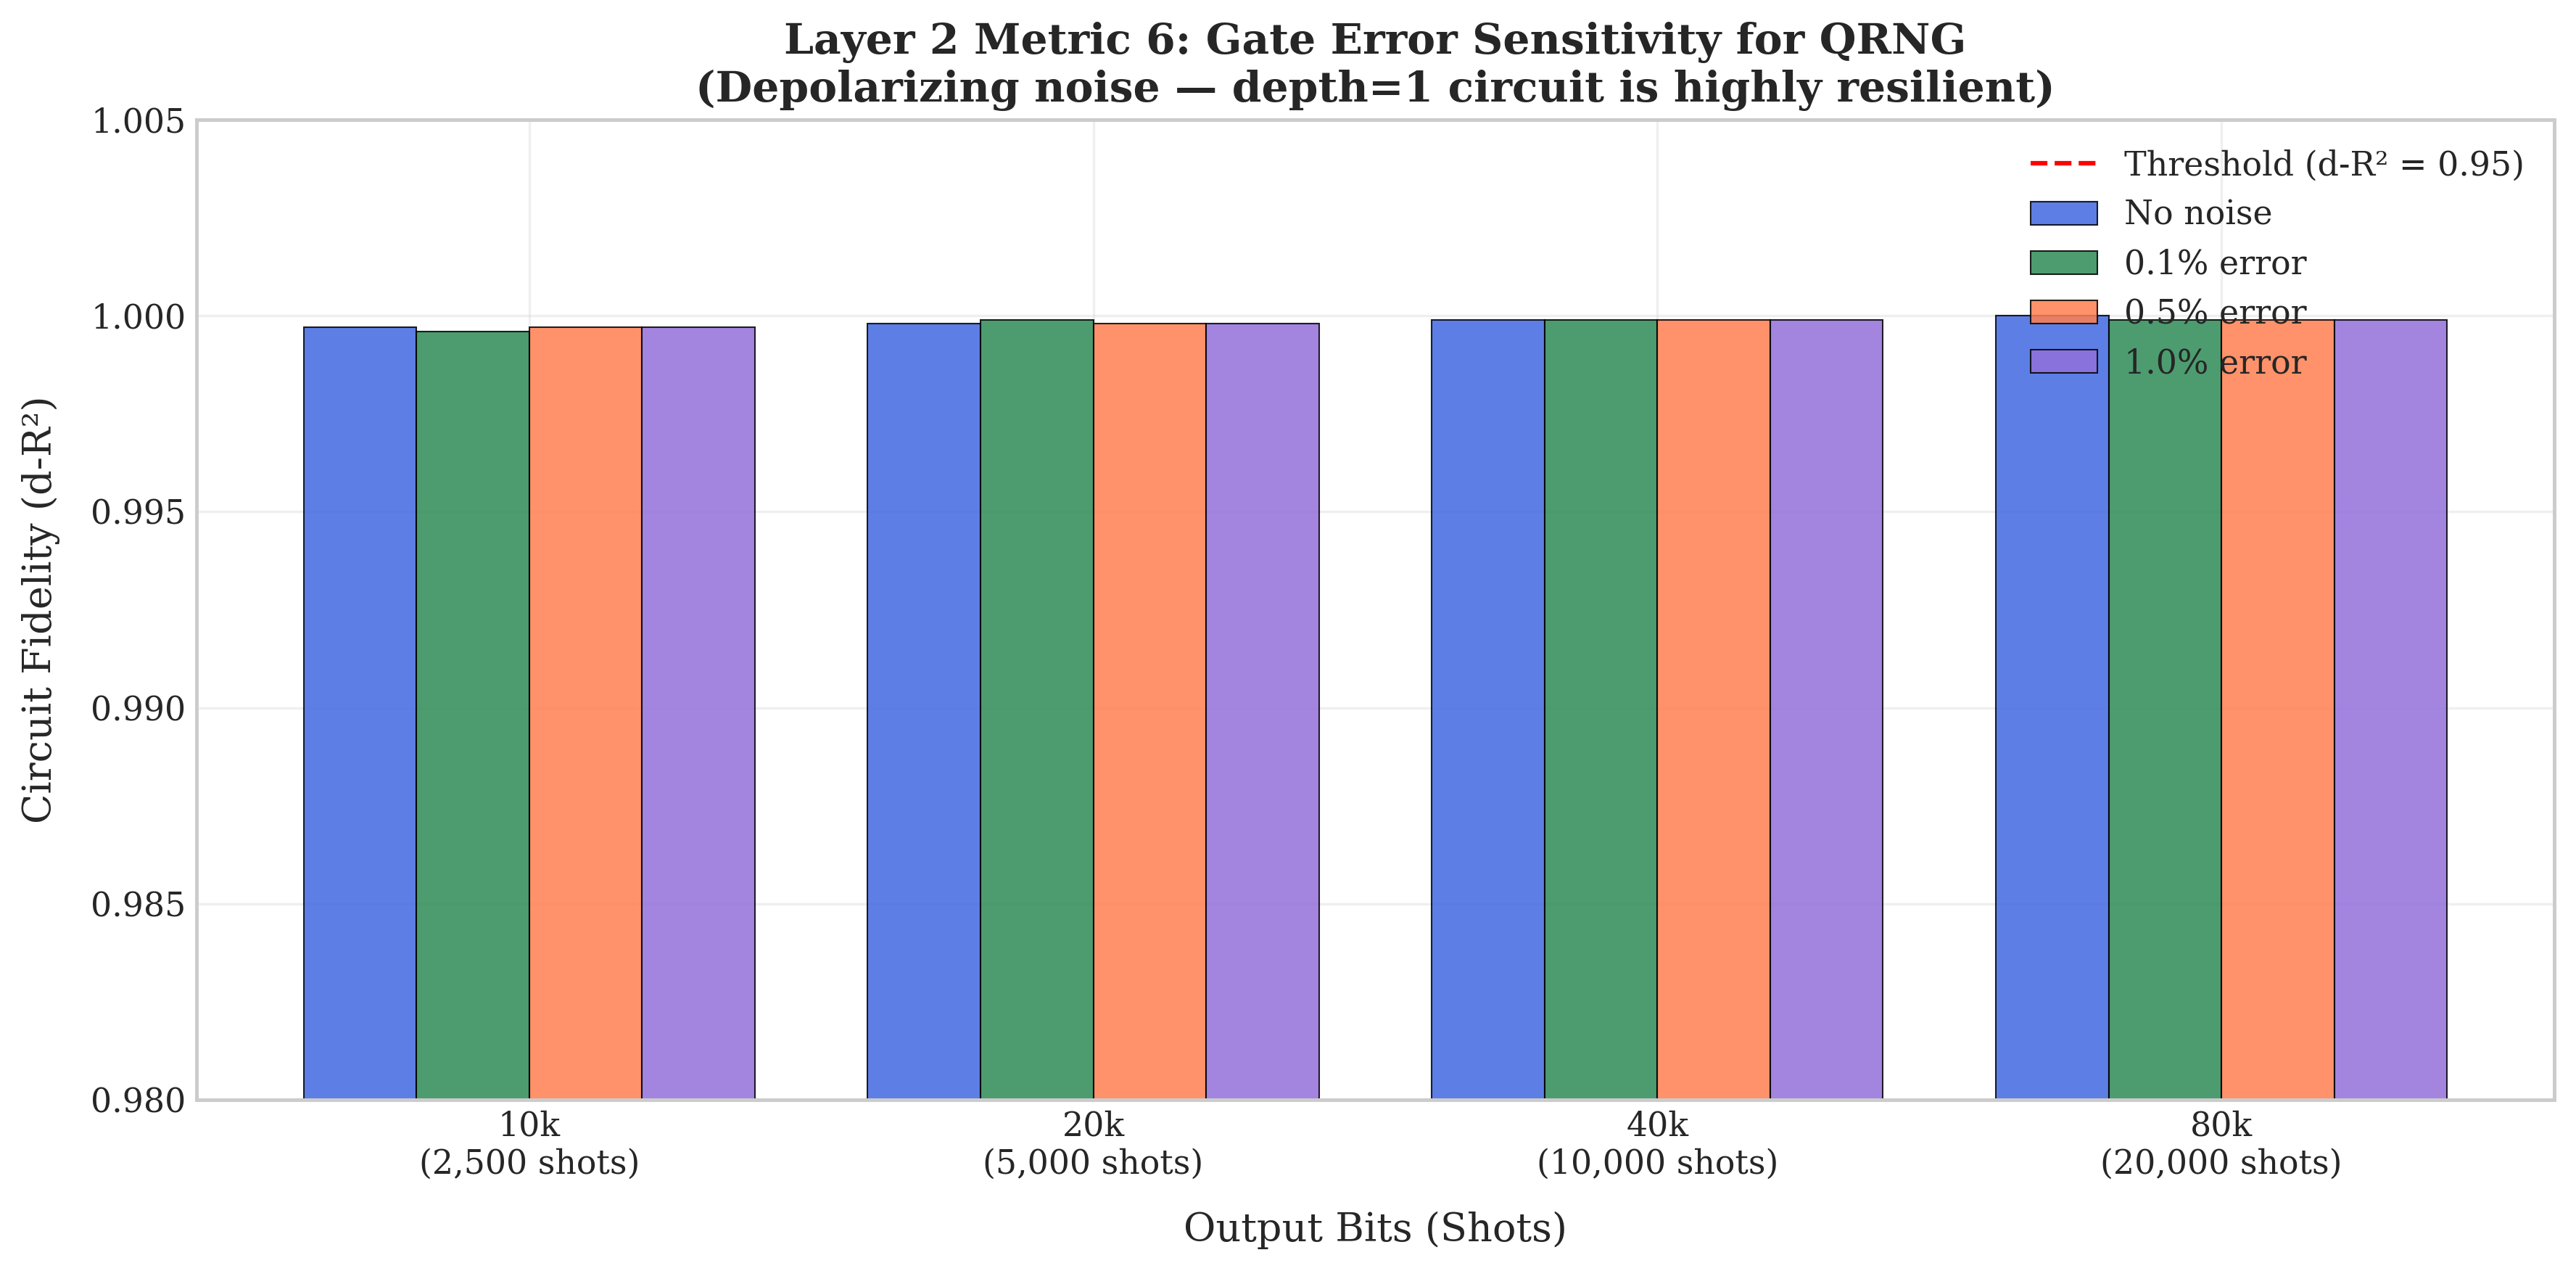

Gate error sensitivity plot saved!


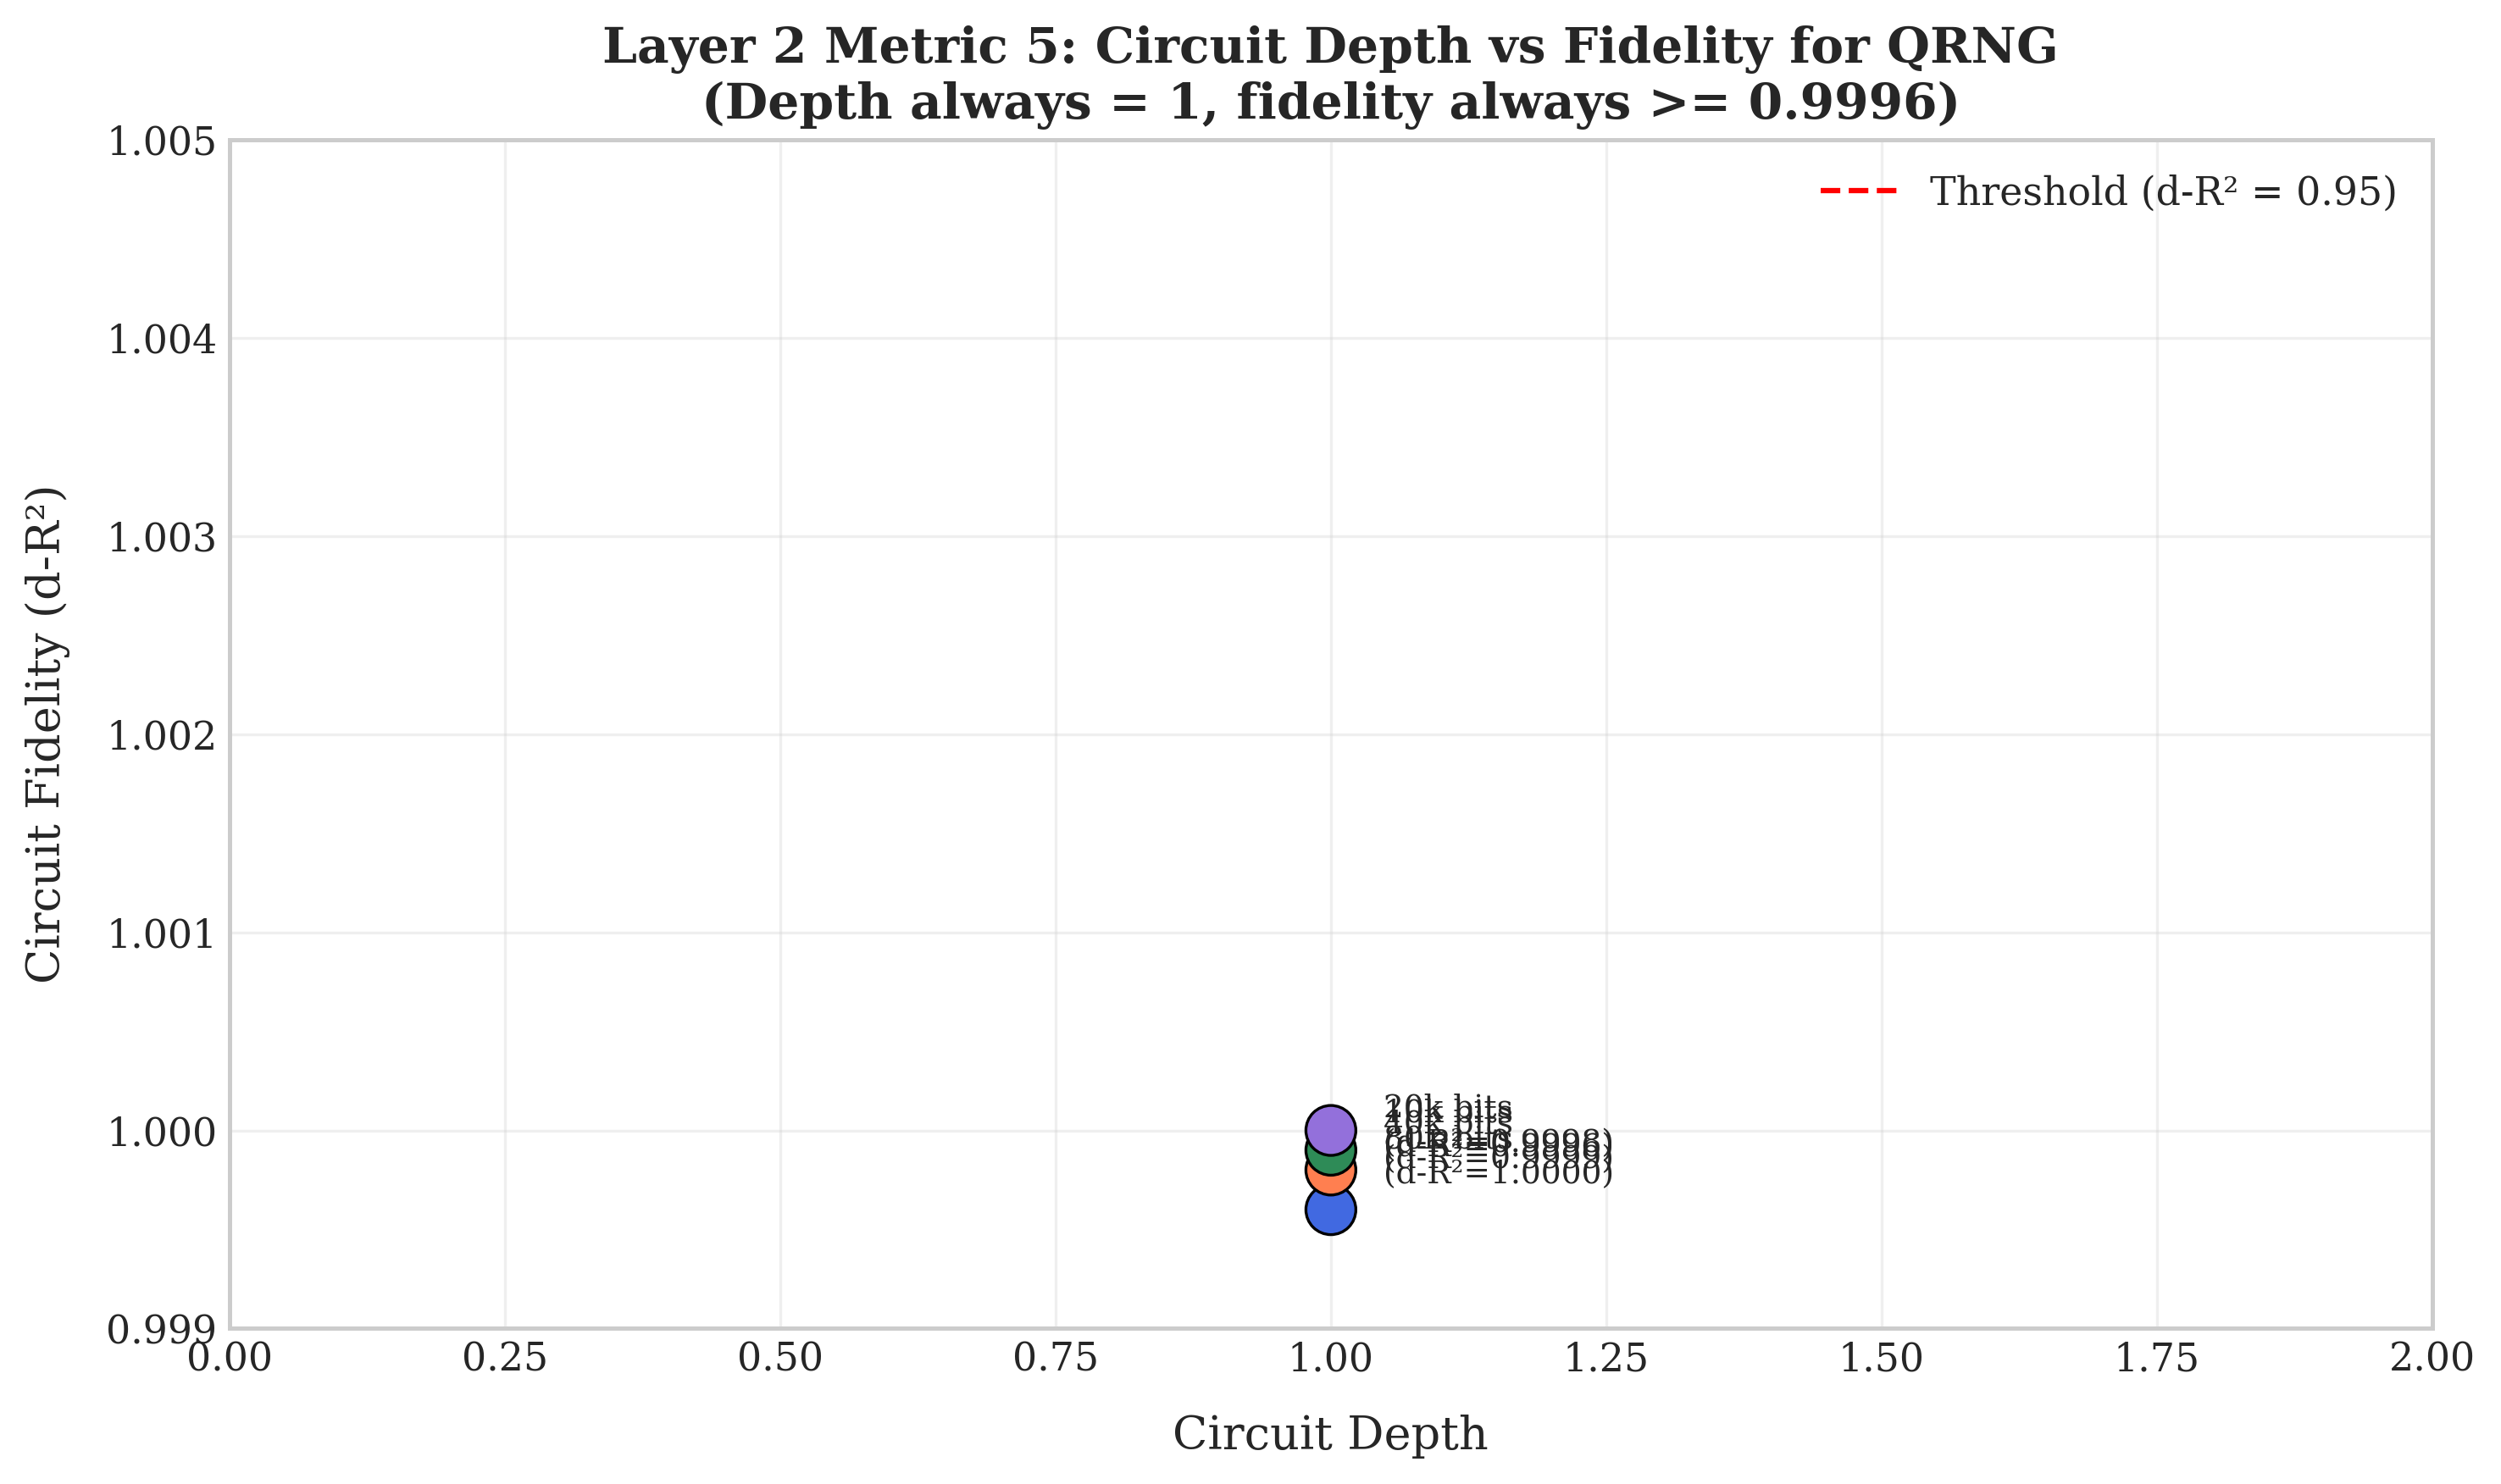

Circuit depth plot saved!


In [34]:
# ── Plot: Metric 6 Gate Error Sensitivity (QRNG) ─────────
bits_labels = ['10k\n(2,500 shots)', '20k\n(5,000 shots)',
               '40k\n(10,000 shots)', '80k\n(20,000 shots)']
x = np.arange(len(bits_labels))
width = 0.2

no_noise = [r['baseline_dR2'] for r in qrng_noise_results]
p01 = [r['error_rates']['0.1%'] for r in qrng_noise_results]
p05 = [r['error_rates']['0.5%'] for r in qrng_noise_results]
p10 = [r['error_rates']['1.0%'] for r in qrng_noise_results]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, no_noise, width, label='No noise',
       color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x - 0.5*width, p01, width, label='0.1% error',
       color='seagreen', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + 0.5*width, p05, width, label='0.5% error',
       color='coral', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + 1.5*width, p10, width, label='1.0% error',
       color='mediumpurple', alpha=0.85, edgecolor='black', linewidth=0.5)

ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (d-R² = 0.95)')
ax.set_xlabel('Output Bits (Shots)', labelpad=10)
ax.set_ylabel('Circuit Fidelity (d-R²)', labelpad=10)
ax.set_title('Layer 2 Metric 6: Gate Error Sensitivity for QRNG\n'
             '(Depolarizing noise — depth=1 circuit is highly resilient)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bits_labels)
ax.set_ylim(0.98, 1.005)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_layer2_gate_error.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gate error sensitivity plot saved!")

# ── Plot: Metric 5 Circuit Depth ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
depths = [1, 1, 1, 1]
fidelities = [0.9996, 0.9998, 0.9999, 1.0000]
bit_labels_d = [10000, 20000, 40000, 80000]
colors_d = ['royalblue', 'coral', 'seagreen', 'mediumpurple']

ax.scatter(depths, fidelities, c=colors_d, s=200,
           edgecolors='black', linewidth=0.8, zorder=5)
for i, (d, f, b) in enumerate(zip(depths, fidelities, bit_labels_d)):
    ax.annotate(f'{b//1000}k bits\n(d-R²={f:.4f})',
                (d, f), textcoords='offset points',
                xytext=(15, -10*i + 15), fontsize=9)
ax.axhline(y=0.95, color='red', linestyle='--',
           linewidth=1.5, label='Threshold (d-R² = 0.95)')
ax.set_xlabel('Circuit Depth', labelpad=10)
ax.set_ylabel('Circuit Fidelity (d-R²)', labelpad=10)
ax.set_title('Layer 2 Metric 5: Circuit Depth vs Fidelity for QRNG\n'
             '(Depth always = 1, fidelity always >= 0.9996)',
             fontweight='bold')
ax.set_xlim(0, 2)
ax.set_ylim(0.999, 1.005)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_layer2_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print("Circuit depth plot saved!")

## Performance Analysis Metrics
Based on team discussion (Aman's suggestions):
- Execution time / Throughput (bits/second)
- Shannon Entropy
- CPU and RAM usage (psutil)

In [23]:
import time
import math
import psutil

# ── Throughput and Shannon Entropy ────────────────────────
def calculate_shannon_entropy(counts, n_bits, shots):
    """
    Shannon Entropy H = -sum(p * log2(p))
    Maximum entropy for n_bits = n_bits (perfectly uniform)
    """
    all_states = [format(i, f'0{n_bits}b') for i in range(2**n_bits)]
    entropy = 0
    for state in all_states:
        count = counts.get(state, 0)
        if count > 0:
            p = count / shots
            entropy -= p * math.log2(p)
    return entropy

def run_with_metrics(n_bits, shots):
    """
    Run QRNG and classical RNG with performance metrics.
    Returns throughput and entropy for both.
    """
    total_bits = n_bits * shots

    # ── Quantum ──
    process = psutil.Process()
    cpu_before = process.cpu_times()
    ram_before = process.memory_info().rss / 1024 / 1024  # MB

    start = time.time()
    q_counts = quantum_rng(n_bits=n_bits, shots=shots)
    q_time = time.time() - start

    cpu_after = process.cpu_times()
    ram_after = process.memory_info().rss / 1024 / 1024

    q_throughput = total_bits / q_time
    q_entropy = calculate_shannon_entropy(q_counts, n_bits, shots)
    q_cpu = (cpu_after.user - cpu_before.user) + (cpu_after.system - cpu_before.system)
    q_ram = ram_after - ram_before

    # ── Classical ──
    cpu_before = process.cpu_times()
    ram_before = process.memory_info().rss / 1024 / 1024

    start = time.time()
    c_counts = classical_rng(n_bits=n_bits, shots=shots)
    c_time = time.time() - start

    cpu_after = process.cpu_times()
    ram_after = process.memory_info().rss / 1024 / 1024

    c_throughput = total_bits / c_time
    c_entropy = calculate_shannon_entropy(c_counts, n_bits, shots)
    c_cpu = (cpu_after.user - cpu_before.user) + (cpu_after.system - cpu_before.system)
    c_ram = ram_after - ram_before

    return {
        'bits': total_bits,
        'shots': shots,
        'quantum': {
            'time_seconds': round(q_time, 4),
            'throughput_bps': round(q_throughput, 2),
            'shannon_entropy': round(q_entropy, 4),
            'cpu_time_seconds': round(q_cpu, 4),
            'ram_delta_mb': round(q_ram, 4)
        },
        'classical': {
            'time_seconds': round(c_time, 4),
            'throughput_bps': round(c_throughput, 2),
            'shannon_entropy': round(c_entropy, 4),
            'cpu_time_seconds': round(c_cpu, 4),
            'ram_delta_mb': round(c_ram, 4)
        }
    }

# ── Run across agreed protocol configurations ─────────────
print(f"{'Bits':>8} | {'Method':>10} | {'Time(s)':>8} | {'Throughput(bps)':>15} | {'Entropy':>8} | {'CPU(s)':>8} | {'RAM(MB)':>8}")
print("-" * 80)

performance_results = []
for bits, shots in zip([10000, 20000, 40000, 80000], [2500, 5000, 10000, 20000]):
    result = run_with_metrics(n_bits=4, shots=shots)
    performance_results.append(result)

    print(f"{bits:>8,} | {'Quantum':>10} | {result['quantum']['time_seconds']:>8.4f} | {result['quantum']['throughput_bps']:>15,.2f} | {result['quantum']['shannon_entropy']:>8.4f} | {result['quantum']['cpu_time_seconds']:>8.4f} | {result['quantum']['ram_delta_mb']:>8.4f}")
    print(f"{bits:>8,} | {'Classical':>10} | {result['classical']['time_seconds']:>8.4f} | {result['classical']['throughput_bps']:>15,.2f} | {result['classical']['shannon_entropy']:>8.4f} | {result['classical']['cpu_time_seconds']:>8.4f} | {result['classical']['ram_delta_mb']:>8.4f}")
    print("-" * 80)

    Bits |     Method |  Time(s) | Throughput(bps) |  Entropy |   CPU(s) |  RAM(MB)
--------------------------------------------------------------------------------
  10,000 |    Quantum |   0.0258 |      386,960.54 |   3.9982 |   0.0300 |   0.0000
  10,000 |  Classical |   0.0068 |    1,477,127.66 |   3.9948 |   0.0100 |   0.0000
--------------------------------------------------------------------------------
  20,000 |    Quantum |   0.0392 |      509,781.53 |   3.9984 |   0.0400 |   0.0000
  20,000 |  Classical |   0.0137 |    1,463,265.42 |   3.9987 |   0.0100 |   0.0000
--------------------------------------------------------------------------------
  40,000 |    Quantum |   0.0673 |      594,371.87 |   3.9991 |   0.0700 |   0.0000
  40,000 |  Classical |   0.0272 |    1,472,137.59 |   3.9993 |   0.0300 |   0.0000
--------------------------------------------------------------------------------
  80,000 |    Quantum |   0.1297 |      617,001.09 |   3.9991 |   0.1300 |   0.0000
  80

# Performance Visualization

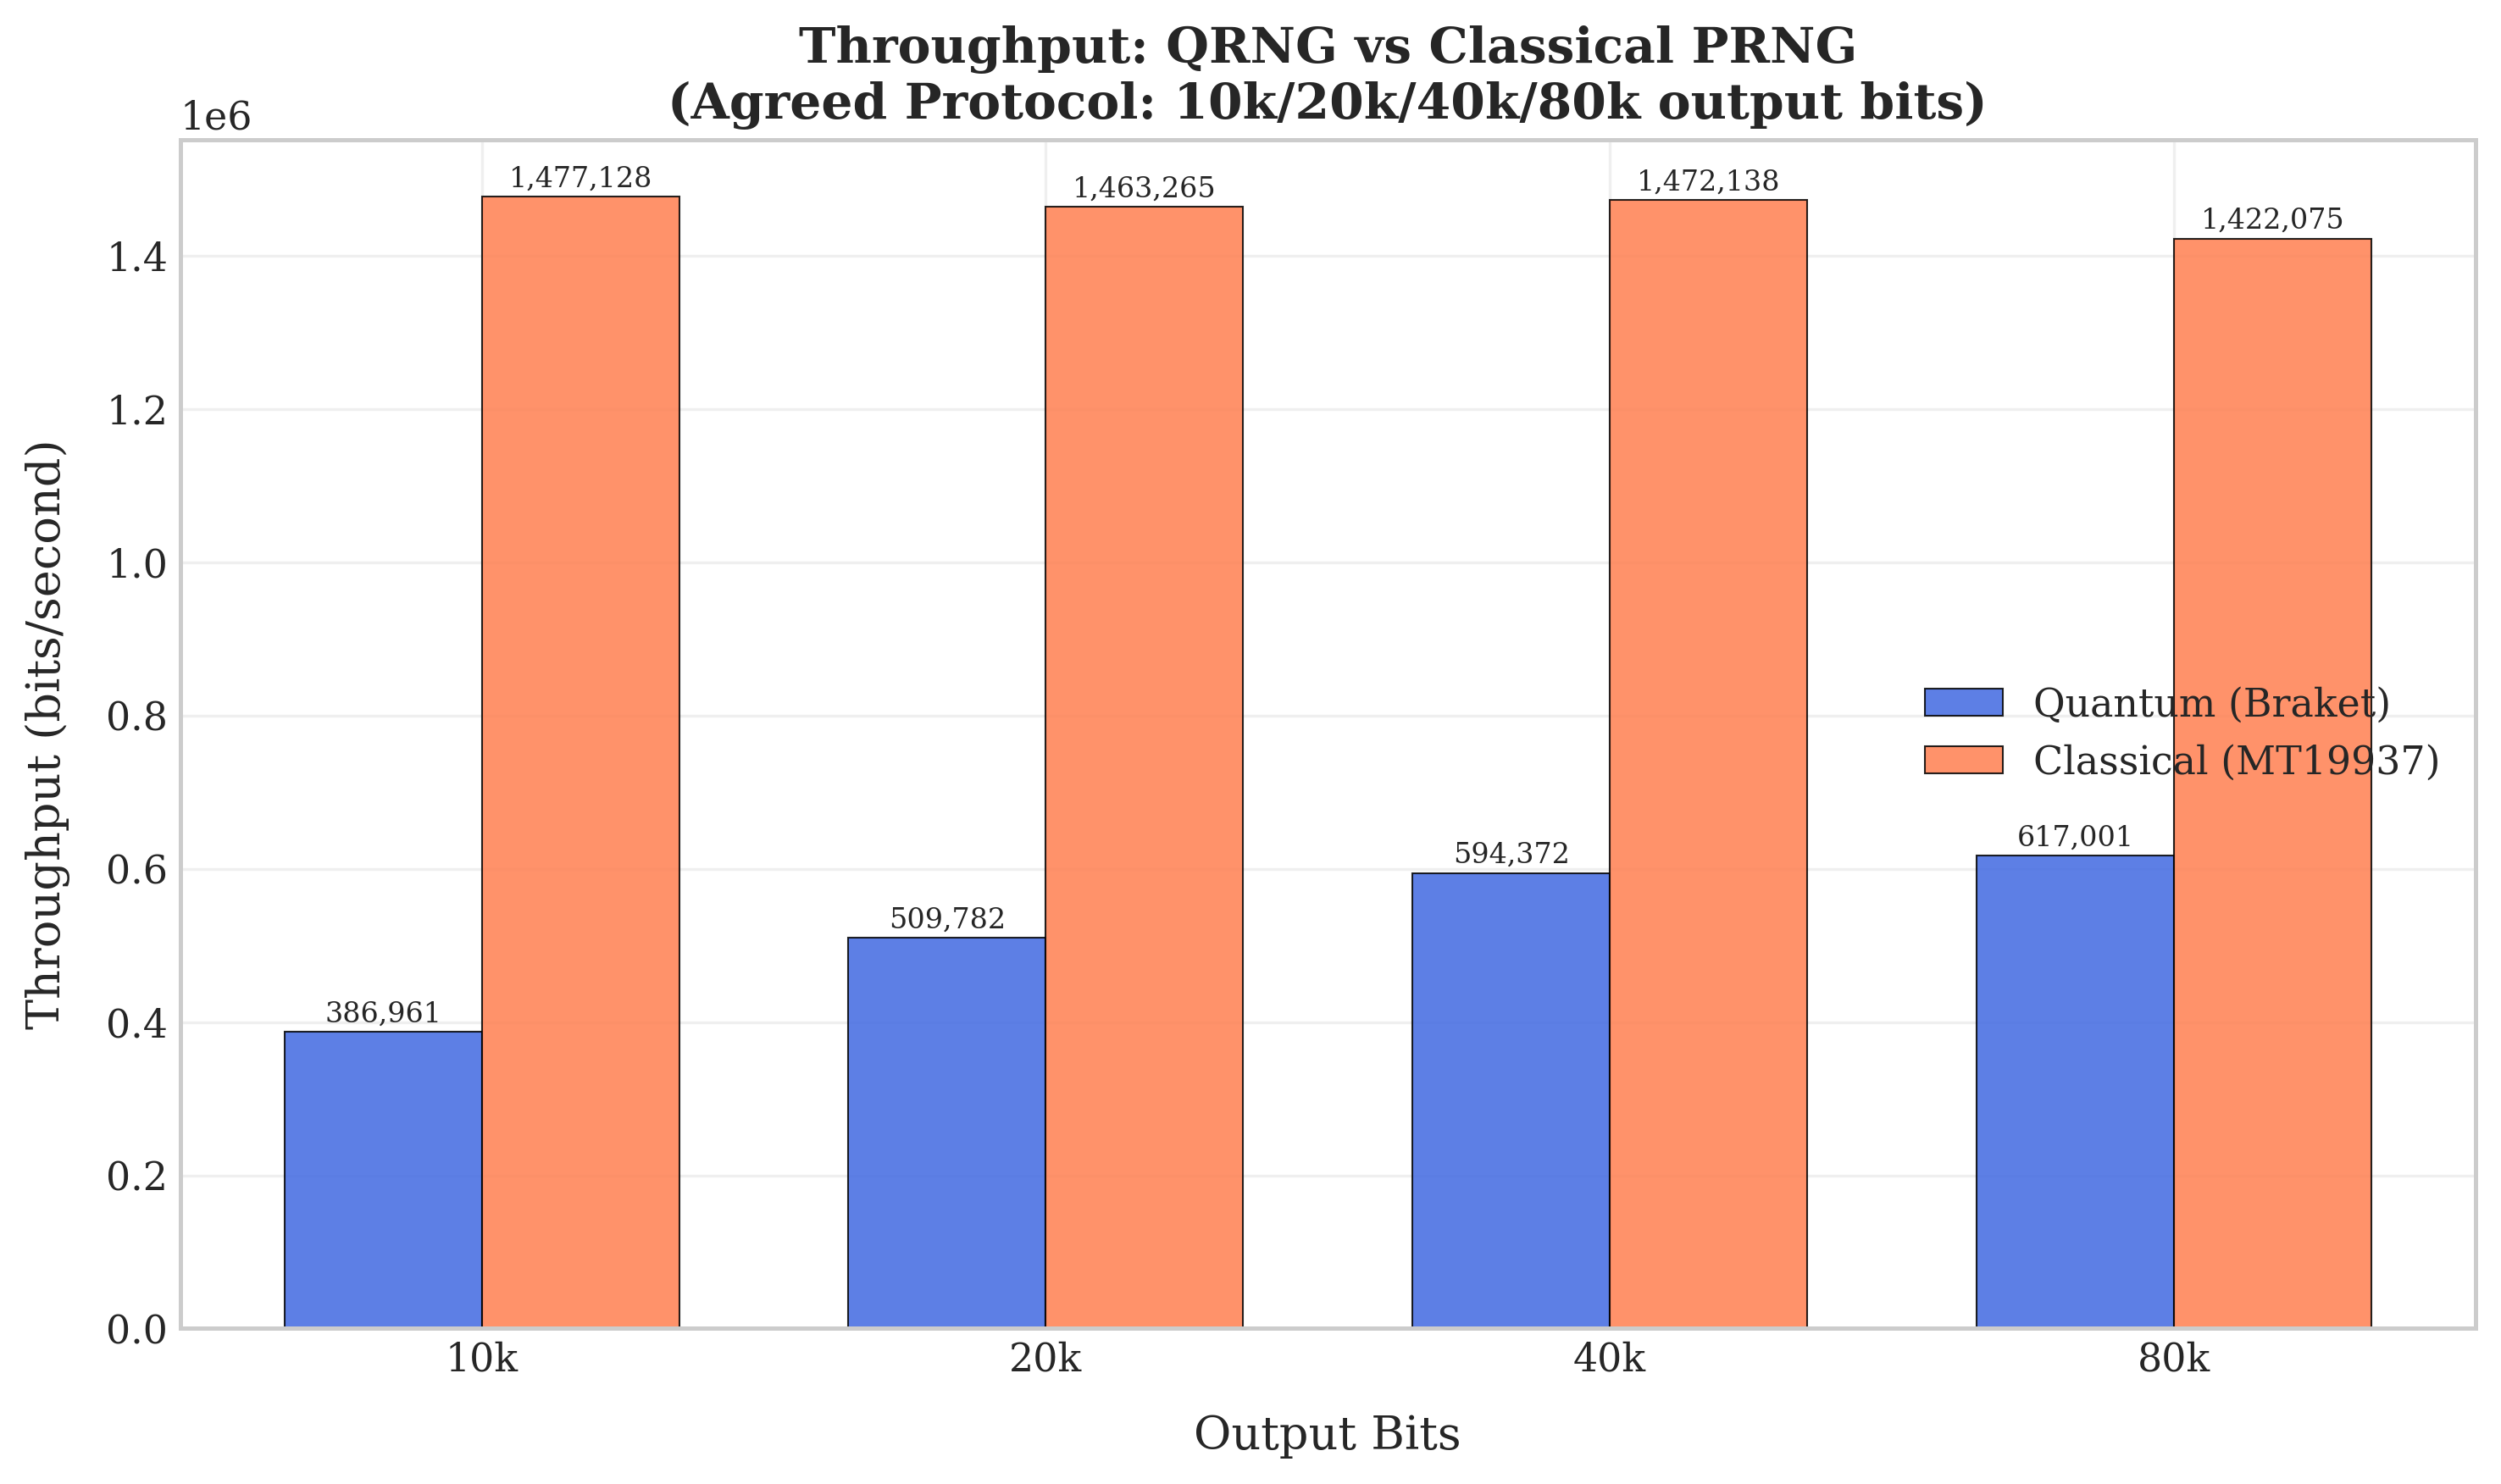

Throughput plot saved!


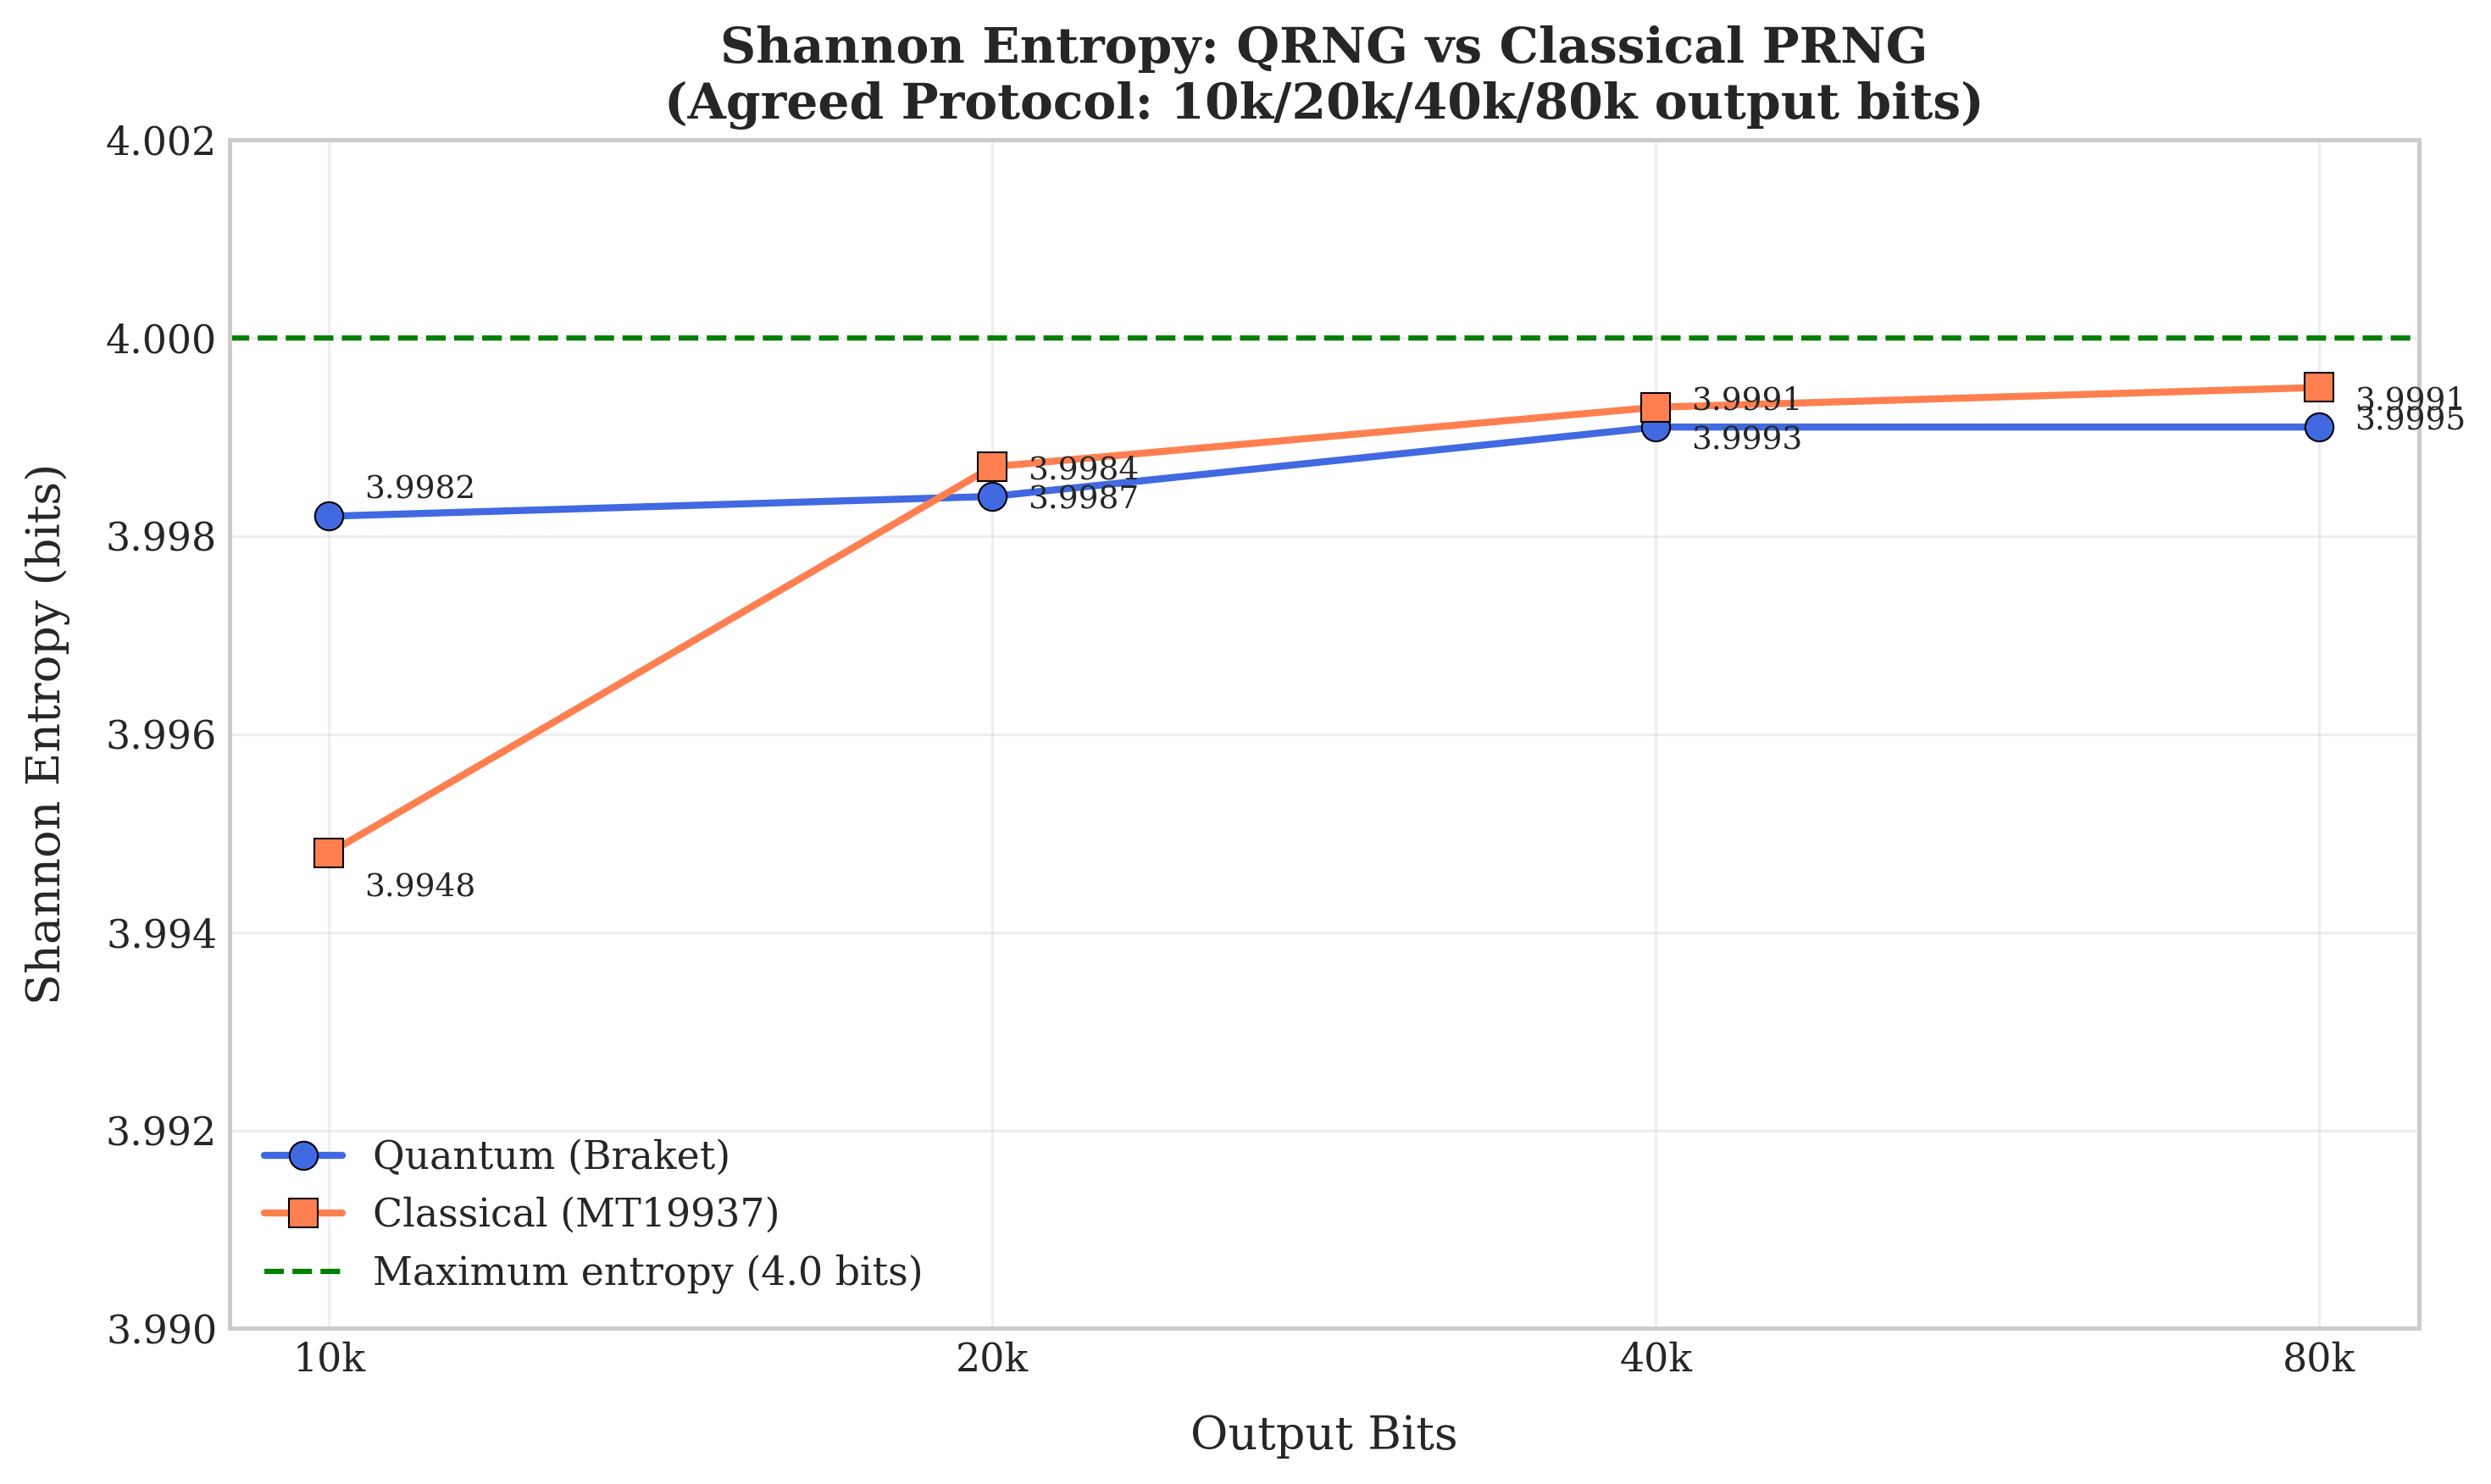

Shannon Entropy plot saved!


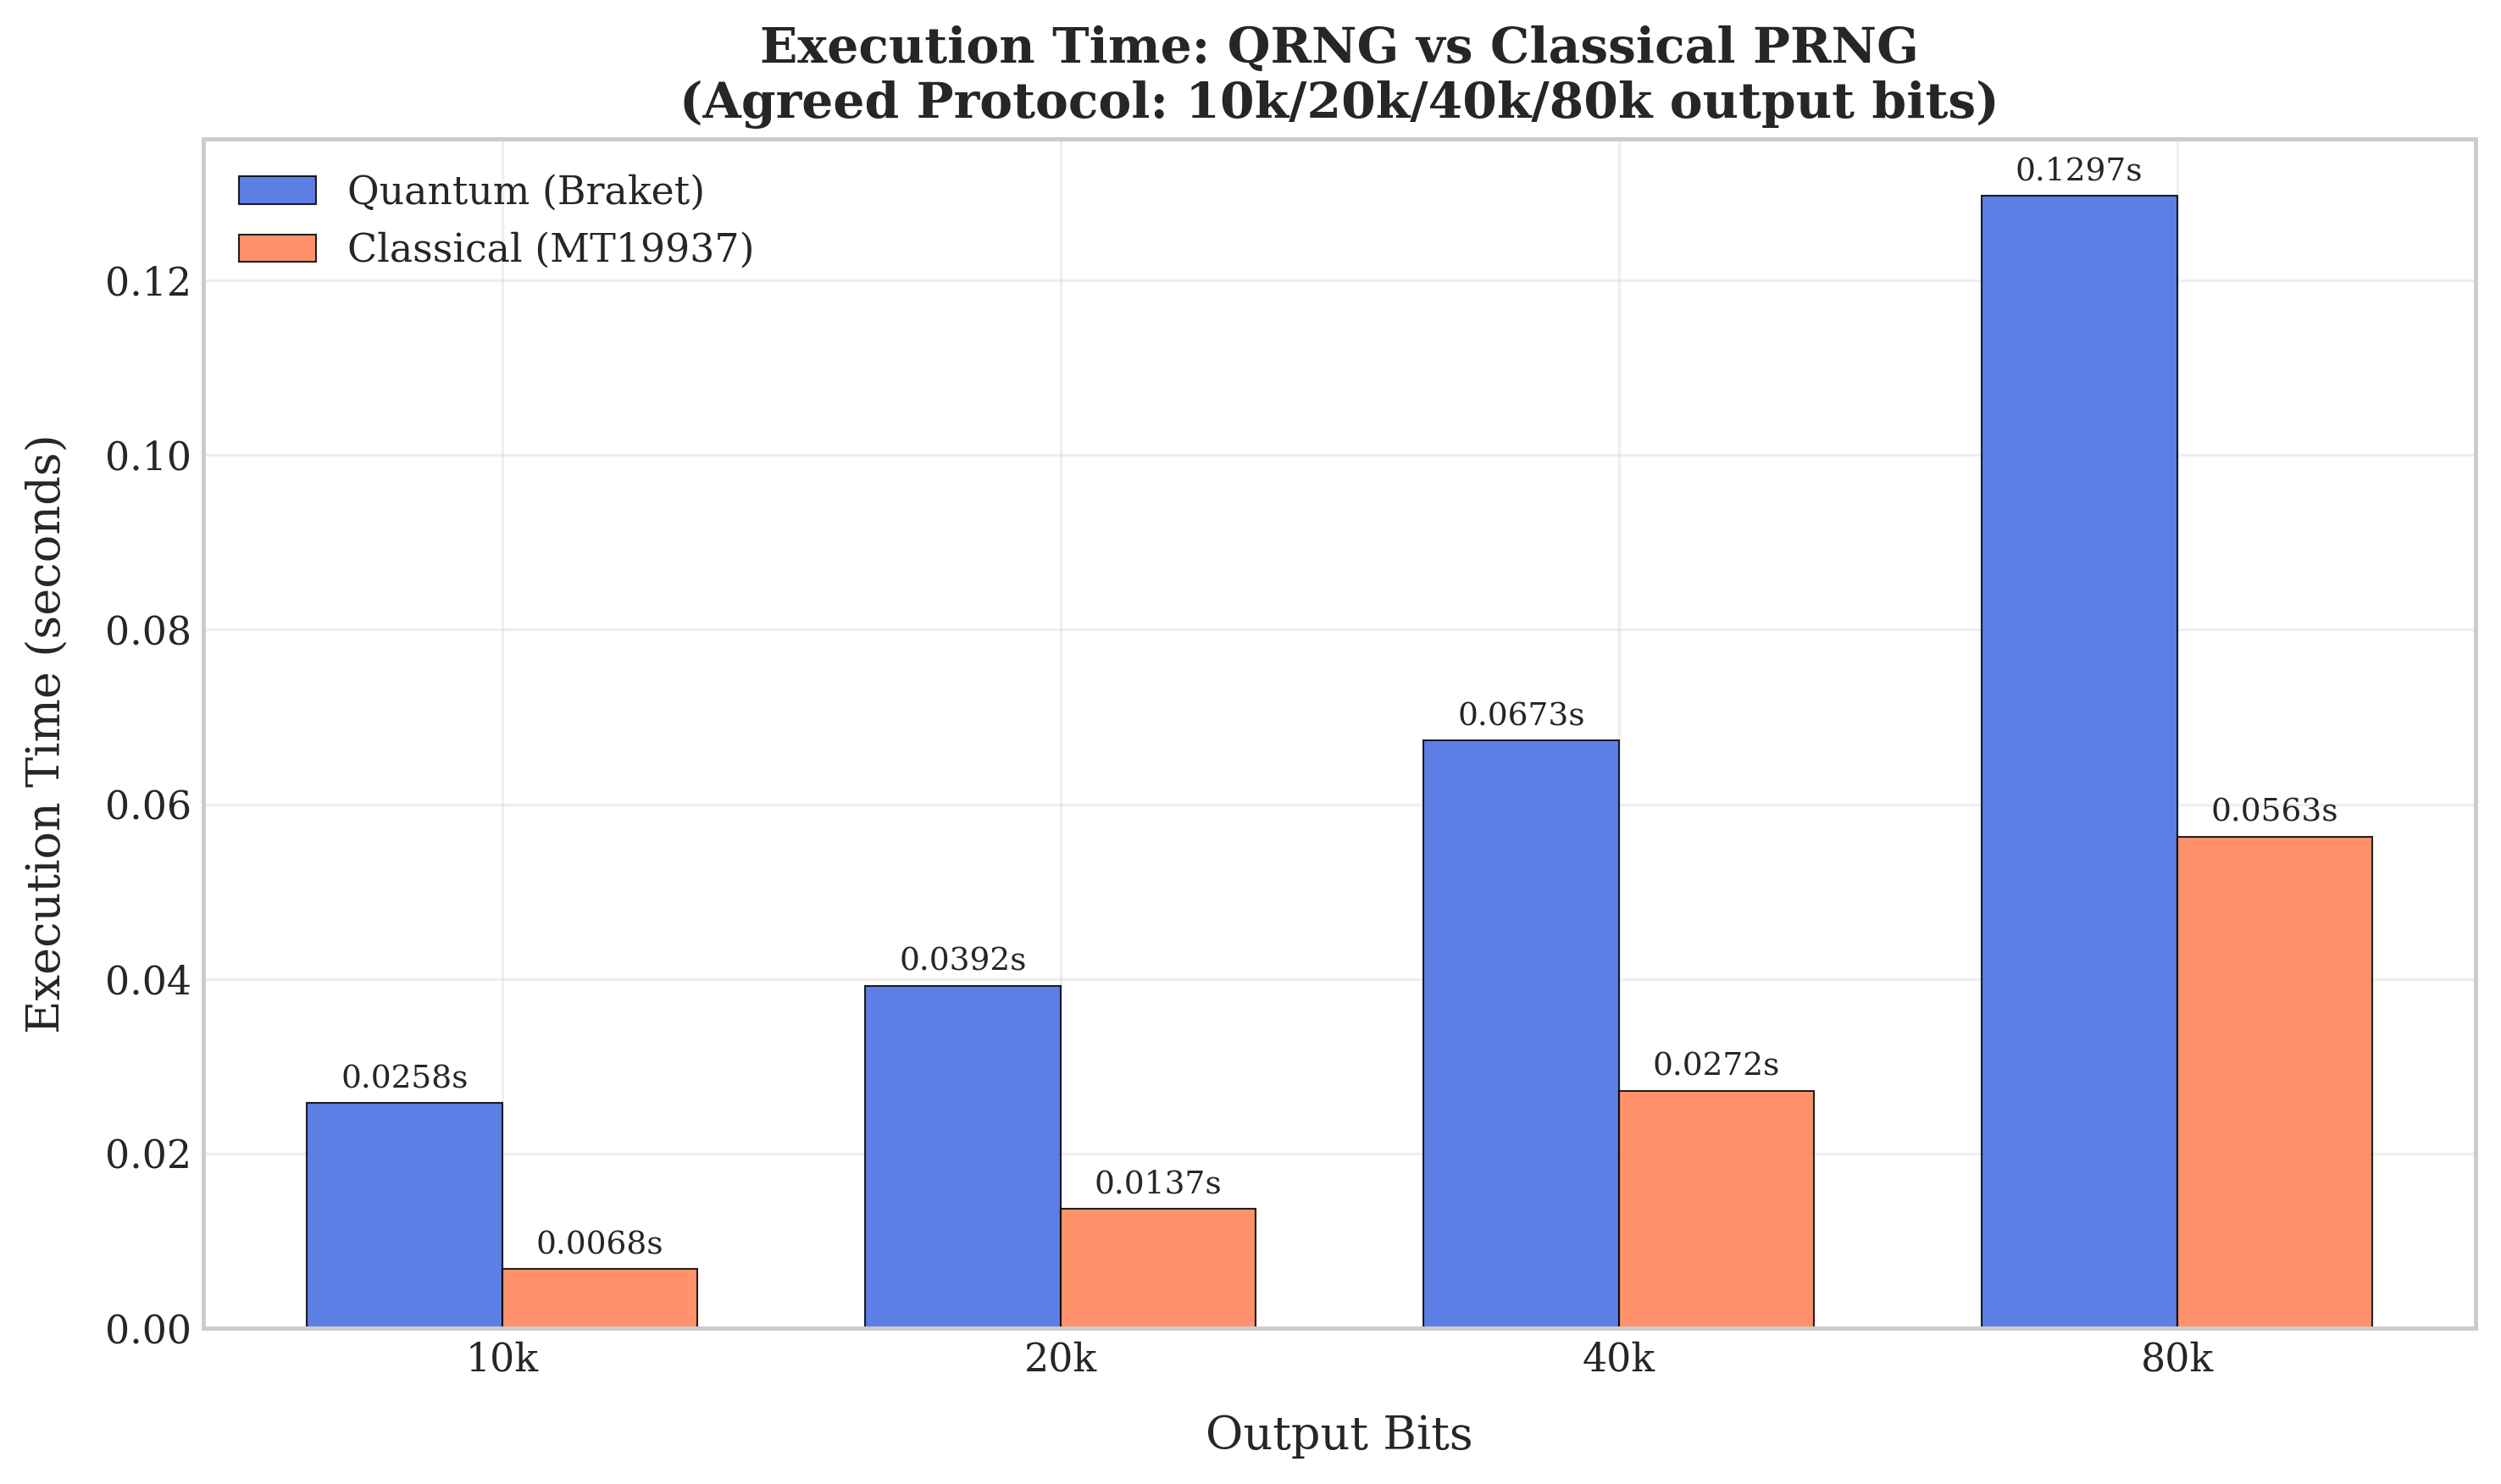

Execution Time plot saved!


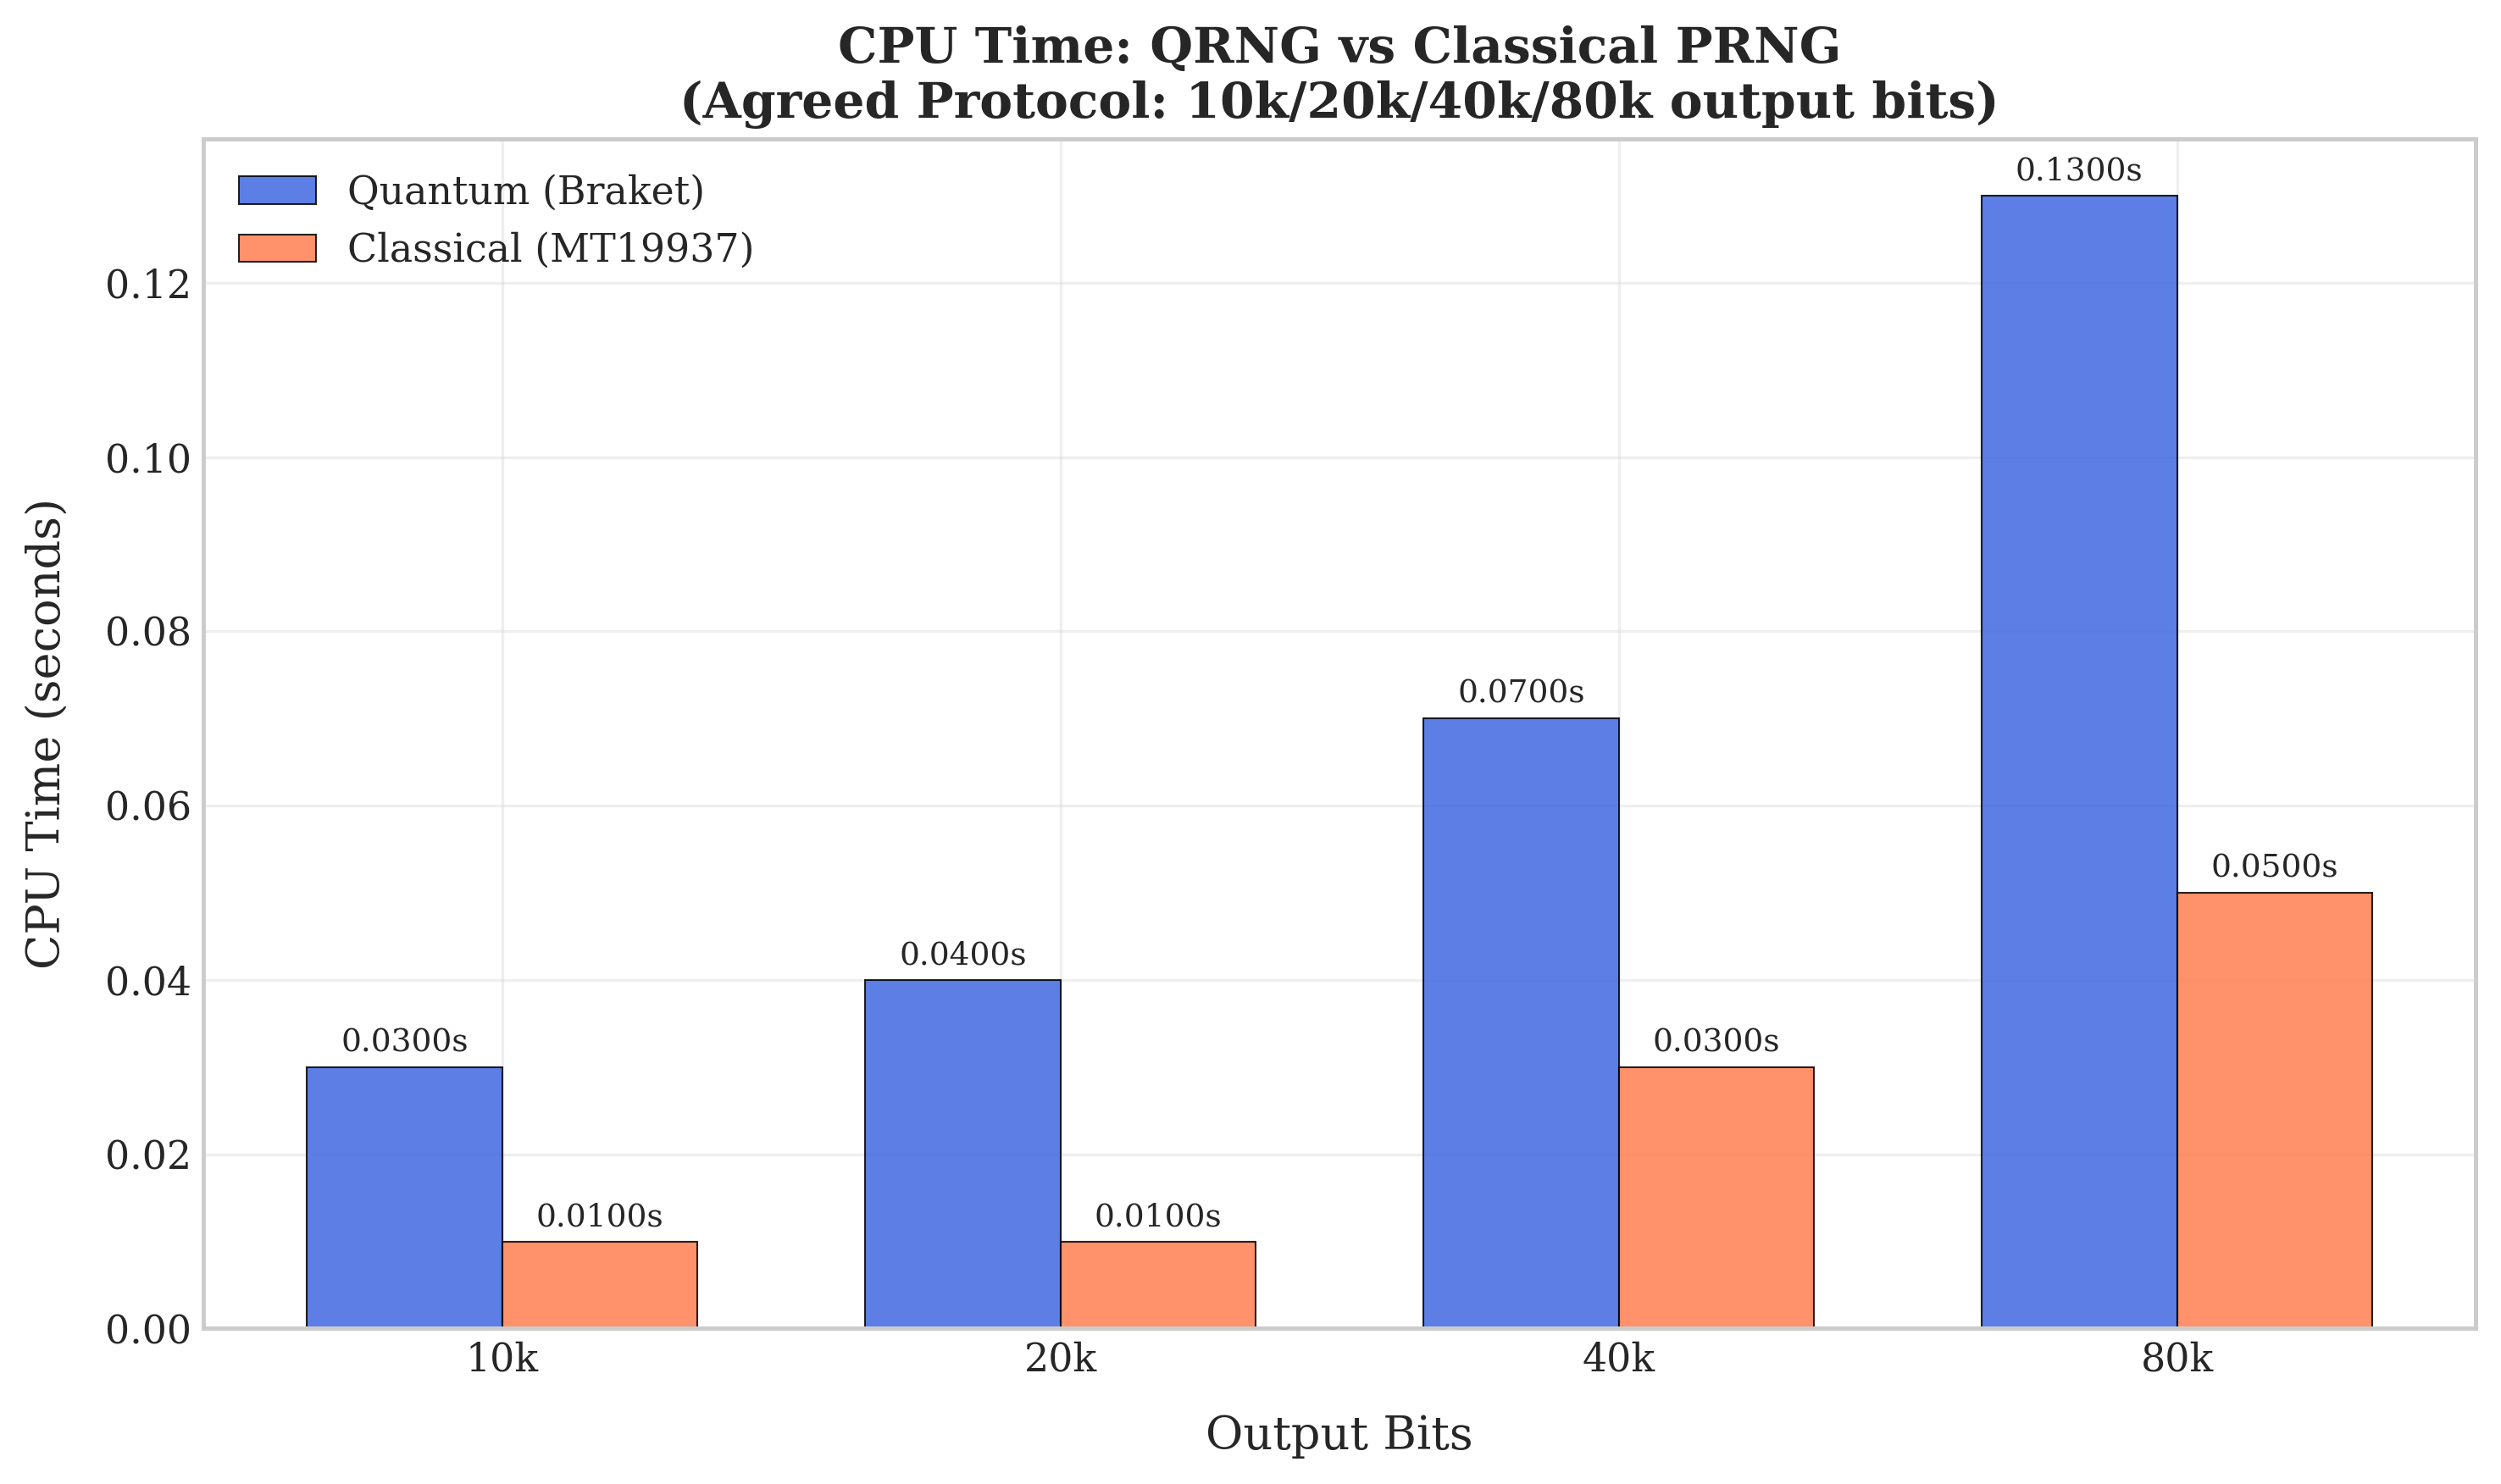

CPU Time plot saved!


In [24]:
# ── Performance Visualization (Individual Plots) ──────────

bits_labels = ['10k', '20k', '40k', '80k']
x = np.arange(len(bits_labels))
width = 0.35

q_throughput = [r['quantum']['throughput_bps'] for r in performance_results]
c_throughput = [r['classical']['throughput_bps'] for r in performance_results]
q_entropy = [r['quantum']['shannon_entropy'] for r in performance_results]
c_entropy = [r['classical']['shannon_entropy'] for r in performance_results]
q_time = [r['quantum']['time_seconds'] for r in performance_results]
c_time = [r['classical']['time_seconds'] for r in performance_results]
q_cpu = [r['quantum']['cpu_time_seconds'] for r in performance_results]
c_cpu = [r['classical']['cpu_time_seconds'] for r in performance_results]

# ── Plot 1: Throughput ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, q_throughput, width, label='Quantum (Braket)',
               color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, c_throughput, width, label='Classical (MT19937)',
               color='coral', alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, q_throughput):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, c_throughput):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Output Bits', labelpad=10)
ax.set_ylabel('Throughput (bits/second)', labelpad=10)
ax.set_title('Throughput: QRNG vs Classical PRNG\n(Agreed Protocol: 10k/20k/40k/80k output bits)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bits_labels)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_performance_throughput.png', dpi=300, bbox_inches='tight')
plt.show()
print("Throughput plot saved!")

# ── Plot 2: Shannon Entropy ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bits_labels, q_entropy, 'o-', color='royalblue',
        label='Quantum (Braket)', linewidth=2, markersize=8,
        markeredgecolor='black', markeredgewidth=0.5)
ax.plot(bits_labels, c_entropy, 's-', color='coral',
        label='Classical (MT19937)', linewidth=2, markersize=8,
        markeredgecolor='black', markeredgewidth=0.5)
ax.axhline(y=4.0, color='green', linestyle='--',
           linewidth=1.5, label='Maximum entropy (4.0 bits)')
for i, (q, c) in enumerate(zip(q_entropy, c_entropy)):
    ax.annotate(f'{q:.4f}', (bits_labels[i], q),
                textcoords='offset points', xytext=(10, 5), fontsize=9)
    ax.annotate(f'{c:.4f}', (bits_labels[i], c),
                textcoords='offset points', xytext=(10, -12), fontsize=9)
ax.set_xlabel('Output Bits', labelpad=10)
ax.set_ylabel('Shannon Entropy (bits)', labelpad=10)
ax.set_title('Shannon Entropy: QRNG vs Classical PRNG\n(Agreed Protocol: 10k/20k/40k/80k output bits)',
             fontweight='bold')
ax.set_ylim(3.990, 4.002)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_performance_entropy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Shannon Entropy plot saved!")

# ── Plot 3: Execution Time ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, q_time, width, label='Quantum (Braket)',
               color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, c_time, width, label='Classical (MT19937)',
               color='coral', alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, q_time):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, c_time):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Output Bits', labelpad=10)
ax.set_ylabel('Execution Time (seconds)', labelpad=10)
ax.set_title('Execution Time: QRNG vs Classical PRNG\n(Agreed Protocol: 10k/20k/40k/80k output bits)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bits_labels)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_performance_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Execution Time plot saved!")

# ── Plot 4: CPU Time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, q_cpu, width, label='Quantum (Braket)',
               color='royalblue', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, c_cpu, width, label='Classical (MT19937)',
               color='coral', alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, q_cpu):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, c_cpu):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Output Bits', labelpad=10)
ax.set_ylabel('CPU Time (seconds)', labelpad=10)
ax.set_title('CPU Time: QRNG vs Classical PRNG\n(Agreed Protocol: 10k/20k/40k/80k output bits)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bits_labels)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qrng_performance_cpu.png', dpi=300, bbox_inches='tight')
plt.show()
print("CPU Time plot saved!")

In [25]:
# ── Experiment Log 006: Performance Analysis ──────────────
experiment_log_006 = {
    "experiment_id": "qi26_26_QRNG_006",
    "benchmark_type": "QRNG_Performance",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "simulator": "LocalSimulator",
    "circuit_params": {
        "qubits": 4,
        "depth": 1,
        "gates": {"H": 4},
        "output_bits": [10000, 20000, 40000, 80000],
        "shot_counts": [2500, 5000, 10000, 20000]
    },
    "metrics": {
        "configurations": [
            {
                "output_bits": 10000, "shots": 2500,
                "quantum": {"time_seconds": 0.0258, "throughput_bps": 386960.54, "shannon_entropy": 3.9982, "cpu_time_seconds": 0.0300},
                "classical": {"time_seconds": 0.0068, "throughput_bps": 1477127.66, "shannon_entropy": 3.9948, "cpu_time_seconds": 0.0100}
            },
            {
                "output_bits": 20000, "shots": 5000,
                "quantum": {"time_seconds": 0.0392, "throughput_bps": 509781.53, "shannon_entropy": 3.9984, "cpu_time_seconds": 0.0400},
                "classical": {"time_seconds": 0.0137, "throughput_bps": 1463265.42, "shannon_entropy": 3.9987, "cpu_time_seconds": 0.0100}
            },
            {
                "output_bits": 40000, "shots": 10000,
                "quantum": {"time_seconds": 0.0673, "throughput_bps": 594371.87, "shannon_entropy": 3.9991, "cpu_time_seconds": 0.0700},
                "classical": {"time_seconds": 0.0272, "throughput_bps": 1472137.59, "shannon_entropy": 3.9993, "cpu_time_seconds": 0.0300}
            },
            {
                "output_bits": 80000, "shots": 20000,
                "quantum": {"time_seconds": 0.1297, "throughput_bps": 617001.09, "shannon_entropy": 3.9991, "cpu_time_seconds": 0.1300},
                "classical": {"time_seconds": 0.0563, "throughput_bps": 1422075.15, "shannon_entropy": 3.9995, "cpu_time_seconds": 0.0500}
            }
        ]
    },
    "environment": {
        "braket_sdk_version": "1.121.0",
        "python_version": "3.12",
        "region": "us-east-1"
    },
    "notes": "Classical MT19937 is ~2.5x faster than quantum LocalSimulator. Both achieve near-maximum Shannon entropy (>= 3.994 bits). Quantum throughput scales better with output size. Classical advantage is in raw speed; quantum advantage is in randomness guarantees."
}

with open('qrng_experiment_006.json', 'w') as f:
    json.dump(experiment_log_006, f, indent=2)

print("Experiment 006 logged!")
print(json.dumps(experiment_log_006, indent=2))

Experiment 006 logged!
{
  "experiment_id": "qi26_26_QRNG_006",
  "benchmark_type": "QRNG_Performance",
  "timestamp": "2026-07-19T03:39:56.304391+00:00",
  "simulator": "LocalSimulator",
  "circuit_params": {
    "qubits": 4,
    "depth": 1,
    "gates": {
      "H": 4
    },
    "output_bits": [
      10000,
      20000,
      40000,
      80000
    ],
    "shot_counts": [
      2500,
      5000,
      10000,
      20000
    ]
  },
  "metrics": {
    "configurations": [
      {
        "output_bits": 10000,
        "shots": 2500,
        "quantum": {
          "time_seconds": 0.0258,
          "throughput_bps": 386960.54,
          "shannon_entropy": 3.9982,
          "cpu_time_seconds": 0.03
        },
        "classical": {
          "time_seconds": 0.0068,
          "throughput_bps": 1477127.66,
          "shannon_entropy": 3.9948,
          "cpu_time_seconds": 0.01
        }
      },
      {
        "output_bits": 20000,
        "shots": 5000,
        "quantum": {
          "time

In [36]:
from google.colab import files

In [42]:
# ── JSON Experiment Logs ──────────────────────────────────
files.download('qrng_experiment_001.json')
files.download('qrng_experiment_002.json')
files.download('qrng_experiment_003.json')
files.download('qrng_experiment_004.json')
files.download('qrng_experiment_005.json')
files.download('qrng_experiment_006.json')
files.download('qrng_experiment_007.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# ── Comparison Plots ──────────────────────────────────────
files.download('qrng_comparison.png')
files.download('qrng_shot_sweep.png')
files.download('qrng_qubit_sweep.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# ── Multiple Trials Plots (all 4 configurations) ─────────
files.download('qrng_multiple_trials_10000bits.png')
files.download('qrng_multiple_trials_20000bits.png')
files.download('qrng_multiple_trials_40000bits.png')
files.download('qrng_multiple_trials_80000bits.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# ── Layer 2 Validation Plots ──────────────────────────────
files.download('qrng_layer2_fidelity.png')
files.download('qrng_layer2_shot_noise.png')
files.download('qrng_layer2_bias.png')
files.download('qrng_layer2_gate_error.png')
files.download('qrng_layer2_depth.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# ── Layer 2 Performance Plots ──────────────────────────────
files.download('qrng_performance_cpu.png')
files.download('qrng_performance_time.png')
files.download('qrng_performance_entropy.png')
files.download('qrng_performance_throughput.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>